## **1. Importar Librerias**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import zipfile
from PIL import Image
from google.colab import userdata
import time
from datetime import datetime
!pip install --upgrade anthropic

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.6 MB/s eta 0:00:00


## **2.0 Verificar Saldo en Modelos**

In [ ]:
import os
from google.colab import userdata

print("="*60)
print("✅ VERIFICACIÓN DE CRÉDITOS API")
print("="*60)
print(f"   OpenAI: {'✓' if userdata.get('OPENAI_KEY') else '✗'}")
print(f"   Gemini: {'✓' if userdata.get('GEMINI_KEY') else '✗'}")
print(f"   Grok: {'✓' if userdata.get('GROKAI_KEY') else '✗'}")
print(f"   Claude: {'✓' if userdata.get('CLAUDE_KEY') else '✗'}")

print("\n" + "="*60)
print("📊 OPENAI (GPT-4o)")
print("="*60)

# GPT
import openai
from google.colab import userdata

openai.api_key = userdata.get('OPENAI_KEY')

try:
    # Ver cuentas y límites
    print("   Información de cuenta:")
    print("   - Para ver uso: https://platform.openai.com/usage")
    print("   - Para ver facturación: https://platform.openai.com/account/billing")

    # Listar modelos disponibles (para confirmar acceso)
    models = openai.models.list()
    gpt_models = [m.id for m in models if 'gpt-4o' in m.id]
    print(f"   ✅ Modelos GPT-4o disponibles: {gpt_models[:3]}")
    print("   💰 Se recomienda al menos $5 USD para 10 corridas")
except Exception as e:
    print(f"   ❌ Error: {e}")

print("\n" + "="*60)
print("📊 GOOGLE GEMINI")
print("="*60)

# Gemini
import google.generativeai as genai
from google.colab import userdata

genai.configure(api_key=userdata.get('GEMINI_KEY'))

try:
    # Listar modelos disponibles
    print("   Modelos disponibles:")
    count = 0
    for model in genai.list_models():
        if 'gemini' in model.name:
            print(f"   ✅ {model.name}")
            count += 1
    print(f"   📊 Total modelos Gemini: {count}")
    print("   💰 Nivel gratuito: 60 solicitudes/minuto (suficiente)")
except Exception as e:
    print(f"   ❌ Error: {e}")

print("\n" + "="*60)
print("📊 GROK (xAI)")
print("="*60)

# Grok (xAi)
from openai import OpenAI
from google.colab import userdata

client = OpenAI(
    api_key=userdata.get('GROKAI_KEY'),
    base_url="https://api.x.ai/v1"
)

try:
    # Listar modelos
    print("   Modelos disponibles:")
    models = client.models.list()
    grok_models = [model.id for model in models if 'grok' in model.id]
    for model in grok_models:
        print(f"   ✅ {model}")
    print(f"   📊 Total modelos Grok: {len(grok_models)}")
    print("   💰 Verificar saldo en: https://console.x.ai/billing")
    print("   💰 Se recomienda al menos $5 USD para 10 corridas")
except Exception as e:
    print(f"   ❌ Error: {e}")

print("\n" + "="*60)
print("📊 CLAUDE (Anthropic)")
print("="*60)

# Claude
import anthropic
from google.colab import userdata

client = anthropic.Anthropic(api_key=userdata.get('CLAUDE_KEY'))

try:
    # Probar con una llamada mínima
    print("   Verificando acceso...")
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1,
        messages=[{"role": "user", "content": "Hi"}]
    )
    print("   ✅ Conexión exitosa. Saldo disponible.")
    print("   💰 Verificar saldo en: https://console.anthropic.com/settings/billing")
    print("   💰 Se recomienda al menos $10 USD para 10 corridas")
except Exception as e:
    if "credit balance is too low" in str(e):
        print("   ❌ SALDO INSUFICIENTE - Recarga antes de ejecutar")
    else:
        print(f"   ❌ Error: {e}")

print("\n" + "="*60)
print("📌 RECOMENDACIÓN PARA 10 CORRIDAS:")
print("   - GPT-4o: $5-10 USD")
print("   - Gemini: Gratuito (60 req/min)")
print("   - Grok: $5 USD")
print("   - Claude: $10 USD")
print("="*60)

✅ VERIFICACIÓN DE CRÉDITOS API
   OpenAI: ✓
   Gemini: ✓
   Grok: ✓
   Claude: ✓

📊 OPENAI (GPT-4o)
   Información de cuenta:
   - Para ver uso: https://platform.openai.com/usage
   - Para ver facturación: https://platform.openai.com/account/billing
   ✅ Modelos GPT-4o disponibles: ['gpt-4o', 'gpt-4o-2024-05-13', 'gpt-4o-mini-2024-07-18']
   💰 Se recomienda al menos $5 USD para 10 corridas

📊 GOOGLE GEMINI


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


   Modelos disponibles:
   ✅ models/gemini-2.5-flash
   ✅ models/gemini-2.5-pro
   ✅ models/gemini-2.0-flash
   ✅ models/gemini-2.0-flash-001
   ✅ models/gemini-2.0-flash-lite-001
   ✅ models/gemini-2.0-flash-lite
   ✅ models/gemini-2.5-flash-preview-tts
   ✅ models/gemini-2.5-pro-preview-tts
   ✅ models/gemini-flash-latest
   ✅ models/gemini-flash-lite-latest
   ✅ models/gemini-pro-latest
   ✅ models/gemini-2.5-flash-lite
   ✅ models/gemini-2.5-flash-image
   ✅ models/gemini-3-pro-preview
   ✅ models/gemini-3-flash-preview
   ✅ models/gemini-3.1-pro-preview
   ✅ models/gemini-3.1-pro-preview-customtools
   ✅ models/gemini-3.1-flash-lite-preview
   ✅ models/gemini-3.1-flash-lite
   ✅ models/gemini-3-pro-image-preview
   ✅ models/gemini-3-pro-image
   ✅ models/gemini-3.1-flash-image-preview
   ✅ models/gemini-3.1-flash-image
   ✅ models/gemini-3.1-flash-lite-image
   ✅ models/gemini-3.5-flash
   ✅ models/gemini-3.5-flash-lite
   ✅ models/gemini-omni-flash-preview
   ✅ models/gemini-3.6-

## **2.1 Configuración Inicial**

In [ ]:
# 2.0 RESTAURAR DATASET ORGANIZADO DESDE DRIVE
# ==============================================
drive_dataset = '/content/drive/MyDrive/LeLePhid_LLM_CNN/dataset_organized'
local_dataset = '/content/Images/Images'

if os.path.exists(drive_dataset) and not os.path.exists(local_dataset):
    shutil.copytree(drive_dataset, local_dataset)
    print("✅ Dataset restaurado desde Drive")
elif os.path.exists(local_dataset):
    print("✅ Dataset ya existe localmente")
else:
    print("⚠️ No se encontró dataset en Drive. Ejecuta organize_dataset primero.")

# 2.1 Obtener los APIKey de las AI a utilizar
      # Guardar keys
gemini_key = userdata.get('GEMINI_KEY')
openai_key = userdata.get('OPENAI_KEY')
grok_key = userdata.get('GROKAI_KEY')
claude_key = userdata.get('CLAUDE_KEY')

# 2.2 Ruta del archivo en drive
ruta_zip = '/content/drive/MyDrive/LeLephid database.zip'
ruta_extraccion = '/content/Images/Images'

      # Descomprimir
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(ruta_extraccion)

print("==============================")
print(f"Carpeta descomprimida")
print("==============================")

# 2.3 Para revisar qué modelos de Gemini están disponibles con mi APIKey
import google.generativeai as genai
genai.configure(api_key=gemini_key)

#Listar modelos disponibles
print("\n=================================")
print("Modelos Gemini disponibles: ")
print("=================================")
for model in genai.list_models():
    print(model.name)

# 2.4 Para revisar qué modelos de GPT están disponibles con mi APIKey
from openai import OpenAI
client = OpenAI(api_key=openai_key)
models = client.models.list()
print("\n=================================")
print("Modelos OpenAI disponibles: ")
print("=================================")
for model in models:
    print(model.id)

# 2.5 Para revisar qué modelos de Grok están disponibles con mi APIKey
from openai import OpenAI
# Cliente de Grok (usa la misma librería OpenAI)
client = OpenAI(
    api_key=grok_key,
    base_url="https://api.x.ai/v1"
)

print("\n=================================")
print("Modelos Grok disponibles:")
print("=================================")

# Listar modelos
models = client.models.list()
for model in models:
    print(model.id)

# 2.6 Para verificar que modelos de Claude están disponibles en mi APIKey
import anthropic

claude_client = anthropic.Anthropic(api_key=claude_key)
# Probar la conexión (llamada mínima para validar la clave)

print("\n=================================")
print("Modelos Claude recomendados:")
print("=================================")

modelos = [
    "claude-3-7-sonnet-latest",
    "claude-3-5-sonnet-latest",
    "claude-3-5-haiku-latest",
    "claude-3-opus-latest",
    "claude-sonnet-4-6",
    "Claude Opus 4.6",
    "Claude Haiku 4.5"
]
for model in modelos:
    try:
        claude_client.messages.create(
            model=model,
            max_tokens=1,
            messages=[{"role": "user", "content": "Hi"}]
        )
        print(f"✅ {model} disponible")
    except Exception as e:
        print(f"❌ {model}: {e}")

✅ Dataset restaurado desde Drive
Carpeta descomprimida

Modelos Gemini disponibles: 
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-

/tmp/ipykernel_1529/2168184316.py:92: DeprecationWarning: The model 'claude-3-7-sonnet-latest' is deprecated and will reach end-of-life on February 19th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  claude_client.messages.create(


❌ claude-3-7-sonnet-latest: Error code: 404 - {'type': 'error', 'error': {'type': 'not_found_error', 'message': 'model: claude-3-7-sonnet-latest'}, 'request_id': 'req_011CdneLctgz9PLfsGmKNHk1'}
❌ claude-3-5-sonnet-latest: Error code: 404 - {'type': 'error', 'error': {'type': 'not_found_error', 'message': 'model: claude-3-5-sonnet-latest'}, 'request_id': 'req_011CdneLdd6QwJGgnynVVrQT'}


/tmp/ipykernel_1529/2168184316.py:92: DeprecationWarning: The model 'claude-3-5-haiku-latest' is deprecated and will reach end-of-life on February 19th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  claude_client.messages.create(


❌ claude-3-5-haiku-latest: Error code: 404 - {'type': 'error', 'error': {'type': 'not_found_error', 'message': 'model: claude-3-5-haiku-latest'}, 'request_id': 'req_011CdneLeJ2K7WvQTKtEVRtt'}
❌ claude-3-opus-latest: Error code: 404 - {'type': 'error', 'error': {'type': 'not_found_error', 'message': 'model: claude-3-opus-latest'}, 'request_id': 'req_011CdneLerGAQvwK1hEttU1d'}
✅ claude-sonnet-4-6 disponible
❌ Claude Opus 4.6: Error code: 404 - {'type': 'error', 'error': {'type': 'not_found_error', 'message': 'model: Claude Opus 4.6'}, 'request_id': 'req_011CdneLnKDv85cyaYbijjYU'}
❌ Claude Haiku 4.5: Error code: 404 - {'type': 'error', 'error': {'type': 'not_found_error', 'message': 'model: Claude Haiku 4.5'}, 'request_id': 'req_011CdneLoCK5uAEarMFztKui'}


## **3. Obtener información de la carpeta de Imágenes LeLephid**

In [ ]:
# Función obtener información de las imágenes
def get_image_info(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode
            return width, height, mode, os.path.getsize(image_path)
    except:
        return None, None, None, None

# Ruta base (IMPORTANTE: debe apuntar a las imágenes originales ANTES de organizar)
# Si ya ejecutaste organize_dataset, las originales están en la raíz de /content/Images/Images
# Pero si ya hay train/val/test, debemos buscar las originales en la carpeta que no sea train/val/test

ruta_original = '/content/Images/Images'

# Buscar imágenes solo en carpetas que NO sean train, val, test
data = []
exclude_dirs = {'train', 'val', 'test'}

for item in os.listdir(ruta_original):
    item_path = os.path.join(ruta_original, item)
    if os.path.isdir(item_path) and item not in exclude_dirs:
        for file in os.listdir(item_path):
            if file.lower().endswith(('.jpg', '.jpeg')):
                full_path = os.path.join(item_path, file)
                width, height, mode, file_size = get_image_info(full_path)
                data.append({
                    'image_path': full_path,
                    'image_name': file,
                    'width': width,
                    'height': height,
                    'mode': mode,
                    'file_size': file_size
                })

df_images = pd.DataFrame(data)
print(f"✅ df_images creado con {len(df_images)} imágenes (solo originales)")
print(f"📊 Conteo por nombre:")
print(f"  aphid: {df_images['image_name'].str.contains('aphid', case=False).sum()}")
print(f"  healthy: {df_images['image_name'].str.contains('healthy', case=False).sum()}")

✅ df_images creado con 665 imágenes (solo originales)
📊 Conteo por nombre:
  aphid: 335
  healthy: 330


## **4. Análisis del dataset. Estadisticas del dataset**

In [ ]:
# ==============================================
# Análisis rápido de dataset
# ==============================================
print("\n📊 ANÁLISIS DEL DATASET ORGANIZADO")
print("="*50)
for split in ['train', 'val', 'test']:
    split_path = os.path.join(ruta_extraccion, split)
    if os.path.exists(split_path):
        aphids = len(os.listdir(os.path.join(split_path, 'aphids')))
        healthy = len(os.listdir(os.path.join(split_path, 'healthy')))
        print(f"{split.upper()}:")
        print(f"  Áfidos: {aphids} imágenes")
        print(f"  Sanas: {healthy} imágenes")
        print(f"  Total: {aphids + healthy} imágenes")
        print(f"  Ratio áfidos: {aphids/(aphids+healthy)*100:.1f}%")

print("\n✅ Configuración lista.")


📊 ANÁLISIS DEL DATASET ORGANIZADO
TRAIN:
  Áfidos: 234 imágenes
  Sanas: 231 imágenes
  Total: 465 imágenes
  Ratio áfidos: 50.3%
VAL:
  Áfidos: 50 imágenes
  Sanas: 50 imágenes
  Total: 100 imágenes
  Ratio áfidos: 50.0%
TEST:
  Áfidos: 51 imágenes
  Sanas: 49 imágenes
  Total: 100 imágenes
  Ratio áfidos: 51.0%

✅ Configuración lista.


In [ ]:
# ==============================================
# VERIFICACIÓN DE ESTRUCTURA train/val/test
# ==============================================
import os
base = '/content/Images/Images'

print("📁 Estructura actual de /content/Images/Images:")
for item in os.listdir(base):
    item_path = os.path.join(base, item)
    if os.path.isdir(item_path):
        print(f"  📁 {item}")
        if item in ['train', 'val', 'test']:
            for cls in ['aphids', 'healthy']:
                cls_path = os.path.join(item_path, cls)
                if os.path.exists(cls_path):
                    print(f"      {cls}: {len(os.listdir(cls_path))} imágenes")
                else:
                    print(f"      ❌ {cls} no encontrado")
    else:
        print(f"  📄 {item}")

# Verificar total organizado
total = 0
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base, split)
    if os.path.exists(split_path):
        for cls in ['aphids', 'healthy']:
            cls_path = os.path.join(split_path, cls)
            if os.path.exists(cls_path):
                total += len(os.listdir(cls_path))
print(f"\n📊 TOTAL imágenes organizadas: {total} (debe ser 665)")

📁 Estructura actual de /content/Images/Images:
  📁 Images
  📁 test
      aphids: 51 imágenes
      healthy: 49 imágenes
  📁 train
      aphids: 234 imágenes
      healthy: 231 imágenes
  📁 val
      aphids: 50 imágenes
      healthy: 50 imágenes
  📁 Annotations

📊 TOTAL imágenes organizadas: 665 (debe ser 665)


## **5. Funciones de generación de Modelos. Funciones reutilizables**

In [ ]:
from datetime import datetime
import shutil
import os

# Funciones de generación de Modelos
# 1. Instalar dependencias
!pip install torch torchvision tensorflow opencv-python matplotlib seaborn scikit-learn pandas tqdm google-generativeai openai anthropic

# 2. Configurar rutas del proyecto
BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'
os.makedirs(BASE_PATH, exist_ok = True)

# Estructura de carpetas a crear en google drive
folders = ['src/generated_code','src/prompts','src/evaluation',
           'experiments', 'results', 'config']

for folder in folders:
  os.makedirs(os.path.join(BASE_PATH, folder), exist_ok = True)

# 3. Organizar dataset en train/val/test
def organize_dataset(df_images, base_output_path=ruta_extraccion):
    """Organiza dataset solo si no existe"""

    print(f"📂 Organizando dataset en: {base_output_path}")

    # Verificar si ya está organizado
    train_path = os.path.join(base_output_path, 'train', 'aphids')
    if os.path.exists(train_path) and len(os.listdir(train_path)) > 0:
        print("✅ Dataset YA organizado. Omitiendo organización.")
        # Mostrar estadísticas actuales
        for split in ['train', 'val', 'test']:
            split_path = os.path.join(base_output_path, split)
            if os.path.exists(split_path):
                aphids = len(os.listdir(os.path.join(split_path, 'aphids'))) if os.path.exists(os.path.join(split_path, 'aphids')) else 0
                healthy = len(os.listdir(os.path.join(split_path, 'healthy'))) if os.path.exists(os.path.join(split_path, 'healthy')) else 0
                print(f"  {split}: aphids={aphids}, healthy={healthy}")
        return

    from sklearn.model_selection import train_test_split
    import shutil

    print("📁 Creando etiquetas y dividiendo...")

    df_images['label'] = df_images['image_path'].apply(
        lambda x: 'aphids' if 'aphid' in x.lower() else 'healthy'
    )

    # Dividir 70/15/15
    train_df, temp_df = train_test_split(df_images, test_size=0.3, stratify=df_images['label'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

    splits = {'train': train_df, 'val': val_df, 'test': test_df}

    for split_name, split_df in splits.items():
        for label in ['aphids', 'healthy']:
            label_path = os.path.join(base_output_path, split_name, label)
            os.makedirs(label_path, exist_ok=True)

            for _, row in split_df[split_df['label'] == label].iterrows():
                dest = os.path.join(label_path, row['image_name'])
                shutil.copy2(row['image_path'], dest)

    print(f"✅ Dataset organizado:")
    print(f"    Train: {len(train_df)} imágenes")
    print(f"    Val: {len(val_df)} imágenes")
    print(f"    Test: {len(test_df)} imágenes")

# Ejecutar organización
organize_dataset(df_images)

# Después de organizar, copiar a Drive
drive_path = '/content/drive/MyDrive/LeLePhid_LLM_CNN/dataset_organized'
if not os.path.exists(drive_path):
    shutil.copytree('/content/Images/Images', drive_path)
    print("✅ Dataset organizado copiado a Drive")

# 4. Crear promp para LLMs

PROMPT = f"""
Genera código Python COMPLETO para una CNN que clasifique imágenes de hojas de limón en:
1. Con áfidos (pulgones) → clase 1
2. Sin áfidos (hoja sana) → clase 0

El dataset está organizado de la siguiente manera:
- Entrenamiento: {ruta_extraccion}/train/
- Validación:   {ruta_extraccion}/val/
- Prueba:       {ruta_extraccion}/test/
Cada carpeta contiene subcarpetas 'aphids' (clase 1) y 'healthy' (clase 0).

Requisitos:
- Tamaño de imagen: 224x224 píxeles.
- Framework: Puedes elegir PyTorch o TensorFlow.
- Data augmentation: solo en el conjunto de entrenamiento.
- Early stopping: basado en la pérdida de validación (monitor='val_loss').
- Entrenamiento: número de épocas suficiente (por ejemplo 50) con early stopping.

- **Métricas**:
  *Durante el entrenamiento*: mostrar cada época la pérdida y accuracy de entrenamiento y validación.

  *Al finalizar el entrenamiento*: **OBLIGATORIAMENTE** evalúa el modelo en el conjunto de **PRUEBA (test set)** que está en {ruta_extraccion}/test/.
  **NO** reportes la accuracy de entrenamiento como test_accuracy.

  Imprime en la salida estándar, **exactamente con estos nombres**:
  - val_accuracy: (valor numérico entre 0 y 1)
  - test_accuracy: (valor numérico entre 0 y 1) → **debe ser calculado sobre el conjunto de prueba**
  - val_loss: (valor numérico)
  - test_loss: (valor numérico) → **debe ser calculado sobre el conjunto de prueba**
  - f1_score: (valor numérico entre 0 y 1) → **sobre el conjunto de prueba**

- **IMPORTANTE**:
  - El conjunto de prueba NO debe usarse para entrenamiento ni para early stopping.
  - La métrica test_accuracy NO debe ser 1.0 a menos que el modelo sea perfecto (caso improbable).
  - Si ves test_accuracy = 1.0 o test_loss = 0.0, revisa que estás evaluando en el conjunto correcto.

- El código debe ser completamente ejecutable.
- Asegúrate de evitar divisiones por cero al calcular pesos de clase. Si una clase tiene pocos ejemplos, usa `torch.nan_to_num` para reemplazar `inf` o `nan` por 1.0.
- **Compatibilidad**: usa sintaxis compatible con NumPy 2.0 (usa `np.inf` en lugar de `np.Inf`). No incluyas el argumento `verbose` en `ReduceLROnPlateau`.
- **Estructura del código**: Asegúrate de que todo el código esté correctamente indentado y que no haya bloques `try` sin `except` o `except` sin excepción. No incluyas texto antes del código; empieza directamente con los imports.
- **Importaciones**: Incluye todas las importaciones necesarias al inicio del archivo (numpy, torch, torchvision, etc.).

Nota: las imágenes con "aphid" en el nombre pertenecen a la clase 1 (con áfidos), las que tienen "healthy" a la clase 0 (sin áfidos).
"""

# Guardar prompt
with open(f'{BASE_PATH}/src/prompts/prompt.txt','w') as f:
  f.write(PROMPT)

# 5. Generar código con LLM

def generate_cnn_code(prompt, llm_type='gemini', temperature = 0.7, prompt_version = None):
    """Genera código CNN usando LLM"""
    try:
      if llm_type == 'gemini':
          import google.generativeai as genai
          genai.configure(api_key=gemini_key)
          model = genai.GenerativeModel('gemini-2.5-pro') # probar con este otro modelo 'gemini-2.0-flash'
          response = model.generate_content(prompt)
          code = response.text

      elif llm_type == 'gpt':
          from openai import OpenAI
          client = OpenAI(api_key = openai_key) # leer la APIKey guardada en Secrets
          response = client.chat.completions.create(
              model = 'gpt-4o',
              messages = [{"role": "user", "content": prompt}],
              temperature = temperature
          )

          code = response.choices[0].message.content

      elif llm_type == 'grok':
          from openai import OpenAI
          client = OpenAI(api_key = grok_key,
              base_url = "https://api.x.ai/v1",
          )
          response = client.chat.completions.create(
              model = 'grok-4-1-fast-reasoning', # grok-4.20-multi-agent-0309. Probé primero con éste modelo y los resultados fueron pobres
              messages = [{"role": "user", "content": prompt}],
              temperature = temperature
          )
          code = response.choices[0].message.content

      elif llm_type == 'claude':
          from anthropic import Anthropic
          client = Anthropic(api_key=claude_key)
          response = client.messages.create(
              model="claude-sonnet-4-6",
              max_tokens=4000,
              temperature=temperature,
              messages=[{"role": "user", "content": prompt}]
          )
          code = response.content[0].text



      else:
          print(f" ❌ LLM no soportado: {llm_type}")
          return None

      if prompt_version:
        code = f"# Prompt_version: {prompt_version}\n\n" + code

      return code

    except Exception as e:
      print(f" ❌ Error con {llm_type}:{e}")
      return None


def generate_all_models(prompt, runs_per_llm=2, prompt_version = "v1_base"):
    """Genera modelos con los LLMs y guarda los códigos organizados por versión y LLM."""

    llms = ['gemini', 'gpt', 'grok','claude']
    results = []

    model_names = {
        'gemini': 'gemini-2.5-pro',
        'gpt': 'gpt-4o',
        'grok': 'grok-4-1-fast-reasoning', # grok-4.20-multi-agent-0309
        'claude': 'claude-sonnet-4-6'
    }

    # Carpeta base para los códigos generados
    base_code_dir = os.path.join(BASE_PATH, 'src', 'generated_code')
    os.makedirs(base_code_dir, exist_ok=True)

    for llm in llms:
        print(f"\n{'='*60}")
        print(f"GENERANDO MODELOS CON {llm.upper()}(versión_prompt: {prompt_version})")
        print(f"{'='*60}")

        # Subcarpeta para este LLM
        llm_dir = os.path.join(base_code_dir, llm)
        os.makedirs(llm_dir, exist_ok=True)

        model_specific = model_names.get(llm, llm)

        for run in range(1, runs_per_llm + 1):
            print(f"\n📝 Run {run}/{runs_per_llm}...")

            # Generar código
            code = generate_cnn_code(prompt, llm_type=llm, temperature=0.7, prompt_version = prompt_version)

            if code:
                # Guardar código
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                filename = f"{prompt_version}_cnn_{model_specific}_{llm}_run{run}_{timestamp}.py"
                filepath = os.path.join(llm_dir, filename)

                with open(filepath, 'w') as f:
                    f.write(f"# Generado por: {llm.upper()}\n")
                    f.write(f"# Run: {run}\n")
                    f.write(f"# Fecha: {timestamp}\n")
                    f.write(f"# Dataset: LeLePhid\n{'='*50}\n\n")
                    f.write(code)

                print(f"💾 Guardado: {filename}")
                results.append({
                    'llm': llm,
                    'model': model_specific,
                    'run': run,
                    'filepath': filepath,
                    'timestamp': timestamp,
                    'prompt_version': prompt_version
                })

            else:
                print(f"⚠️ No se pudo generar código para {llm} {model_specific} run {run}")

            # Esperar entre generaciones (para no exceder rate limits)
            time.sleep(2 if llm == 'gemini' else 1)

    print(f"\n{'='*60}")
    print(f"✅ Generación completada: {len(results)} modelos creados")

    # Guardar registro de generación
    import json
    with open(f"{BASE_PATH}/results/generation_log.json", 'w') as f:
        json.dump(results, f, indent=2)

    return results


📂 Organizando dataset en: /content/Images/Images
✅ Dataset YA organizado. Omitiendo organización.
  train: aphids=234, healthy=231
  val: aphids=50, healthy=50
  test: aphids=51, healthy=49


In [ ]:
# ==============================================
# VERIFICACIÓN POST-CELDA 5
# ==============================================
import os

# 1. Confirmar ruta_extraccion
print(f"1. ruta_extraccion = {ruta_extraccion}")
print(f"   ¿Existe? {os.path.exists(ruta_extraccion)}")

# 2. Verificar que organize_dataset no duplicó
base = '/content/Images/Images'
total = 0
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base, split)
    if os.path.exists(split_path):
        for cls in ['aphids', 'healthy']:
            cls_path = os.path.join(split_path, cls)
            if os.path.exists(cls_path):
                count = len(os.listdir(cls_path))
                total += count
                print(f"{split}/{cls}: {count}")
            else:
                print(f"❌ {split}/{cls} no existe")
    else:
        print(f"❌ {split} no existe")

print(f"\n📊 TOTAL imágenes organizadas: {total} (debe ser 665)")

# 3. Verificar prompt guardado
prompt_path = f"{BASE_PATH}/src/prompts/prompt.txt"
if os.path.exists(prompt_path):
    print(f"\n✅ Prompt guardado en: {prompt_path}")
    with open(prompt_path, 'r') as f:
        primeras_lineas = f.read().split('\n')[:3]
    print("   Primeras líneas del prompt:")
    for line in primeras_lineas:
        print(f"     {line[:80]}")
else:
    print(f"\n❌ Prompt NO encontrado en {prompt_path}")

1. ruta_extraccion = /content/Images/Images
   ¿Existe? True
train/aphids: 234
train/healthy: 231
val/aphids: 50
val/healthy: 50
test/aphids: 51
test/healthy: 49

📊 TOTAL imágenes organizadas: 665 (debe ser 665)

✅ Prompt guardado en: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/prompts/prompt.txt
   Primeras líneas del prompt:
     
     Genera código Python COMPLETO para una CNN que clasifique imágenes de hojas de l
     1. Con áfidos (pulgones) → clase 1


## **6. Generación v1_base**

In [ ]:
# Generación v1_base
with open(f'{BASE_PATH}/src/prompts/prompt.txt', 'r') as f:
    PROMPT = f.read()

# Generar modelos con los 3 LLMs
results = generate_all_models(PROMPT, runs_per_llm=2, prompt_version="v1_base")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/prompts/prompt.txt'

In [ ]:
# ==============================================
# VERIFICACIÓN POST-CELDA 6 (v1_base)
# ==============================================
import os

base_code_dir = '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code'

print("📁 Modelos generados en v1_base:")
for llm in ['gemini', 'gpt', 'grok', 'claude']:
    llm_path = os.path.join(base_code_dir, llm)
    if os.path.exists(llm_path):
        files = [f for f in os.listdir(llm_path) if 'v1_base' in f]
        print(f"  {llm.upper()}: {len(files)} archivos")
        for f in files[:2]:  # muestra primeros 2
            print(f"    - {f}")
    else:
        print(f"  {llm.upper()}: Carpeta no encontrada")

# Verificar que hay 8 modelos (4 LLMs × 2 runs)
total = sum(len([f for f in os.listdir(os.path.join(base_code_dir, llm)) if 'v1_base' in f]) for llm in ['gemini', 'gpt', 'grok', 'claude'] if os.path.exists(os.path.join(base_code_dir, llm)))
print(f"\n📊 TOTAL modelos v1_base: {total} (debe ser 8)")

📁 Modelos generados en v1_base:
  GEMINI: 2 archivos
    - v1_base_cnn_gemini-2.5-pro_gemini_run1_20260530_181651.py
    - v1_base_cnn_gemini-2.5-pro_gemini_run2_20260530_181737.py
  GPT: 2 archivos
    - v1_base_cnn_gpt-4o_gpt_run1_20260530_181749.py
    - v1_base_cnn_gpt-4o_gpt_run2_20260530_181757.py
  GROK: 2 archivos
    - v1_base_cnn_grok-4-1-fast-reasoning_grok_run1_20260530_181807.py
    - v1_base_cnn_grok-4-1-fast-reasoning_grok_run2_20260530_181817.py
  CLAUDE: 2 archivos
    - v1_base_cnn_claude-sonnet-4-6_claude_run1_20260530_181852.py
    - v1_base_cnn_claude-sonnet-4-6_claude_run2_20260530_181931.py

📊 TOTAL modelos v1_base: 8 (debe ser 8)


## **7. Generación v2_pytorch y v3_tensorflow**

In [ ]:
# ==============================================
# CREAR VERSIÓN v2_Pytorch (SOLO Pytorch)
# ==============================================
original_prompt = f'{BASE_PATH}/src/prompts/prompt.txt'
pytorch_prompt = f'{BASE_PATH}/src/prompts/prompt_v2_pytorch.txt'

# Copiar archivo original
!cp "{original_prompt}" "{pytorch_prompt}"

# Leer y modificar para PyTorch
with open(pytorch_prompt, 'r') as f:
    contenido = f.read()

contenido_pytorch = contenido.replace(
    "Framework: Puedes elegir PyTorch o TensorFlow.",
    "Framework: SOLO PyTorch (NO usar TensorFlow bajo ninguna circunstancia)"
)

with open(pytorch_prompt, 'w') as f:
    f.write(contenido_pytorch)

print("✅ Versión PyTorch creada: prompt_v2_pytorch.txt")

# Generar modelos con PyTorch
PROMPT_VERSION = "v2_pytorch"
prompt_file = f'{BASE_PATH}/src/prompts/prompt_{PROMPT_VERSION}.txt'

with open(prompt_file, 'r') as f:
    PROMPT = f.read()

print(f"\n🎯 Generando modelos con {PROMPT_VERSION} (SOLO PyTorch)")
results_pytorch = generate_all_models(PROMPT, runs_per_llm=2, prompt_version=PROMPT_VERSION)

# ==============================================
# CREAR VERSIÓN v3_tensorflow (SOLO TensorFlow)
# ==============================================
tensorflow_prompt = f'{BASE_PATH}/src/prompts/prompt_v3_tensorflow.txt'

# Copiar archivo original
!cp "{original_prompt}" "{tensorflow_prompt}"

# Leer y modificar para TensorFlow
with open(tensorflow_prompt, 'r') as f:
    contenido = f.read()

contenido_tensorflow = contenido.replace(
    "Framework: Puedes elegir PyTorch o TensorFlow.", # Framework: PyTorch O TensorFlow (elegir uno)"
    "Framework: SOLO TensorFlow (NO usar PyTorch bajo ninguna circunstancia)"
)

with open(tensorflow_prompt, 'w') as f:
    f.write(contenido_tensorflow)

print("✅ Versión TensorFlow creada: prompt_v3_tensorflow.txt")

# Generar modelos con TensorFlow
PROMPT_VERSION = "v3_tensorflow"
prompt_file = f'{BASE_PATH}/src/prompts/prompt_{PROMPT_VERSION}.txt'

with open(prompt_file, 'r') as f:
    PROMPT = f.read()

print(f"\n🎯 Generando modelos con {PROMPT_VERSION} (SOLO TensorFlow)")
results_tensorflow = generate_all_models(PROMPT, runs_per_llm=2, prompt_version=PROMPT_VERSION)

# ==============================================
# VERIFICAR QUE SE CREARON CORRECTAMENTE
# ==============================================
print("\n📁 Prompts disponibles:")
!ls -la {BASE_PATH}/src/prompts/

# Ver cuántos modelos tienes por versión
import os
base_dir = f'{BASE_PATH}/src/generated_code'

for version in ['v1_base', 'v2_pytorch', 'v3_tensorflow']:
    count = 0
    for llm in ['gemini', 'gpt', 'grok', 'claude']:
        path = os.path.join(base_dir, llm)
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if version in f]
            count += len(files)
    print(f"{version}: {count} modelos")

✅ Versión PyTorch creada: prompt_v2_pytorch.txt

🎯 Generando modelos con v2_pytorch (SOLO PyTorch)

GENERANDO MODELOS CON GEMINI(versión_prompt: v2_pytorch)

📝 Run 1/2...
💾 Guardado: v2_pytorch_cnn_gemini-2.5-pro_gemini_run1_20260530_182304.py

📝 Run 2/2...
💾 Guardado: v2_pytorch_cnn_gemini-2.5-pro_gemini_run2_20260530_182404.py

GENERANDO MODELOS CON GPT(versión_prompt: v2_pytorch)

📝 Run 1/2...
💾 Guardado: v2_pytorch_cnn_gpt-4o_gpt_run1_20260530_182416.py

📝 Run 2/2...
💾 Guardado: v2_pytorch_cnn_gpt-4o_gpt_run2_20260530_182426.py

GENERANDO MODELOS CON GROK(versión_prompt: v2_pytorch)

📝 Run 1/2...
💾 Guardado: v2_pytorch_cnn_grok-4-1-fast-reasoning_grok_run1_20260530_182451.py

📝 Run 2/2...
💾 Guardado: v2_pytorch_cnn_grok-4-1-fast-reasoning_grok_run2_20260530_182503.py

GENERANDO MODELOS CON CLAUDE(versión_prompt: v2_pytorch)

📝 Run 1/2...
💾 Guardado: v2_pytorch_cnn_claude-sonnet-4-6_claude_run1_20260530_182547.py

📝 Run 2/2...
💾 Guardado: v2_pytorch_cnn_claude-sonnet-4-6_claude_run2

In [ ]:
# ==============================================
# VERIFICACIÓN POST-CELDA 7 (v2 y v3)
# ==============================================
import os

base_code_dir = '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code'

for version in ['v2_pytorch', 'v3_tensorflow']:
    print(f"\n📁 Modelos generados en {version}:")
    total = 0
    for llm in ['gemini', 'gpt', 'grok', 'claude']:
        llm_path = os.path.join(base_code_dir, llm)
        if os.path.exists(llm_path):
            files = [f for f in os.listdir(llm_path) if version in f]
            print(f"  {llm.upper()}: {len(files)} archivos")
            total += len(files)
        else:
            print(f"  {llm.upper()}: Carpeta no encontrada")
    print(f"  TOTAL {version}: {total} (debe ser 8)")

# Verificar total general (v1 + v2 + v3 = 24)
total_general = 0
for llm in ['gemini', 'gpt', 'grok', 'claude']:
    llm_path = os.path.join(base_code_dir, llm)
    if os.path.exists(llm_path):
        total_general += len([f for f in os.listdir(llm_path) if f.endswith('.py')])
print(f"\n📊 TOTAL modelos general (v1+v2+v3): {total_general} (debe ser 24)")


📁 Modelos generados en v2_pytorch:
  GEMINI: 2 archivos
  GPT: 2 archivos
  GROK: 2 archivos
  CLAUDE: 2 archivos
  TOTAL v2_pytorch: 8 (debe ser 8)

📁 Modelos generados en v3_tensorflow:
  GEMINI: 2 archivos
  GPT: 2 archivos
  GROK: 2 archivos
  CLAUDE: 2 archivos
  TOTAL v3_tensorflow: 8 (debe ser 8)

📊 TOTAL modelos general (v1+v2+v3): 24 (debe ser 24)


## **8. Verificación y Limpieza de archivos**

In [ ]:
# Verificación de archivos archivos generados
import re

code_dir = '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code'
for llm in ['gemini', 'gpt', 'grok', 'claude']:
    path = os.path.join(code_dir, llm)
    if os.path.exists(path):
        print(f"\n{llm.upper()}: {len(os.listdir(path))} archivos")


# ==============================================
# 🧹 LIMPIEZA AGRESIVA - EXTRAER SOLO CÓDIGO PYTHON
# ==============================================

base_dir = '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code'

def extract_python_code(content):
    """Extrae código Python eliminando markdown y texto inicial."""
    lines = content.split('\n')
    code_lines = []
    capture = False
    for line in lines:
        if line.strip().startswith('```python'):
            capture = True
            continue
        elif line.strip() == '```':
            capture = False
            continue
        if capture:
            code_lines.append(line)
    if not code_lines:
        start = 0
        for i, line in enumerate(lines):
            if re.match(r'^\s*(import|from|def|class|if __name__)', line):
                start = i
                break
        code_lines = lines[start:]
    while code_lines and not code_lines[0].strip():
        code_lines.pop(0)
    if not code_lines:
        return content
    return '\n'.join(code_lines)

def patch_code_errors(code):
    """Corrige errores comunes de compatibilidad en el código generado."""
    code = code.replace('np.Inf', 'np.inf')
    code = re.sub(r'ReduceLROnPlateau\([^)]*verbose\s*=\s*True[,)]', 'ReduceLROnPlateau(', code)

    # Corregir rutas literales
    code = re.sub(r"'/content/Images/train/", r"'/content/Images/Images/train/", code)
    code = re.sub(r"'/content/Images/val/", r"'/content/Images/Images/val/", code)
    code = re.sub(r"'/content/Images/test/", r"'/content/Images/Images/test/", code)
    code = re.sub(r'"/content/Images/train/', r'"/content/Images/Images/train/', code)
    code = re.sub(r'"/content/Images/val/', r'"/content/Images/Images/val/', code)
    code = re.sub(r'"/content/Images/test/', r'"/content/Images/Images/test/', code)

    # Corregir data_dir para Gemini/GPT
    code = re.sub(r"data_dir\s*=\s*['\"]/content/Images['\"]", "data_dir = '/content/Images/Images'", code)

    # Proteger cálculo de class_weights
    code = code.replace(
        'class_weights = torch.tensor(1.0 / (class_counts / class_counts.sum()), dtype=torch.float32).to(DEVICE)',
        'class_weights = torch.tensor(1.0 / (class_counts / class_counts.sum()), dtype=torch.float32).to(DEVICE); class_weights = torch.nan_to_num(class_weights, nan=1.0, posinf=1.0, neginf=1.0)'
    )
    return code

# Limpiar todos los archivos
for llm in ['gemini', 'gpt', 'grok', 'claude']:
    llm_path = os.path.join(base_dir, llm)
    if os.path.exists(llm_path):
        for file in os.listdir(llm_path):
            if file.endswith('.py'):
                filepath = os.path.join(llm_path, file)
                with open(filepath, 'r') as f:
                    content = f.read()
                cleaned = extract_python_code(content)
                cleaned = patch_code_errors(cleaned)
                with open(filepath, 'w') as f:
                    f.write(cleaned)
                print(f"🧹 {file}")

print("\n✅ Limpieza completada")

# ==============================================
# 🔧 CORRECCIÓN ADICIONAL PARA MODELOS GEMINI
# ==============================================
print("\n🔧 Corrigiendo rutas en modelos Gemini...")
GEMINI_DIR = os.path.join(base_dir, 'gemini')
if os.path.exists(GEMINI_DIR):
    corregidos = 0
    for filename in os.listdir(GEMINI_DIR):
        if filename.endswith('.py'):
            filepath = os.path.join(GEMINI_DIR, filename)
            with open(filepath, 'r') as f:
                code = f.read()

            # Verificar si tiene ruta incorrecta
            if "data_dir = '/content/Images'" in code or 'data_dir = "/content/Images"' in code:
                code = code.replace("data_dir = '/content/Images'", "data_dir = '/content/Images/Images'")
                code = code.replace('data_dir = "/content/Images"', 'data_dir = "/content/Images/Images"')

                with open(filepath, 'w') as f:
                    f.write(code)
                print(f"✅ Corregido Gemini: {filename}")
                corregidos += 1

    print(f"✅ Total Gemini corregidos: {corregidos}")
else:
    print("⚠️ Carpeta Gemini no encontrada")

# ==============================================
# CORRECCIÓN ESPECÍFICA PARA GEMINI (rutas literales)
# ==============================================
print("\n🔧 Corrigiendo rutas literales en modelos Gemini...")
GEMINI_DIR = os.path.join(base_dir, 'gemini')
if os.path.exists(GEMINI_DIR):
    corregidos = 0
    for filename in os.listdir(GEMINI_DIR):
        if filename.endswith('.py'):
            filepath = os.path.join(GEMINI_DIR, filename)
            with open(filepath, 'r') as f:
                code = f.read()

            # Verificar si tiene ruta literal incorrecta
            if "'/content/Images/train'" in code or '"/content/Images/train"' in code:
                code = code.replace("'/content/Images/train'", "'/content/Images/Images/train'")
                code = code.replace('"/content/Images/train"', '"/content/Images/Images/train"')
                code = code.replace("'/content/Images/val'", "'/content/Images/Images/val'")
                code = code.replace('"/content/Images/val"', '"/content/Images/Images/val"')
                code = code.replace("'/content/Images/test'", "'/content/Images/Images/test'")
                code = code.replace('"/content/Images/test"', '"/content/Images/Images/test"')

                with open(filepath, 'w') as f:
                    f.write(code)
                print(f"✅ Corregido Gemini (rutas): {filename}")
                corregidos += 1
            else:
                # Verificar si usa os.path.join
                if "os.path.join('/content/Images'," in code or 'os.path.join("/content/Images",' in code:
                    code = code.replace("os.path.join('/content/Images',", "os.path.join('/content/Images/Images',")
                    code = code.replace('os.path.join("/content/Images",', 'os.path.join("/content/Images/Images",')
                    with open(filepath, 'w') as f:
                        f.write(code)
                    print(f"✅ Corregido Gemini (os.path.join): {filename}")
                    corregidos += 1

    print(f"✅ Total Gemini corregidos: {corregidos}")
else:
    print("⚠️ Carpeta Gemini no encontrada")


GEMINI_DIR = '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code/gemini'

print("🔧 Corrigiendo error de numpy.float64 en Gemini...")

for filename in os.listdir(GEMINI_DIR):
    if filename.endswith('.py'):
        filepath = os.path.join(GEMINI_DIR, filename)
        with open(filepath, 'r') as f:
            code = f.read()

        # Buscar y corregir la línea de steps_per_epoch
        if 'steps_per_epoch' in code:
            # Convertir a entero
            code = re.sub(r'steps_per_epoch\s*=\s*([^\n]+)', r'steps_per_epoch = int(\1)', code)
            # También corregir si está en un bucle for
            code = re.sub(r'range\(steps_per_epoch\)', 'range(int(steps_per_epoch))', code)

            with open(filepath, 'w') as f:
                f.write(code)
            print(f"✅ Corregido: {filename}")

print("✅ Corrección completada")




GEMINI: 6 archivos

GPT: 6 archivos

GROK: 6 archivos

CLAUDE: 6 archivos
🧹 v1_base_cnn_gemini-2.5-pro_gemini_run1_20260530_181651.py
🧹 v1_base_cnn_gemini-2.5-pro_gemini_run2_20260530_181737.py
🧹 v2_pytorch_cnn_gemini-2.5-pro_gemini_run1_20260530_182304.py
🧹 v2_pytorch_cnn_gemini-2.5-pro_gemini_run2_20260530_182404.py
🧹 v3_tensorflow_cnn_gemini-2.5-pro_gemini_run1_20260530_182706.py
🧹 v3_tensorflow_cnn_gemini-2.5-pro_gemini_run2_20260530_182745.py
🧹 v1_base_cnn_gpt-4o_gpt_run1_20260530_181749.py
🧹 v1_base_cnn_gpt-4o_gpt_run2_20260530_181757.py
🧹 v2_pytorch_cnn_gpt-4o_gpt_run1_20260530_182416.py
🧹 v2_pytorch_cnn_gpt-4o_gpt_run2_20260530_182426.py
🧹 v3_tensorflow_cnn_gpt-4o_gpt_run1_20260530_182754.py
🧹 v3_tensorflow_cnn_gpt-4o_gpt_run2_20260530_182800.py
🧹 v1_base_cnn_grok-4-1-fast-reasoning_grok_run1_20260530_181807.py
🧹 v1_base_cnn_grok-4-1-fast-reasoning_grok_run2_20260530_181817.py
🧹 v2_pytorch_cnn_grok-4-1-fast-reasoning_grok_run1_20260530_182451.py
🧹 v2_pytorch_cnn_grok-4-1-fast-

## **9. Evaluación de Modelos (24 modelos)**

In [ ]:
!pip install pylint radon --upgrade -q
!pylint --version

import os
import subprocess
import pandas as pd
import sys
import re

# Para presentación de resultados en tabla
from IPython.display import display, HTML

def format_for_thesis(df, title=""):
    """Formatea DataFrame para tesis"""
    if title:
        print(f"\n### {title}")
    display(HTML(df.style.set_table_styles([
        {'selector': 'thead th', 'props': [('background', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background', '#f2f2f2')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px')]}
    ]).to_html()))

# Funciones de evaluación
def run_pylint_standard(filepath):
    """Pylint que SÍ da puntuación; si falla, devuelve 0.0."""
    try:
        proc = subprocess.run(
            ['pylint', filepath, '--score=y', '--exit-zero'],
            capture_output=True, text=True, timeout=30
        )
        for line in proc.stdout.split('\n'):
            if 'rated at' in line:
                return float(line.split('rated at')[1].split('/')[0])
        return 0.0
    except Exception:
        return 0.0

def check_syntax_standard(filepath):
    """Verifica sintaxis Python sin ejecutar"""
    try:
        with open(filepath, 'r') as f:
            compile(f.read(), filepath, 'exec')
        return True
    except SyntaxError as e:
        return False

def check_imports_standard(filepath):
    """Verifica que las importaciones sean válidas"""
    required_imports = ['torch', 'tensorflow', 'numpy', 'PIL']
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        found = [imp for imp in required_imports if imp in content]
        return len(found) / len(required_imports)
    except:
        return 0.0

def check_dataset_path(filepath):
    """Verifica si la ruta del dataset es la correcta"""
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        return '/content/Images' in content
    except:
        return False

# PRUEBA DE EJECUCIÓN CON 1 ÉPOCA (tambippen se captura el tiempo para luego comparar)
def test_execution(filepath):
    """Ejecuta sin timeout, distingue error real vs éxito"""
    try:
        with open(filepath, 'r') as f:
            code = f.read()

        # Forzar 1 época
        code = re.sub(r'epochs\s*=\s*\d+', 'epochs=1', code)
        code = re.sub(r'EPOCHS\s*=\s*\d+', 'EPOCHS = 1', code)  # <--- NUEVO
        code = re.sub(r'num_epochs\s*=\s*\d+', 'num_epochs = 1', code)  # <--- NUEVO
        code = re.sub(r'NUM_EPOCHS\s*=\s*\d+', 'NUM_EPOCHS = 1', code)  # <--- NUEVO

        code = code.replace('np.Inf', 'np.inf')
        code = re.sub(r'ReduceLROnPlateau\([^)]*verbose\s*=\s*True[,)]', 'ReduceLROnPlateau(', code)

        # Evitar descarga de pesos preentrenados
        code = re.sub(r'weights\s*=\s*[\'"]IMAGENET[^\'"]+[\'"]', 'weights=None', code)
        code = re.sub(r'pretrained\s*=\s*True', 'pretrained=False', code)
        code = re.sub(r'weights\s*=\s*None', 'weights=None', code)
        code = re.sub(r'for epoch in range\(NUM_EPOCHS\):', 'for epoch in range(1):', code)
        code = re.sub(r'for epoch in range\(num_epochs\):', 'for epoch in range(1):', code)

        # Forzar salida después de 1 época
        code += '\nprint("✅ Prueba completada"); import sys; sys.exit(0)'

        temp_file = '/tmp/test_exec.py'
        with open(temp_file, 'w') as f:
            f.write(code)

        import time
        start_time = time.time()

        proc = subprocess.run(
            [sys.executable, temp_file],
            capture_output=True,
            text=True,
            timeout=None
        )
        elapsed_time = time.time() - start_time

        if proc.returncode == 0:
            return True, elapsed_time, None
        else:
            # Error real (sintaxis, imports, etc.)
            error_msg = proc.stderr[:200] if proc.stderr else "Unknown error"
            return False, elapsed_time, error_msg

    except Exception as e:
        # Error en la evaluación (no en el modelo)
        return False, 0, f"Evaluation error: {str(e)}"

def check_loaded_images(filepath):
    """Verifica si el modelo realmente cargó imágenes"""
    try:
        with open(filepath, 'r') as f:
            code = f.read()
        # Buscar indicadores de carga exitosa
        indicators = ['Found images', 'Loaded', 'train_dataset size', 'Found 234']
        found = any(ind in code for ind in indicators)
        return found
    except:
        return False


def evaluate_model_standard(filepath, version, llm, run, model):
    """Evaluación idéntica para cada modelo"""
    success, exec_time, error_msg = test_execution(filepath)
    return {
        'llm': llm,
        'model': model,
        'version': version,
        'run': run,
        'filename': os.path.basename(filepath),
        'pylint_score': run_pylint_standard(filepath),
        'syntax_ok': check_syntax_standard(filepath),
        'imports_ratio': check_imports_standard(filepath),
        'dataset_path_ok': check_dataset_path(filepath),
        'lines_of_code': sum(1 for _ in open(filepath) if _.strip() and not _.strip().startswith('#')),
        'execution_success': success,
        'execution_time': exec_time,
        'execution_error': error_msg,
        'loaded_images': check_loaded_images(filepath)
    }

def evaluate_all_models_standard():
    """Evalúa los 18 modelos con criterios uniformes"""
    base_dir = '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code'
    results = []

    # Nombres de modelos por LLM
    model_names = {
        'gemini': 'gemini-2.5-pro',
        'gpt': 'gpt-4o',
        'grok': 'grok-4-1-fast-reasoning',
        'claude': 'claude-sonnet-4-6'
    }

    print("🚀 EVALUACIÓN ESTANDARIZADA - 24 MODELOS")
    print("="*60)

    for llm in ['gemini', 'gpt', 'grok', 'claude']:
        llm_path = os.path.join(base_dir, llm)
        if not os.path.exists(llm_path):
            continue

        files = [f for f in os.listdir(llm_path) if f.endswith('.py')]
        for file in files:
            filepath = os.path.join(llm_path, file)
            filepath_normalized = os.path.abspath(filepath)

            parts = file.replace('.py', '').split('_')
            version = parts[0] if parts[0].startswith('v') else 'v1_base'

            # Extraer run correctamente (buscar 'run1' o 'run2' en los partes)
            run = '1'
            for part in parts:
              if part.startswith('run'):
                run = part.replace('run', '')
                break

            # Extraer modelo del nombre del archivo (parte 2)
            if len(parts) > 2 and parts[2] in model_names.values():
                model = parts[2]
            else:
                model = model_names.get(llm, llm)

            print(f"📄 Evaluando: {llm}/{file} -> modelo: {model}")
            eval_result = evaluate_model_standard(filepath, version, llm, run, model)
            results.append(eval_result)

    # Crear DataFrame y guardar
    df = pd.DataFrame(results)
    df['pylint_score'] = pd.to_numeric(df['pylint_score'], errors='coerce').fillna(0.0)
    output_path = '/content/drive/MyDrive/LeLePhid_LLM_CNN/results/evaluation_standard.csv'
    df.to_csv(output_path, index=False)

    # Mostrar resumen
    print("\n" + "="*60)
    print("📊 RESULTADOS ESTANDARIZADOS")
    print("="*60)

    print("\n🏆 Por LLM y modelo:")
    print(df.groupby(['llm', 'model'])[['pylint_score', 'imports_ratio', 'syntax_ok', 'lines_of_code', 'execution_success']].mean().round(2).to_string())

    print("\n📝 Por versión de prompt:")
    print(df.groupby('version')[['pylint_score', 'imports_ratio', 'syntax_ok', 'lines_of_code', 'execution_success']].mean().round(3).to_string())

    print(f"\n💾 Resultados guardados en: {output_path}")

    return df

# Ejecutar
df_results = evaluate_all_models_standard()

df_quality = df_results.copy()
print("✅ df_quality creado como alias de df_results")

# ==============================================
# PRESENTACIÓN DE RESULTADOS (TESIS) - CORREGIDO
# ==============================================

from tabulate import tabulate

# Crear columna llm_name a partir de llm
df_quality['llm_name'] = df_quality['llm'].map({
    'gemini': 'Gemini',
    'gpt': 'GPT-4o',
    'grok': 'Grok',
    'claude': 'Claude'
})

print("\n" + "="*80)
print("📊 RESULTADOS ESTANDARIZADOS - PRESENTACIÓN TESIS")
print("="*80)

# Tabla 1: Por LLM y modelo
print("\n" + "="*100)
print("📋 TABLA 1: Calidad de código por LLM y modelo")
print("="*100)
tabla1 = df_quality.groupby(['llm_name', 'model']).agg({
    'pylint_score': lambda x: f"{x.mean():.2f}",
    'imports_ratio': lambda x: f"{x.mean():.2f}",
    'syntax_ok': lambda x: f"{x.mean():.0%}",
    'execution_success': lambda x: f"{x.mean():.0%}",
    'lines_of_code': lambda x: f"{x.mean():.0f}"
}).reset_index()
tabla1.columns = ['LLM', 'Modelo', 'Pylint', 'Imports', 'Syntax OK', 'Ejecución', 'Líneas']
print(tabulate(tabla1, headers='keys', tablefmt='grid', showindex=False))

# Tabla 2: Por versión de prompt
print("\n" + "="*80)
print("📋 TABLA 2: Calidad por versión de prompt")
print("="*80)
tabla2 = df_quality.groupby('version').agg({
    'pylint_score': lambda x: f"{x.mean():.2f}",
    'imports_ratio': lambda x: f"{x.mean():.2f}",
    'syntax_ok': lambda x: f"{x.mean():.0%}",
    'execution_success': lambda x: f"{x.mean():.0%}",
    'lines_of_code': lambda x: f"{x.mean():.0f}"
}).reset_index()
tabla2.columns = ['Versión', 'Pylint', 'Imports', 'Syntax OK', 'Ejecución', 'Líneas']
print(tabulate(tabla2, headers='keys', tablefmt='grid', showindex=False))

# Tabla 3: Todos los 24 modelos
print("\n" + "="*100)
print("📋 TABLA 3: Todos los modelos evaluados (24)")
print("="*100)

tabla3 = df_results[['llm', 'model', 'version', 'run', 'pylint_score', 'syntax_ok', 'imports_ratio', 'lines_of_code', 'execution_success']].copy()
tabla3['llm'] = tabla3['llm'].str.upper()
tabla3['pylint_score'] = tabla3['pylint_score'].map(lambda x: f"{x:.2f}" if pd.notna(x) else "0.00")
tabla3['syntax_ok'] = tabla3['syntax_ok'].map({True: '100%', False: '0%'})
tabla3['imports_ratio'] = tabla3['imports_ratio'].map(lambda x: f"{x:.2f}")
tabla3['lines_of_code'] = tabla3['lines_of_code'].astype(int)
tabla3['execution_success'] = tabla3['execution_success'].map({True: '100%', False: '0%'})
tabla3.columns = ['LLM', 'Modelo', 'Versión', 'Run', 'Pylint', 'Syntax OK', 'Imports', 'Líneas', 'Ejecución']
tabla3 = tabla3.sort_values(['LLM', 'Versión', 'Run'])
print(tabulate(tabla3, headers='keys', tablefmt='grid', showindex=False, numalign='center', stralign='center'))

# Guardar CSV
tabla3.to_csv('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/tabla_todos_modelos.csv', index=False)
print(f"\n💾 Tabla 3 guardada en: results/tabla_todos_modelos.csv")

# Resumen
print("\n" + "="*80)
print("📈 RESUMEN EJECUTIVO")
print("="*80)
best_llm = df_results.groupby('llm')['pylint_score'].mean().idxmax()
best_pylint = df_results.groupby('llm')['pylint_score'].mean().max()
fastest_llm = df_results.groupby('llm')['execution_time'].mean().idxmin()
fastest_time = df_results.groupby('llm')['execution_time'].mean().min()
print(f"✅ Mejor LLM por calidad de código: {best_llm.upper()} (pylint = {best_pylint:.2f})")
print(f"⚡ LLM más rápido en ejecución: {fastest_llm.upper()} ({fastest_time:.1f}s por época)")
print(f"📊 Total de modelos evaluados: {len(df_results)}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 5.6 MB/s eta 0:00:00
pylint 4.0.5
astroid 4.0.4
Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
🚀 EVALUACIÓN ESTANDARIZADA - 24 MODELOS
📄 Evaluando: gemini/v1_base_cnn_gemini-2.5-pro_gemini_run1_20260530_181651.py -> modelo: gemini-2.5-pro
📄 Evaluando: gemini/v1_base_cnn_gemini-2.5-pro_gemini_run2_20260530_181737.py -> modelo: gemini-2.5-pro
📄 Evaluando: gemini/v2_pytorch_cnn_gemini-2.5-pro_gemini_run1_20260530_182304.py -> modelo: gemini-2.5-pro
📄 Evaluando: gemini/v2_pytorch_cnn_gemini-2.5-pro_gemini_run2_20260530_182404.py -> modelo: gemini-2.5-pro
📄 Evaluando: gemini/v3_tensorflow_cnn_gemini-2.5-pro_gemini_run1_20260530_182706.py -> modelo: gemini-2.5-pro
📄 Evaluando: gemini/v3_te

In [ ]:
import subprocess
import sys

# Ruta de un modelo de Claude (pylint alto pero execution_success=0%)
modelo_path = '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code/claude/v1_base_cnn_claude-sonnet-4-6_claude_run1_20260529_131109.py'

print("🔍 Probando modelo de Claude manualmente...")
print("="*60)

result = subprocess.run(
    [sys.executable, modelo_path],
    capture_output=True,
    text=True,
    timeout=60
)

print(f"Código retorno: {result.returncode}")
print(f"STDOUT (primeras 500 letras):\n{result.stdout[:500]}")
print(f"STDERR:\n{result.stderr[:500]}")

🔍 Probando modelo de Claude manualmente...
Código retorno: 2
STDOUT (primeras 500 letras):

STDERR:
/usr/bin/python3: can't open file '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code/claude/v1_base_cnn_claude-sonnet-4-6_claude_run1_20260529_131109.py': [Errno 2] No such file or directory



## **10 . Visualización de la Evaluación de Calidad de los Modelos (24 modelos)**

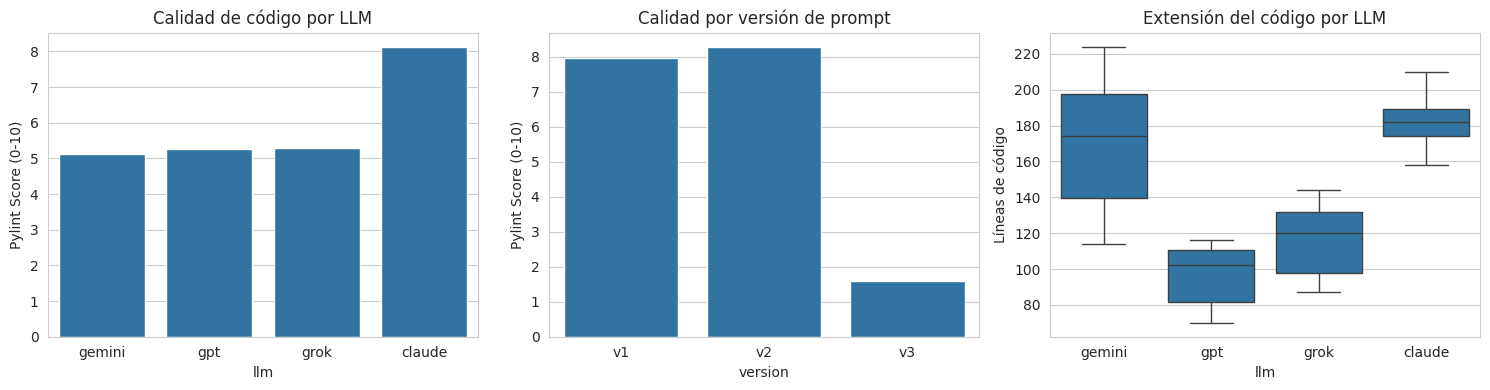


📊 CONCLUSIONES:
✅ Mejor calidad por LLM: claude (8.11)
✅ Mejor calidad por versión: v2 (8.28)
📏 Código más extenso: claude (182 líneas)
📏 Código más conciso: gpt (96 líneas)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Leer resultados de evaluación estandarizada (¡cambia el nombre!)
df = pd.read_csv('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/evaluation_standard.csv')

# Convertir pylint_score a numérico (maneja NaN)
df['pylint_score'] = pd.to_numeric(df['pylint_score'], errors='coerce')

# Configurar estilo
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Pylint por LLM
sns.barplot(data=df, x='llm', y='pylint_score', ax=axes[0], errorbar=None)
axes[0].set_title('Calidad de código por LLM')
axes[0].set_ylabel('Pylint Score (0-10)')

# 2. Pylint por versión
sns.barplot(data=df, x='version', y='pylint_score', ax=axes[1], errorbar=None)
axes[1].set_title('Calidad por versión de prompt')
axes[1].set_ylabel('Pylint Score (0-10)')

# 3. Líneas de código por LLM
sns.boxplot(data=df, x='llm', y='lines_of_code', ax=axes[2])
axes[2].set_title('Extensión del código por LLM')
axes[2].set_ylabel('Líneas de código')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/evaluation_charts.png', dpi=150)
plt.show()

# Conclusiones dinámicas
print("\n📊 CONCLUSIONES:")
print(f"✅ Mejor calidad por LLM: {df.groupby('llm')['pylint_score'].mean().idxmax()} "
      f"({df.groupby('llm')['pylint_score'].mean().max():.2f})")
print(f"✅ Mejor calidad por versión: {df.groupby('version')['pylint_score'].mean().idxmax()} "
      f"({df.groupby('version')['pylint_score'].mean().max():.2f})")
print(f"📏 Código más extenso: {df.groupby('llm')['lines_of_code'].mean().idxmax()} "
      f"({df.groupby('llm')['lines_of_code'].mean().max():.0f} líneas)")
print(f"📏 Código más conciso: {df.groupby('llm')['lines_of_code'].mean().idxmin()} "
      f"({df.groupby('llm')['lines_of_code'].mean().min():.0f} líneas)")

In [ ]:
# ==============================================
# VERIFICACIÓN DE RUTAS (SIN REENTRENAR)
# ==============================================
import os
import re
import pandas as pd

BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'
MODELS_DIR = os.path.join(BASE_PATH, 'src/generated_code')
EVAL_CSV = os.path.join(BASE_PATH, 'results/evaluation_standard.csv')

# Cargar los modelos seleccionados anteriormente
df_quality = pd.read_csv(EVAL_CSV)
selected = df_quality[(df_quality['pylint_score'] >= 7.0) &
                      (df_quality['syntax_ok'] == True) &
                      (df_quality['execution_success'] == True)].copy()

def verify_dataset_paths(model_path):
    """Verifica rutas (literales o variables)"""
    try:
        with open(model_path, 'r') as f:
            content = f.read()

        # Buscar data_dir
        data_dir_match = re.search(r'data_dir\s*=\s*[\'"]([^\'"]+)[\'"]', content)
        if data_dir_match:
            data_dir = data_dir_match.group(1)
            data_dir_ok = '/content/Images/Images' in data_dir
        else:
            data_dir_ok = False

        train_ok = data_dir_ok or '/content/Images/Images/train' in content or '/content/Images/train' in content
        val_ok = data_dir_ok or '/content/Images/Images/val' in content or '/content/Images/val' in content
        test_ok = data_dir_ok or '/content/Images/Images/test' in content or '/content/Images/test' in content

        return {'train_ok': train_ok, 'val_ok': val_ok, 'test_ok': test_ok, 'data_dir_ok': data_dir_ok}
    except:
        return {'train_ok': False, 'val_ok': False, 'test_ok': False, 'data_dir_ok': False}

print("\n🔍 VERIFICACIÓN DE RUTAS (sin reentrenar)")
print("="*70)
for _, row in selected.iterrows():
    path = os.path.join(MODELS_DIR, row['llm'], row['filename'])
    if os.path.exists(path):
        paths = verify_dataset_paths(path)
        metodo = "data_dir" if paths['data_dir_ok'] else "literal"
        print(f"{row['llm'].upper()} v{row['version']} run{row['run']}: train={paths['train_ok']}, val={paths['val_ok']}, test={paths['test_ok']} ({metodo})")
    else:
        print(f"⚠️ No se encontró: {row['filename']}")


🔍 VERIFICACIÓN DE RUTAS (sin reentrenar)
GEMINI vv1 run1: train=True, val=False, test=False (literal)
GEMINI vv1 run2: train=False, val=False, test=False (literal)
GEMINI vv2 run1: train=True, val=True, test=True (data_dir)
GEMINI vv2 run2: train=True, val=True, test=True (literal)
GPT vv1 run1: train=True, val=True, test=True (literal)
GPT vv1 run2: train=True, val=True, test=True (literal)
GPT vv2 run1: train=True, val=True, test=True (literal)
GPT vv2 run2: train=True, val=True, test=True (literal)
GROK vv1 run1: train=True, val=True, test=True (literal)
GROK vv1 run2: train=True, val=True, test=True (literal)
GROK vv2 run1: train=True, val=True, test=True (literal)
GROK vv2 run2: train=True, val=True, test=True (literal)
CLAUDE vv1 run1: train=True, val=True, test=True (literal)
CLAUDE vv1 run2: train=True, val=True, test=True (literal)
CLAUDE vv2 run1: train=True, val=True, test=True (literal)
CLAUDE vv2 run2: train=True, val=True, test=True (literal)
CLAUDE vv3 run2: train=True,

## **11. Evaluación Técnica de Modelos (mejores modelos (pylint > 7), evaluación automática, 10 épocas)**

In [ ]:
# 🚀 EVALUACIÓN TÉCNICA AUTOMÁTICA
# ==============================================

import subprocess
import sys
import os
import re
import pandas as pd
import numpy as np
!pip install psutil gputil -q
import psutil
import GPUtil

# -------------------------------
# 1. Configuración de rutas
# -------------------------------
BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'
EVAL_CSV = os.path.join(BASE_PATH, 'results/evaluation_standard.csv')
MODELS_DIR = os.path.join(BASE_PATH, 'src/generated_code')
RESULTS_DIR = os.path.join(BASE_PATH, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Parámetros de la prueba rápida
QUICK_EPOCHS = 10          # épocas para la evaluación rápida
TOP_N = 4                  # número de mejores modelos para entrenamiento completo

# -------------------------------
# 2. Función de evaluación de un modelo (reutilizable)
# -------------------------------

def verify_dataset_paths(model_path):
    """Verifica que el modelo use las rutas correctas"""
    try:
        with open(model_path, 'r') as f:
            content = f.read()
        data_dir_match = re.search(r'data_dir\s*=\s*[\'"]([^\'"]+)[\'"]', content)
        if data_dir_match:
            data_dir = data_dir_match.group(1)
            data_dir_ok = '/content/Images/Images' in data_dir
        else:
            data_dir_ok = False
        train_literal = '/content/Images/Images/train' in content or '/content/Images/train' in content
        val_literal = '/content/Images/Images/val' in content or '/content/Images/val' in content
        test_literal = '/content/Images/Images/test' in content or '/content/Images/test' in content
        train_ok = data_dir_ok or train_literal
        val_ok = data_dir_ok or val_literal
        test_ok = data_dir_ok or test_literal
        return {'train_ok': train_ok, 'val_ok': val_ok, 'test_ok': test_ok}
    except:
        return {'train_ok': False, 'val_ok': False, 'test_ok': False}

def monitor_resources():
    """Captura uso de CPU, GPU y RAM en tiempo real"""
    cpu_percent = psutil.cpu_percent(interval=1)
    ram_percent = psutil.virtual_memory().percent
    ram_used_gb = psutil.virtual_memory().used / (1024**3)

    try:
        gpus = GPUtil.getGPUs()
        if gpus:
            gpu_percent = gpus[0].load * 100
            gpu_memory_used = gpus[0].memoryUsed
        else:
            gpu_percent = 0
            gpu_memory_used = 0
    except:
        gpu_percent = 0
        gpu_memory_used = 0

    return {
        'cpu_%': cpu_percent,
        'ram_%': ram_percent,
        'ram_used_gb': round(ram_used_gb, 1),
        'gpu_%': gpu_percent,
        'gpu_memory_mb': gpu_memory_used
    }

def evaluate_model_performance(model_path, epochs_override=None):
    """Ejecuta un modelo generado y extrae métricas de rendimiento."""
    try:
        with open(model_path, 'r') as f:
            code = f.read()
    except Exception as e:
        return {'model': os.path.basename(model_path), 'success': False, 'error': f'No se pudo leer archivo: {e}'}

    if epochs_override is not None:
        code = re.sub(r'epochs\s*=\s*\d+', f'epochs={epochs_override}', code)
        code = re.sub(r'EPOCHS\s*=\s*\d+', f'EPOCHS={epochs_override}', code)

    code = code.replace('np.Inf', 'np.inf')
    code = re.sub(r'ReduceLROnPlateau\([^)]*verbose\s*=\s*True[,)]', 'ReduceLROnPlateau(', code)

    temp_path = '/tmp/temp_model_eval.py'
    with open(temp_path, 'w') as f:
        f.write(code)

    try:
        import time
        start_time = time.time()
        proc = subprocess.run(
            [sys.executable, temp_path],
            capture_output=True,
            text=True,
            timeout=3600
        )
        elapsed_time = time.time() - start_time
        output = proc.stdout
        error = proc.stderr

        metrics = {
            'model': os.path.basename(model_path),
            'success': proc.returncode == 0,
            'error': error if proc.returncode != 0 else None,
            'accuracy': None,
            'f1_score': None,
            'val_loss': None,
            'test_accuracy': None,
            'test_loss': None,
            'execution_time': elapsed_time,
        }

        val_acc_match = re.search(r'val_accuracy[:\s=]+([0-9.]+)', output, re.IGNORECASE)
        if val_acc_match:
            metrics['accuracy'] = float(val_acc_match.group(1))

        test_acc_match = re.search(r'test_accuracy[:\s=]+([0-9.]+)', output, re.IGNORECASE)
        if test_acc_match:
            metrics['test_accuracy'] = float(test_acc_match.group(1))

        f1_match = re.search(r'f1[_-]?score[:\s=]+([0-9.]+)', output, re.IGNORECASE)
        if f1_match:
            metrics['f1_score'] = float(f1_match.group(1))

        val_loss_match = re.search(r'val_loss[:\s=]+([0-9.]+)', output, re.IGNORECASE)
        if val_loss_match:
            metrics['val_loss'] = float(val_loss_match.group(1))

        test_loss_match = re.search(r'test_loss[:\s=]+([0-9.]+)', output, re.IGNORECASE)
        if test_loss_match:
            metrics['test_loss'] = float(test_loss_match.group(1))

         # Recursos consumidos durante la ejecución
        resources = monitor_resources()
        metrics['cpu_percent'] = resources['cpu_%']
        metrics['ram_percent'] = resources['ram_%']
        metrics['ram_used_gb'] = resources['ram_used_gb']
        metrics['gpu_percent'] = resources['gpu_%']
        metrics['gpu_memory_mb'] = resources['gpu_memory_mb']

        return metrics

    except subprocess.TimeoutExpired:
        return {'model': os.path.basename(model_path), 'success': False, 'error': 'Timeout (>1 hora)'}
    except Exception as e:
        return {'model': os.path.basename(model_path), 'success': False, 'error': str(e)}

# -------------------------------
# 3. Cargar evaluación de calidad y filtrar modelos
# -------------------------------
print("📊 Cargando resultados de calidad de código...")
df_quality = pd.read_csv(EVAL_CSV)

df_quality['pylint_score'] = pd.to_numeric(df_quality['pylint_score'], errors='coerce')
df_quality['syntax_ok'] = df_quality['syntax_ok'].astype(bool)

selected = df_quality[(df_quality['pylint_score'] >= 7.0) &
                      (df_quality['syntax_ok'] == True) &
                      (df_quality['execution_success'] == True)].copy()

if selected.empty:
    print("⚠️ No se encontraron modelos. Ajusta el umbral.")
    sys.exit(0)

selected = selected.sort_values('pylint_score', ascending=False).reset_index(drop=True)

print("\n✅ Modelos seleccionados para evaluación técnica rápida:")
print("="*70)
for i, row in selected.iterrows():
    print(f"{i+1:<3} {row['llm']:<12} {row['version']:<10} {row['run']:<6} {row['pylint_score']:<8.2f}")

# Construir lista de rutas
model_list = []
for _, row in selected.iterrows():
    path = os.path.join(MODELS_DIR, row['llm'], row['filename'])
    if os.path.exists(path):
        model_list.append(path)

print(f"\n🎯 Se evaluarán {len(model_list)} modelos con {QUICK_EPOCHS} épocas.")

# -------------------------------
# 4. Evaluación rápida (10 épocas)
# -------------------------------
results_quick = []
for i, path in enumerate(model_list, 1):
    print(f"\n[{i}/{len(model_list)}] Evaluando: {os.path.basename(path)}")
    res = evaluate_model_performance(path, epochs_override=QUICK_EPOCHS)
    res['filepath'] = path
    fname = os.path.basename(path)
    parts = fname.replace('.py', '').split('_')
    res['llm'] = parts[3] if len(parts) > 3 else 'unknown'
    res['version'] = parts[0] if parts[0].startswith('v') else 'v1'
    run_value = '1'
    for part in parts:
      if part.startswith('run'):
          run_value = part.replace('run', '')
          break
    res['run'] = run_value

    results_quick.append(res)

df_quick = pd.DataFrame(results_quick)
quick_csv = os.path.join(RESULTS_DIR, 'technical_quick_eval.csv')
df_quick.to_csv(quick_csv, index=False)
print(f"\n💾 Resultados guardados en: {quick_csv}")

# -------------------------------
# 5. Seleccionar los mejores para entrenamiento completo
# -------------------------------
df_success = df_quick[(df_quick['success'] == True) & (df_quick['test_accuracy'].notna())].copy()
df_success = df_success.sort_values('test_accuracy', ascending=False)

print("\n" + "="*70)
print("🏆 TOP 4 MODELOS PARA ENTRENAMIENTO COMPLETO")
print("="*70)

df_top_final = df_success.head(TOP_N).copy()
df_top_final['llm_name'] = df_top_final['llm'].apply(lambda x:
    'GPT-4o' if 'gpt' in str(x).lower() else
    'Claude' if 'claude' in str(x).lower() else
    'Gemini' if 'gemini' in str(x).lower() else
    'Grok' if 'grok' in str(x).lower() else str(x))

df_top_display = df_top_final[['llm_name', 'version', 'run', 'test_accuracy', 'f1_score', 'execution_time']]
df_top_display.columns = ['LLM', 'Versión', 'Run', 'Test Acc', 'F1', 'Tiempo(s)']
print(df_top_display.to_string(index=False))

# Guardar mejores modelos para Celda 11
best_models_path = os.path.join(RESULTS_DIR, 'best_models_for_full_train.csv')
df_top_final[['filepath', 'llm', 'version', 'run', 'test_accuracy', 'f1_score']].to_csv(best_models_path, index=False)
print(f"\n💾 Lista de mejores modelos guardada en: {best_models_path}")

# -------------------------------
# 6. Resumen final
# -------------------------------
print("\n" + "="*70)
print("📈 RESUMEN DE LA EVALUACIÓN TÉCNICA")
print("="*70)

exitosos = df_quick['success'].sum()
total = len(df_quick)
print(f"✅ Modelos que completaron 10 épocas: {exitosos}/{total} ({100*exitosos/total:.1f}%)")

tiempos_validos = df_quick[df_quick['execution_time'].notna()]['execution_time']
if len(tiempos_validos) > 0:
    print(f"⏱️  Tiempo promedio (10 épocas): {tiempos_validos.mean():.1f}s")

if df_success is not None and len(df_success) > 0:
    mejor = df_success.iloc[0]
    llm_name = 'GPT-4o' if 'gpt' in str(mejor['llm']).lower() else 'Claude' if 'claude' in str(mejor['llm']).lower() else 'Gemini' if 'gemini' in str(mejor['llm']).lower() else 'Grok'
    print(f"🏆 Mejor modelo: {llm_name} v{mejor['version']} run{mejor['run']} - Test Acc: {mejor['test_accuracy']:.3f}")

print(f"\n💾 Resultados guardados en: {quick_csv}")
print(f"💾 Mejores modelos guardados en: {best_models_path}")


  Preparing metadata (setup.py) ... done
📊 Cargando resultados de calidad de código...

✅ Modelos seleccionados para evaluación técnica rápida:
1   claude       v2         1      9.21    
2   claude       v2         2      9.19    
3   claude       v1         2      9.08    
4   gpt          v2         2      8.67    
5   grok         v2         2      8.64    
6   claude       v1         1      8.38    
7   grok         v1         2      8.21    
8   gpt          v1         2      8.13    
9   gemini       v1         1      8.00    
10  gemini       v2         1      7.98    
11  grok         v1         1      7.81    
12  gemini       v2         2      7.70    
13  gpt          v2         1      7.65    
14  grok         v2         1      7.16    
15  gpt          v1         1      7.09    
16  claude       v3         2      7.09    
17  gemini       v1         2      7.08    

🎯 Se evaluarán 17 modelos con 10 épocas.

[1/17] Evaluando: v2_pytorch_cnn_claude-sonnet-4-6_claude_run1_20

## **12. Guardar resultados preliminares (Evaluación 10 épocas)**

In [ ]:
# ==============================================
# RECUPERAR RESULTADOS Y GUARDAR MEJORES MODELOS
# ==============================================
import pandas as pd
import os

BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'
RESULTS_DIR = os.path.join(BASE_PATH, 'results')
TOP_N = 4

# Cargar resultados ya existentes
csv_path = os.path.join(RESULTS_DIR, 'technical_quick_eval.csv')
df_quick = pd.read_csv(csv_path)

print(f"📊 Cargados {len(df_quick)} registros de {csv_path}")

# Filtrar modelos exitosos con test_accuracy
df_success = df_quick[(df_quick['success'] == True) & (df_quick['test_accuracy'].notna())].copy()
df_success = df_success.sort_values('test_accuracy', ascending=False)

print("\n🏆 TOP 4 MODELOS PARA ENTRENAMIENTO COMPLETO")
print("="*70)
df_top_final = df_success.head(TOP_N).copy()
print(df_top_final[['llm', 'version', 'run', 'test_accuracy', 'f1_score']].to_string(index=False))

# Guardar para Celda 11
best_models_path = os.path.join(RESULTS_DIR, 'best_models_for_full_train.csv')
# Asegurarse de que existe la columna filepath
if 'filepath' not in df_top_final.columns:
    # Reconstruir filepath a partir de llm, version, run
    filepaths = []
    for _, row in df_top_final.iterrows():
        # Buscar el archivo original en los datos
        matching = df_quick[df_quick['llm'] == row['llm']]
        if len(matching) > 0:
            filepaths.append(matching.iloc[0].get('filepath', 'unknown'))
        else:
            filepaths.append('unknown')
    df_top_final['filepath'] = filepaths

df_top_final[['filepath', 'llm', 'version', 'run', 'test_accuracy', 'f1_score']].to_csv(best_models_path, index=False)
print(f"\n✅ Lista de mejores modelos guardada en: {best_models_path}")

📊 Cargados 17 registros de /content/drive/MyDrive/LeLePhid_LLM_CNN/results/technical_quick_eval.csv

🏆 TOP 4 MODELOS PARA ENTRENAMIENTO COMPLETO
                    llm version  run  test_accuracy  f1_score
                 gpt-4o      v2    2           0.99    0.9900
                 gpt-4o      v1    1           0.98    0.9792
grok-4-1-fast-reasoning      v2    2           0.98    0.9796
grok-4-1-fast-reasoning      v2    1           0.97    0.9709

✅ Lista de mejores modelos guardada en: /content/drive/MyDrive/LeLePhid_LLM_CNN/results/best_models_for_full_train.csv


In [ ]:
!nvidia-smi

Sun May 31 19:35:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **13. Evaluación técnica completa con los mejores modelos (TOP N modelos, 50 épocas)**

In [ ]:
# ==============================================
# 🚀 ENTRENAMIENTO COMPLETO (50 épocas) CON MÉTRICAS INDIVIDUALES
# ==============================================

import subprocess
import sys
import os
import re
import pandas as pd
import numpy as np
import time
import psutil
import threading

# ==============================================
# FUNCIÓN DE MONITOREO POR MODELO (SIN ACUMULACIÓN)
# ==============================================

def monitor_single_model(model_path, epochs_override=None, interval=10, timeout=7200):
    """
    Ejecuta un modelo y captura sus métricas de recursos de forma aislada.
    Retorna: (stats_dict, output, error, elapsed_time)
    """
    try:
        with open(model_path, 'r') as f:
            code = f.read()
    except Exception as e:
        return {'error': str(e), 'success': False}, "", str(e), 0

    # Modificar épocas si es necesario
    if epochs_override is not None:
        code = re.sub(r'epochs\s*=\s*\d+', f'epochs={epochs_override}', code)
        code = re.sub(r'EPOCHS\s*=\s*\d+', f'EPOCHS={epochs_override}', code)

    code = code.replace('np.Inf', 'np.inf')
    code = re.sub(r'ReduceLROnPlateau\([^)]*verbose\s*=\s*True[,)]', 'ReduceLROnPlateau(', code)

    temp_path = '/tmp/temp_model_eval.py'
    with open(temp_path, 'w') as f:
        f.write(code)

    # Variables locales para este modelo (NO globales)
    gpu_samples = []
    cpu_samples = []
    ram_samples = []
    stop_event = threading.Event()

    def sampler():
        while not stop_event.is_set():
            try:
                # CPU y RAM
                cpu = psutil.cpu_percent(interval=0.5)
                ram_gb = psutil.virtual_memory().used / (1024**3)

                # GPU
                gpu = 0
                try:
                    result = subprocess.run(
                        ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,noheader,nounits'],
                        capture_output=True, text=True, timeout=2
                    )
                    if result.returncode == 0 and result.stdout.strip():
                        gpu = float(result.stdout.strip())
                except:
                    pass

                gpu_samples.append(gpu)
                cpu_samples.append(cpu)
                ram_samples.append(ram_gb)
            except:
                pass
            time.sleep(interval)

    # Iniciar monitoreo en segundo plano
    thread = threading.Thread(target=sampler, daemon=True)
    thread.start()

    try:
        start_time = time.time()
        proc = subprocess.run(
            [sys.executable, temp_path],
            capture_output=True,
            text=True,
            timeout=timeout
        )
        elapsed = time.time() - start_time
        output = proc.stdout
        error = proc.stderr
        success = proc.returncode == 0
    except subprocess.TimeoutExpired:
        return {'error': 'Timeout', 'success': False}, "", "", timeout
    except Exception as e:
        return {'error': str(e), 'success': False}, "", str(e), 0
    finally:
        # Detener monitoreo
        stop_event.set()
        thread.join(timeout=5)

    # Calcular estadísticas SOLO de este modelo
    stats = {
        'success': success,
        'error': error if not success else None,
        'execution_time': elapsed,
        'cpu_avg': sum(cpu_samples) / len(cpu_samples) if cpu_samples else 0,
        'cpu_max': max(cpu_samples) if cpu_samples else 0,
        'ram_avg_gb': sum(ram_samples) / len(ram_samples) if ram_samples else 0,
        'ram_max_gb': max(ram_samples) if ram_samples else 0,
        'gpu_avg': sum(gpu_samples) / len(gpu_samples) if gpu_samples else 0,
        'gpu_max': max(gpu_samples) if gpu_samples else 0,
        'num_samples': len(gpu_samples)
    }

    return stats, output, error, elapsed

# ==============================================
# EXTRACCIÓN DE MÉTRICAS DEL OUTPUT
# ==============================================

def extract_metrics_from_output(output):
    """Extrae test_accuracy, f1_score, val_loss del stdout"""
    metrics = {'test_accuracy': None, 'f1_score': None, 'val_loss': None}

    test_acc_match = re.search(r'test_accuracy[:\s=]+([0-9.]+)', output, re.IGNORECASE)
    if test_acc_match:
        metrics['test_accuracy'] = float(test_acc_match.group(1))

    f1_match = re.search(r'f1[_-]?score[:\s=]+([0-9.]+)', output, re.IGNORECASE)
    if f1_match:
        metrics['f1_score'] = float(f1_match.group(1))

    val_loss_match = re.search(r'val_loss[:\s=]+([0-9.]+)', output, re.IGNORECASE)
    if val_loss_match:
        metrics['val_loss'] = float(val_loss_match.group(1))

    return metrics

# ==============================================
# MAIN: ENTRENAMIENTO COMPLETO (50 épocas)
# ==============================================

BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'
RESULTS_DIR = os.path.join(BASE_PATH, 'results')

best_csv = os.path.join(RESULTS_DIR, 'best_models_for_full_train.csv')
if not os.path.exists(best_csv):
    raise FileNotFoundError(f"No se encontró {best_csv}. Ejecuta primero la Celda 10.")

best_models = pd.read_csv(best_csv)

def extract_run_from_path(filepath):
    fname = os.path.basename(filepath)
    parts = fname.replace('.py', '').split('_')
    for part in parts:
        if part.startswith('run'):
            return part.replace('run', '')
    return '1'

best_models['run'] = best_models['filepath'].apply(extract_run_from_path)
print(f"Se entrenarán {len(best_models)} modelos con 50 épocas")

full_results = []
for i, row in best_models.iterrows():
    path = row['filepath']
    print(f"\n[{i+1}/{len(best_models)}] Entrenando: {os.path.basename(path)}")

    # Monitoreo individual
    stats, output, error, elapsed = monitor_single_model(path, epochs_override=50)

    # Extraer métricas del output
    metrics = extract_metrics_from_output(output)

    # Construir resultado
    result = {
        'llm': row['llm'],
        'version': row['version'],
        'run': row['run'],
        'filepath': path,
        'success': stats['success'],
        'execution_time': stats['execution_time'],
        'cpu_avg': stats['cpu_avg'],
        'cpu_max': stats['cpu_max'],
        'ram_avg_gb': stats['ram_avg_gb'],
        'ram_max_gb': stats['ram_max_gb'],
        'gpu_avg': stats['gpu_avg'],
        'gpu_max': stats['gpu_max'],
        'num_samples': stats['num_samples'],
        'test_accuracy': metrics['test_accuracy'],
        'f1_score': metrics['f1_score'],
        'val_loss': metrics['val_loss'],
        'error': stats['error']
    }
    full_results.append(result)

df_full = pd.DataFrame(full_results)
output_path = os.path.join(RESULTS_DIR, 'technical_full_eval.csv')
df_full.to_csv(output_path, index=False)

print("\n✅ Resultados de entrenamiento completo guardados en:", output_path)

# ==============================================
# TABLA DE RESULTADOS INDIVIDUALES
# ==============================================
print("\n" + "="*80)
print("📊 RESULTADOS INDIVIDUALES (50 épocas)")
print("="*80)

cols_display = ['llm', 'version', 'run', 'test_accuracy', 'f1_score', 'execution_time',
                'gpu_avg', 'gpu_max', 'cpu_avg', 'ram_avg_gb']
print(df_full[cols_display].to_string(index=False))

# ==============================================
# RESUMEN ESTADÍSTICO (para tesis)
# ==============================================
print("\n" + "="*80)
print("📈 RESUMEN ESTADÍSTICO POR MODELO")
print("="*80)

for _, row in df_full.iterrows():
    print(f"\n🔹 {row['llm']} v{row['version']} run{row['run']}")
    print(f"   ✅ Test Accuracy: {row['test_accuracy']:.3f}")
    print(f"   ✅ F1-Score: {row['f1_score']:.3f}")
    print(f"   ⏱️  Tiempo: {row['execution_time']:.1f}s")
    print(f"   🖥️  GPU: {row['gpu_avg']:.1f}% (max {row['gpu_max']:.1f}%)")
    print(f"   🧠 CPU: {row['cpu_avg']:.1f}% (max {row['cpu_max']:.1f}%)")
    print(f"   💾 RAM: {row['ram_avg_gb']:.1f} GB")

print("\n" + "="*80)
print("✅ Todas las métricas son individuales por modelo. Listo para múltiples corridas.")

Se entrenarán 4 modelos con 50 épocas

[1/4] Entrenando: v2_pytorch_cnn_gpt-4o_gpt_run2_20260530_182426.py

[2/4] Entrenando: v1_base_cnn_gpt-4o_gpt_run1_20260530_181749.py

[3/4] Entrenando: v2_pytorch_cnn_grok-4-1-fast-reasoning_grok_run2_20260530_182503.py

[4/4] Entrenando: v2_pytorch_cnn_grok-4-1-fast-reasoning_grok_run1_20260530_182451.py

✅ Resultados de entrenamiento completo guardados en: /content/drive/MyDrive/LeLePhid_LLM_CNN/results/technical_full_eval.csv

📊 RESULTADOS INDIVIDUALES (50 épocas)
                    llm version run  test_accuracy  f1_score  execution_time   gpu_avg  gpu_max   cpu_avg  ram_avg_gb
                 gpt-4o      v2   2           0.97    0.9700       93.106438 20.666667     43.0 72.777778    2.609787
                 gpt-4o      v1   1           0.97    0.9684       81.756002 28.875000     45.0 68.562500    2.548578
grok-4-1-fast-reasoning      v2   2           0.98    0.9796       76.711123 32.125000     71.0 91.500000    2.536613
grok-4-1-fast-re

## **14.0 Limpieza y Verificación de carpetas antes de arrancar el Loop completo**

In [ ]:
# ==============================================
# 🗑️ LIMPIEZA MANUAL DE CARPETAS (ejecuta primero)
# ==============================================
import os
import shutil

BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'

# Carpetas a limpiar completamente
carpetas = [
    os.path.join(BASE_PATH, 'src', 'generated_code'),
    os.path.join(BASE_PATH, 'src', 'historical_models'),
    os.path.join(BASE_PATH, 'resultados_multiple_runs')
]

print("="*60)
print("🗑️ LIMPIANDO CARPETAS DEL PROYECTO")
print("="*60)

for carpeta in carpetas:
    if os.path.exists(carpeta):
        shutil.rmtree(carpeta)
        print(f"✅ Eliminada: {carpeta}")
    else:
        print(f"⚠️ No existía: {carpeta}")

    # Volver a crear la carpeta vacía
    os.makedirs(carpeta, exist_ok=True)
    print(f"📁 Creada (vacía): {carpeta}")

# Limpiar prompts viejos (pero conservar la carpeta)
prompts_dir = os.path.join(BASE_PATH, 'src', 'prompts')
if os.path.exists(prompts_dir):
    for file in os.listdir(prompts_dir):
        filepath = os.path.join(prompts_dir, file)
        if os.path.isfile(filepath):
            os.remove(filepath)
            print(f"🗑️ Eliminado prompt: {file}")
    print(f"✅ Prompts limpiados (carpeta conservada)")
else:
    os.makedirs(prompts_dir, exist_ok=True)
    print(f"📁 Carpeta prompts creada")

print("\n" + "="*60)
print("✅ LIMPIEZA COMPLETADA")
print("="*60)

# Verificar que quedaron vacías
print("\n🔍 VERIFICACIÓN:")
for carpeta in carpetas:
    contenido = os.listdir(carpeta)
    print(f"   {carpeta}: {contenido if contenido else '✅ VACÍA'}")

prompts_contenido = os.listdir(prompts_dir) if os.path.exists(prompts_dir) else []
print(f"   src/prompts: {prompts_contenido if prompts_contenido else '✅ VACÍA'}")

# ==============================================
# 🔍 VERIFICACIÓN MANUAL DE CARPETAS
# ==============================================
print("\n" + "="*60)
print("🔍 ESTADO ACTUAL DE CARPETAS")
print("="*60)

carpetas_a_verificar = [
    ('src/generated_code', 'Modelos generados'),
    ('src/historical_models', 'Modelos históricos'),
    ('src/prompts', 'Prompts'),
    ('resultados_multiple_runs', 'Resultados múltiples')
]

for carpeta, desc in carpetas_a_verificar:
    full_path = os.path.join(BASE_PATH, carpeta)
    if os.path.exists(full_path):
        contenido = os.listdir(full_path)
        if contenido:
            print(f"⚠️ {desc}: {len(contenido)} archivos encontrados")
            print(f"   Ejemplo: {contenido[:3]}")
        else:
            print(f"✅ {desc}: VACÍA (lista para correr)")
    else:
        print(f"📁 {desc}: Carpeta no existe (se creará automáticamente)")

print("\n" + "="*60)
print("✅ VERIFICACIÓN COMPLETADA")
print("="*60)

🗑️ LIMPIANDO CARPETAS DEL PROYECTO
✅ Eliminada: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code
📁 Creada (vacía): /content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code
✅ Eliminada: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/historical_models
📁 Creada (vacía): /content/drive/MyDrive/LeLePhid_LLM_CNN/src/historical_models
✅ Eliminada: /content/drive/MyDrive/LeLePhid_LLM_CNN/resultados_multiple_runs
📁 Creada (vacía): /content/drive/MyDrive/LeLePhid_LLM_CNN/resultados_multiple_runs
🗑️ Eliminado prompt: prompt.txt
✅ Prompts limpiados (carpeta conservada)

✅ LIMPIEZA COMPLETADA

🔍 VERIFICACIÓN:
   /content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code: ✅ VACÍA
   /content/drive/MyDrive/LeLePhid_LLM_CNN/src/historical_models: ✅ VACÍA
   /content/drive/MyDrive/LeLePhid_LLM_CNN/resultados_multiple_runs: ✅ VACÍA
   src/prompts: ✅ VACÍA

🔍 ESTADO ACTUAL DE CARPETAS
✅ Modelos generados: VACÍA (lista para correr)
✅ Modelos históricos: VACÍA (lista para correr)
✅ Prompts: VACÍA 

## **14.1 Loop para el historial de corridas (Seleccionar los mejores modelos)**

In [ ]:
# ==============================================
# 🚀 LOOP DE 10 CORRIDAS COMPLETAS (VERSIÓN TESIS)
# ==============================================

import os
import shutil
import pandas as pd
import time
import re
import subprocess
import sys
import json
import numpy as np
import psutil
import threading
from datetime import datetime
from sklearn.model_selection import train_test_split

# ==============================================
# 0. REORGANIZAR DATASET (para Gemini)
# ==============================================
print("="*80)
print("📁 REORGANIZANDO DATASET (train/val/test)")
print("="*80)

ruta_original = '/content/Images/Images'

# Buscar imágenes
data = []
for root, dirs, files in os.walk(ruta_original):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg')):
            data.append({'image_path': os.path.join(root, file), 'image_name': file})

df_images = pd.DataFrame(data)
df_images['label'] = df_images['image_name'].apply(lambda x: 'aphids' if 'aphid' in x.lower() else 'healthy')

# Dividir 70/15/15
train_df, temp_df = train_test_split(df_images, test_size=0.3, stratify=df_images['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# Crear estructura train/val/test
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    for label in ['aphids', 'healthy']:
        label_path = os.path.join(ruta_original, split_name, label)
        os.makedirs(label_path, exist_ok=True)
        for _, row in split_df[split_df['label'] == label].iterrows():
            dest = os.path.join(label_path, row['image_name'])
            if not os.path.exists(dest):
                shutil.copy2(row['image_path'], dest)

print("✅ Dataset reorganizado")
for split in ['train', 'val', 'test']:
    path = os.path.join(ruta_original, split)
    if os.path.exists(path):
        aphids = len(os.listdir(os.path.join(path, 'aphids'))) if os.path.exists(os.path.join(path, 'aphids')) else 0
        healthy = len(os.listdir(os.path.join(path, 'healthy'))) if os.path.exists(os.path.join(path, 'healthy')) else 0
        print(f"   {split}: aphids={aphids}, healthy={healthy}")

# ==============================================
# 0.1 GENERAR PROMPTS v2 y v3 (si no existen)
# ==============================================
print("="*80)
print("📝 VERIFICANDO PROMPTS v2_pytorch y v3_tensorflow")
print("="*80)

BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'
prompts_dir = os.path.join(BASE_PATH, 'src', 'prompts')
os.makedirs(prompts_dir, exist_ok=True)

# Leer prompt base
prompt_base_path = os.path.join(prompts_dir, 'prompt.txt')
if not os.path.exists(prompt_base_path):
    raise FileNotFoundError(f"No se encontró {prompt_base_path}. Ejecuta primero la Celda 5.")

with open(prompt_base_path, 'r') as f:
    base_prompt = f.read()

# Crear prompt_v2_pytorch.txt
pytorch_path = os.path.join(prompts_dir, 'prompt_v2_pytorch.txt')
if not os.path.exists(pytorch_path):
    pytorch_prompt = base_prompt.replace(
        "Framework: Puedes elegir PyTorch o TensorFlow.",
        "Framework: SOLO PyTorch (NO usar TensorFlow bajo ninguna circunstancia)."
    )
    with open(pytorch_path, 'w') as f:
        f.write(pytorch_prompt)
    print(f"✅ Creado: {pytorch_path}")
else:
    print(f"✅ Ya existe: {pytorch_path}")

# Crear prompt_v3_tensorflow.txt
tensorflow_path = os.path.join(prompts_dir, 'prompt_v3_tensorflow.txt')
if not os.path.exists(tensorflow_path):
    tensorflow_prompt = base_prompt.replace(
        "Framework: Puedes elegir PyTorch o TensorFlow.",
        "Framework: SOLO TensorFlow (NO usar PyTorch bajo ninguna circunstancia)."
    )
    with open(tensorflow_path, 'w') as f:
        f.write(tensorflow_prompt)
    print(f"✅ Creado: {tensorflow_path}")
else:
    print(f"✅ Ya existe: {tensorflow_path}")

# ==============================================
# CONFIGURACIÓN INICIAL
# ==============================================
NUM_RUNS = 10
RESULTS_DIR = os.path.join(BASE_PATH, 'resultados_multiple_runs')
HISTORICAL_MODELS_DIR = os.path.join(BASE_PATH, 'src', 'historical_models')

# Obtener API keys
from google.colab import userdata
gemini_key = userdata.get('GEMINI_KEY')
openai_key = userdata.get('OPENAI_KEY')
grok_key = userdata.get('GROKAI_KEY')
claude_key = userdata.get('CLAUDE_KEY')

ruta_extraccion = '/content/Images/Images'

# ==============================================
# FUNCIONES DE GENERACIÓN
# ==============================================

def generate_cnn_code(prompt, llm_type='gemini', temperature=0.7, prompt_version=None):
    try:
        if llm_type == 'gemini':
            import google.generativeai as genai
            genai.configure(api_key=gemini_key)
            model = genai.GenerativeModel('gemini-2.5-pro')
            response = model.generate_content(prompt)
            code = response.text
        elif llm_type == 'gpt':
            from openai import OpenAI
            client = OpenAI(api_key=openai_key)
            response = client.chat.completions.create(
                model='gpt-4o',
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature
            )
            code = response.choices[0].message.content
        elif llm_type == 'grok':
            from openai import OpenAI
            client = OpenAI(api_key=grok_key, base_url="https://api.x.ai/v1")
            response = client.chat.completions.create(
                model='grok-4-1-fast-reasoning',
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature
            )
            code = response.choices[0].message.content
        elif llm_type == 'claude':
            from anthropic import Anthropic
            client = Anthropic(api_key=claude_key)
            response = client.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=4000,
                temperature=temperature,
                messages=[{"role": "user", "content": prompt}]
            )
            code = response.content[0].text
        else:
            return None
        if prompt_version:
            code = f"# Prompt_version: {prompt_version}\n\n" + code
        return code
    except Exception as e:
        print(f"❌ Error con {llm_type}: {e}")
        return None

def generate_all_models(prompt, runs_per_llm=2, prompt_version="v1_base", run_number=None):
    llms = ['gemini', 'gpt', 'grok', 'claude']
    results = []
    model_names = {
        'gemini': 'gemini-2.5-pro',
        'gpt': 'gpt-4o',
        'grok': 'grok-4-1-fast-reasoning',
        'claude': 'claude-sonnet-4-6'
    }

    if run_number:
        base_code_dir = os.path.join(HISTORICAL_MODELS_DIR, f'run_{run_number}')
    else:
        base_code_dir = os.path.join(BASE_PATH, 'src', 'generated_code')
    os.makedirs(base_code_dir, exist_ok=True)

    for llm in llms:
        print(f"GENERANDO {llm.upper()} - {prompt_version}")
        llm_dir = os.path.join(base_code_dir, llm)
        os.makedirs(llm_dir, exist_ok=True)
        model_specific = model_names.get(llm, llm)
        for run in range(1, runs_per_llm + 1):
            print(f"📝 Run {run}/{runs_per_llm}...")
            code = generate_cnn_code(prompt, llm_type=llm, temperature=0.7, prompt_version=prompt_version)
            if code:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                filename = f"{prompt_version}_cnn_{model_specific}_{llm}_run{run}_{timestamp}.py"
                filepath = os.path.join(llm_dir, filename)
                with open(filepath, 'w') as f:
                    f.write(code)
                results.append({'llm': llm, 'model': model_specific, 'run': run, 'filepath': filepath, 'filename': filename})
            time.sleep(2 if llm == 'gemini' else 1)
    return results

# ==============================================
# FUNCIONES DE LIMPIEZA Y EVALUACIÓN
# ==============================================

def extract_python_code(content):
    lines = content.split('\n')
    code_lines = []
    capture = False
    for line in lines:
        if line.strip().startswith('```python'):
            capture = True
            continue
        elif line.strip() == '```':
            capture = False
            continue
        if capture:
            code_lines.append(line)
    if not code_lines:
        start = 0
        for i, line in enumerate(lines):
            if re.match(r'^\s*(import|from|def|class|if __name__)', line):
                start = i
                break
        code_lines = lines[start:]
    while code_lines and not code_lines[0].strip():
        code_lines.pop(0)
    if not code_lines:
        return content
    return '\n'.join(code_lines)

def patch_code_errors(code):
    code = code.replace('np.Inf', 'np.inf')
    code = re.sub(r'ReduceLROnPlateau\([^)]*verbose\s*=\s*True[,)]', 'ReduceLROnPlateau(', code)
    code = re.sub(r"'/content/Images/train/", r"'/content/Images/Images/train/", code)
    code = re.sub(r"'/content/Images/val/", r"'/content/Images/Images/val/", code)
    code = re.sub(r"'/content/Images/test/", r"'/content/Images/Images/test/", code)
    code = re.sub(r"data_dir\s*=\s*['\"]/content/Images['\"]", "data_dir = '/content/Images/Images'", code)
    return code

def run_pylint_standard(filepath):
    try:
        proc = subprocess.run(['pylint', filepath, '--score=y', '--exit-zero'],
                              capture_output=True, text=True, timeout=30)
        for line in proc.stdout.split('\n'):
            if 'rated at' in line:
                return float(line.split('rated at')[1].split('/')[0])
        return 0.0
    except:
        return 0.0

def check_syntax_standard(filepath):
    try:
        with open(filepath, 'r') as f:
            compile(f.read(), filepath, 'exec')
        return True
    except:
        return False

def check_imports_standard(filepath):
    required_imports = ['torch', 'tensorflow', 'numpy', 'PIL']
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        found = [imp for imp in required_imports if imp in content]
        return len(found) / len(required_imports)
    except:
        return 0.0

def test_execution(filepath):
    try:
        with open(filepath, 'r') as f:
            code = f.read()
        code = re.sub(r'epochs\s*=\s*\d+', 'epochs=1', code)
        code = re.sub(r'EPOCHS\s*=\s*\d+', 'EPOCHS=1', code)
        code = code.replace('np.Inf', 'np.inf')
        code = re.sub(r'ReduceLROnPlateau\([^)]*verbose\s*=\s*True[,)]', 'ReduceLROnPlateau(', code)
        code = re.sub(r'weights\s*=\s*[\'"]IMAGENET[^\'"]+[\'"]', 'weights=None', code)
        code = re.sub(r'pretrained\s*=\s*True', 'pretrained=False', code)
        code += '\nprint("✅ Prueba completada"); import sys; sys.exit(0)'
        temp_file = '/tmp/test_exec.py'
        with open(temp_file, 'w') as f:
            f.write(code)
        start = time.time()
        proc = subprocess.run([sys.executable, temp_file], capture_output=True, text=True, timeout=None)
        elapsed = time.time() - start
        return proc.returncode == 0, elapsed, None
    except Exception as e:
        return False, 0, str(e)

def evaluate_model_standard(filepath, version, llm, run, model):
    success, exec_time, error = test_execution(filepath)
    return {
        'llm': llm, 'model': model, 'version': version, 'run': run,
        'filename': os.path.basename(filepath),
        'pylint_score': run_pylint_standard(filepath),
        'syntax_ok': check_syntax_standard(filepath),
        'imports_ratio': check_imports_standard(filepath),
        'lines_of_code': sum(1 for _ in open(filepath) if _.strip() and not _.strip().startswith('#')),
        'execution_success': success, 'execution_time': exec_time,
        'filepath': filepath
    }

def evaluate_all_models_standard(run_number):
    base_dir = os.path.join(HISTORICAL_MODELS_DIR, f'run_{run_number}')
    results = []
    model_names = {'gemini': 'gemini-2.5-pro', 'gpt': 'gpt-4o',
                   'grok': 'grok-4-1-fast-reasoning', 'claude': 'claude-sonnet-4-6'}

    for llm in ['gemini', 'gpt', 'grok', 'claude']:
        llm_path = os.path.join(base_dir, llm)
        if not os.path.exists(llm_path):
            continue
        for file in os.listdir(llm_path):
            if not file.endswith('.py'):
                continue
            filepath = os.path.join(llm_path, file)
            parts = file.replace('.py', '').split('_')
            version = parts[0] if parts[0].startswith('v') else 'v1_base'
            run = '1'
            for part in parts:
                if part.startswith('run'):
                    run = part.replace('run', '')
                    break
            model = parts[2] if len(parts) > 2 and parts[2] in model_names.values() else model_names.get(llm, llm)
            results.append(evaluate_model_standard(filepath, version, llm, run, model))

    df = pd.DataFrame(results)
    df['pylint_score'] = pd.to_numeric(df['pylint_score'], errors='coerce').fillna(0.0)
    return df

# ==============================================
# FUNCIONES DE EVALUACIÓN TÉCNICA (CON VALIDACIÓN)
# ==============================================

def monitor_resources():
    cpu_percent = psutil.cpu_percent(interval=1)
    ram_used_gb = psutil.virtual_memory().used / (1024**3)
    gpu_percent = 0
    try:
        import GPUtil
        gpus = GPUtil.getGPUs()
        if gpus:
            gpu_percent = gpus[0].load * 100
    except:
        pass
    return {'cpu_%': cpu_percent, 'ram_used_gb': round(ram_used_gb, 1), 'gpu_%': gpu_percent}

def evaluate_model_performance(model_path, epochs_override=None):
    try:
        with open(model_path, 'r') as f:
            code = f.read()
    except Exception as e:
        return {'success': False, 'error': str(e)}
    if epochs_override is not None:
        code = re.sub(r'epochs\s*=\s*\d+', f'epochs={epochs_override}', code)
        code = re.sub(r'EPOCHS\s*=\s*\d+', f'EPOCHS={epochs_override}', code)
    code = code.replace('np.Inf', 'np.inf')
    code = re.sub(r'ReduceLROnPlateau\([^)]*verbose\s*=\s*True[,)]', 'ReduceLROnPlateau(', code)
    temp_path = '/tmp/temp_model_eval.py'
    with open(temp_path, 'w') as f:
        f.write(code)
    try:
        start = time.time()
        proc = subprocess.run([sys.executable, temp_path], capture_output=True, text=True, timeout=3600)
        elapsed = time.time() - start
        output = proc.stdout
        metrics = {'success': proc.returncode == 0, 'execution_time': elapsed}

        # Verificar que el modelo realmente completó 1 época
        if 'Epoch 1/' not in output and 'epoch 1/' not in output.lower():
            print(f"   ⚠️ Modelo no completó 1 época - asignando None")
            metrics['test_accuracy'] = None
            metrics['f1_score'] = None
            metrics['val_loss'] = None
            resources = monitor_resources()
            metrics.update(resources)
            return metrics

        test_acc_match = re.search(r'test_accuracy[:\s=]+([0-9.]+)', output, re.IGNORECASE)
        if test_acc_match:
            val = float(test_acc_match.group(1))
            if 0.5 < val < 0.99:
                metrics['test_accuracy'] = val
            else:
                print(f"   ⚠️ test_accuracy={val} rechazado (valor no realista)")
                metrics['test_accuracy'] = None
        else:
            metrics['test_accuracy'] = None

        f1_match = re.search(r'f1[_-]?score[:\s=]+([0-9.]+)', output, re.IGNORECASE)
        if f1_match:
            val = float(f1_match.group(1))
            if 0.5 < val < 0.99:
                metrics['f1_score'] = val
            else:
                metrics['f1_score'] = None
        else:
            metrics['f1_score'] = None

        val_loss_match = re.search(r'val_loss[:\s=]+([0-9.]+)', output, re.IGNORECASE)
        if val_loss_match:
            metrics['val_loss'] = float(val_loss_match.group(1))

        resources = monitor_resources()
        metrics.update(resources)
        return metrics
    except subprocess.TimeoutExpired:
        print(f"   ❌ TIMEOUT: Modelo no completó en tiempo esperado")
        return {'success': False, 'error': 'Timeout', 'test_accuracy': None, 'f1_score': None}

def monitor_single_model(model_path, epochs_override=None, interval=10, timeout=7200):
    try:
        with open(model_path, 'r') as f:
            code = f.read()
    except Exception as e:
        return {'error': str(e), 'success': False}, "", str(e), 0
    if epochs_override is not None:
        code = re.sub(r'epochs\s*=\s*\d+', f'epochs={epochs_override}', code)
        code = re.sub(r'EPOCHS\s*=\s*\d+', f'EPOCHS={epochs_override}', code)
    code = code.replace('np.Inf', 'np.inf')
    code = re.sub(r'ReduceLROnPlateau\([^)]*verbose\s*=\s*True[,)]', 'ReduceLROnPlateau(', code)
    temp_path = '/tmp/temp_model_eval.py'
    with open(temp_path, 'w') as f:
        f.write(code)
    gpu_samples, cpu_samples, ram_samples = [], [], []
    stop_event = threading.Event()
    def sampler():
        while not stop_event.is_set():
            try:
                cpu = psutil.cpu_percent(interval=0.5)
                ram_gb = psutil.virtual_memory().used / (1024**3)
                gpu = 0
                try:
                    result = subprocess.run(['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,noheader,nounits'],
                                            capture_output=True, text=True, timeout=2)
                    if result.returncode == 0 and result.stdout.strip():
                        gpu = float(result.stdout.strip())
                except:
                    pass
                gpu_samples.append(gpu)
                cpu_samples.append(cpu)
                ram_samples.append(ram_gb)
            except:
                pass
            time.sleep(interval)
    thread = threading.Thread(target=sampler, daemon=True)
    thread.start()
    try:
        start = time.time()
        proc = subprocess.run([sys.executable, temp_path], capture_output=True, text=True, timeout=timeout)
        elapsed = time.time() - start
        output = proc.stdout
        success = proc.returncode == 0

        # Verificar que realmente completó 1 época
        if success and 'Epoch 1/' not in output and 'epoch 1/' not in output.lower():
            print(f"   ⚠️ Modelo reportó éxito pero NO completó 1 época")
            success = False

    except subprocess.TimeoutExpired:
        print(f"   ❌ TIMEOUT: Modelo no completó 1 época en {timeout}s")
        return {'error': 'Timeout', 'success': False}, "", "", timeout
    finally:
        stop_event.set()
        thread.join(timeout=5)
    stats = {'success': success, 'execution_time': elapsed,
             'cpu_avg': sum(cpu_samples)/len(cpu_samples) if cpu_samples else 0,
             'cpu_max': max(cpu_samples) if cpu_samples else 0,
             'ram_avg_gb': sum(ram_samples)/len(ram_samples) if ram_samples else 0,
             'ram_max_gb': max(ram_samples) if ram_samples else 0,
             'gpu_avg': sum(gpu_samples)/len(gpu_samples) if gpu_samples else 0,
             'gpu_max': max(gpu_samples) if gpu_samples else 0,
             'num_samples': len(gpu_samples)}
    return stats, output, None, elapsed

def extract_metrics_from_output(output):
    metrics = {'test_accuracy': None, 'f1_score': None, 'val_loss': None}

    # Verificar que el modelo realmente se ejecutó
    if 'Epoch 1/' not in output and 'epoch 1/' not in output.lower():
        print(f"   ⚠️ No se encontró evidencia de entrenamiento")
        return metrics

    test_acc_match = re.search(r'test_accuracy[:\s=]+([0-9.]+)', output, re.IGNORECASE)
    if test_acc_match:
        val = float(test_acc_match.group(1))
        if 0.5 < val < 0.99:
            metrics['test_accuracy'] = val
        else:
            print(f"   ⚠️ test_accuracy={val} rechazado")

    f1_match = re.search(r'f1[_-]?score[:\s=]+([0-9.]+)', output, re.IGNORECASE)
    if f1_match:
        val = float(f1_match.group(1))
        if 0.5 < val < 0.99:
            metrics['f1_score'] = val

    val_loss_match = re.search(r'val_loss[:\s=]+([0-9.]+)', output, re.IGNORECASE)
    if val_loss_match:
        metrics['val_loss'] = float(val_loss_match.group(1))

    return metrics

def apply_code_cleaning(run_number):
    base_dir = os.path.join(HISTORICAL_MODELS_DIR, f'run_{run_number}')
    for llm in ['gemini', 'gpt', 'grok', 'claude']:
        llm_path = os.path.join(base_dir, llm)
        if os.path.exists(llm_path):
            for file in os.listdir(llm_path):
                if file.endswith('.py'):
                    filepath = os.path.join(llm_path, file)
                    with open(filepath, 'r') as f:
                        content = f.read()
                    cleaned = extract_python_code(content)
                    cleaned = patch_code_errors(cleaned)
                    with open(filepath, 'w') as f:
                        f.write(cleaned)

# ==============================================
# FUNCIÓN PARA IMPRIMIR RESUMEN DE LA CORRIDA
# ==============================================

def print_corrida_summary(df_full, run):
    """Imprime resumen de los 4 mejores modelos de la corrida"""
    if df_full is None or df_full.empty:
        print(f"   ⚠️ Corrida {run}: No hay modelos con test_accuracy válido")
        return

    print(f"\n   📊 RESUMEN CORRIDA {run} (4 mejores modelos):")
    print(f"   {'LLM':<10} {'Versión':<8} {'Test Acc':<10} {'F1':<10} {'Tiempo(s)':<10}")
    print(f"   {'-'*50}")
    for _, row in df_full.iterrows():
        acc = f"{row['test_accuracy']:.4f}" if row['test_accuracy'] else "N/A"
        f1 = f"{row['f1_score']:.4f}" if row['f1_score'] else "N/A"
        tiempo = f"{row['execution_time']:.1f}" if row['execution_time'] else "N/A"
        print(f"   {row['llm']:<10} {row['version']:<8} {acc:<10} {f1:<10} {tiempo:<10}")

# ==============================================
# CORRIDA INDIVIDUAL COMPLETA
# ==============================================

def run_single_corrida(run):
    print(f"\n{'='*80}")
    print(f"🏁 CORRIDA {run} - INICIO: {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*80}")

    # Instalar dependencias
    !pip install pylint radon -q
    !pip install psutil gputil -q

    # Generar 24 modelos (3 versiones)
    print("📝 Generando 24 modelos (v1_base, v2_pytorch, v3_tensorflow)...")

    for version, prompt_file in [
        ('v1_base', 'prompt.txt'),
        ('v2_pytorch', 'prompt_v2_pytorch.txt'),
        ('v3_tensorflow', 'prompt_v3_tensorflow.txt')
    ]:
        prompt_path = os.path.join(BASE_PATH, 'src', 'prompts', prompt_file)
        if os.path.exists(prompt_path):
            with open(prompt_path, 'r') as f:
                PROMPT = f.read()
            generate_all_models(PROMPT, runs_per_llm=2, prompt_version=version, run_number=run)
        else:
            print(f"⚠️ {prompt_file} no encontrado - omitiendo {version}")

    # Limpiar código
    print("🧹 Limpiando código...")
    apply_code_cleaning(run)

    # Evaluación de calidad
    print("📊 Evaluando calidad...")
    df_quality = evaluate_all_models_standard(run)
    df_quality['run'] = run
    quality_path = os.path.join(RESULTS_DIR, f'run{run}_quality.csv')
    df_quality.to_csv(quality_path, index=False)
    print(f"   ✅ {len(df_quality)} modelos, pylint promedio: {df_quality['pylint_score'].mean():.2f}")

    # Seleccionar modelos con pylint >= 7
    selected = df_quality[(df_quality['pylint_score'] >= 7.0) &
                          (df_quality['syntax_ok'] == True) &
                          (df_quality['execution_success'] == True)].copy()

    if selected.empty:
        print("⚠️ No hay modelos con pylint>=7. Omitiendo 10/50 épocas.")
        return

    print(f"   ✅ {len(selected)} modelos seleccionados para 10 épocas")

    # Evaluación 10 épocas
    print("⚡ Evaluando 10 épocas...")
    results_quick = []
    for _, row in selected.iterrows():
        filepath = row['filepath']
        if not os.path.exists(filepath):
            alt_path = os.path.join(HISTORICAL_MODELS_DIR, f'run_{run}', row['llm'], row['filename'])
            filepath = alt_path if os.path.exists(alt_path) else None
        if not filepath:
            continue
        res = evaluate_model_performance(filepath, epochs_override=10)
        res.update({'llm': row['llm'], 'version': row['version'], 'run': row['run'], 'filepath': filepath})
        results_quick.append(res)

    if results_quick:
        df_quick = pd.DataFrame(results_quick)
        df_quick.to_csv(os.path.join(RESULTS_DIR, f'run{run}_quick_eval.csv'), index=False)
        print(f"   ✅ {len(results_quick)} resultados")

    # Evaluación 50 épocas (top 4)
    df_success = pd.DataFrame(results_quick) if results_quick else pd.DataFrame()
    if not df_success.empty:
        df_success = df_success[(df_success['success'] == True) & (df_success['test_accuracy'].notna())]
        if not df_success.empty:
            df_success = df_success.sort_values('test_accuracy', ascending=False)
            df_top = df_success.head(4).copy()

            print("🔥 Evaluando 50 épocas...")
            full_results = []
            for _, row in df_top.iterrows():
                stats, output, _, _ = monitor_single_model(row['filepath'], epochs_override=50)
                metrics = extract_metrics_from_output(output)
                full_results.append({
                    'llm': row['llm'], 'version': row['version'], 'run': row['run'],
                    'success': stats['success'], 'execution_time': stats['execution_time'],
                    'cpu_avg': stats['cpu_avg'], 'cpu_max': stats['cpu_max'],
                    'ram_avg_gb': stats['ram_avg_gb'], 'ram_max_gb': stats['ram_max_gb'],
                    'gpu_avg': stats['gpu_avg'], 'gpu_max': stats['gpu_max'],
                    'test_accuracy': metrics['test_accuracy'],
                    'f1_score': metrics['f1_score'], 'val_loss': metrics['val_loss']
                })
            if full_results:
                df_full = pd.DataFrame(full_results)
                df_full.to_csv(os.path.join(RESULTS_DIR, f'run{run}_full_eval.csv'), index=False)
                print(f"   ✅ {len(full_results)} resultados")
                print_corrida_summary(df_full, run)

    print(f"✅ Corrida {run} completada")

# ==============================================
# LIMPIEZA INICIAL DE CARPETAS (ANTES DE EMPEZAR)
# ==============================================
print("\n" + "="*80)
print("🗑️ LIMPIANDO CARPETAS ANTES DE COMENZAR")
print("="*80)

carpetas_a_limpiar = [
    os.path.join(BASE_PATH, 'src', 'generated_code'),
    HISTORICAL_MODELS_DIR,
    RESULTS_DIR
]

for carpeta in carpetas_a_limpiar:
    if os.path.exists(carpeta):
        shutil.rmtree(carpeta)
        print(f"🗑️ Eliminada: {carpeta}")
    os.makedirs(carpeta, exist_ok=True)

print("✅ Carpetas limpias")

# ==============================================
# BUCLE PRINCIPAL
# ==============================================

print("\n" + "="*80)
print(f"🚀 INICIANDO {NUM_RUNS} CORRIDAS COMPLETAS")
print(f"📁 Resultados en: {RESULTS_DIR}")
print("="*80)

for run in range(1, NUM_RUNS + 1):
    quality_path = os.path.join(RESULTS_DIR, f'run{run}_quality.csv')
    if os.path.exists(quality_path):
        print(f"⏭️ Corrida {run} ya existe. Saltando...")
        continue

    try:
        run_single_corrida(run)
    except Exception as e:
        print(f"❌ Error en corrida {run}: {e}")

    if run < NUM_RUNS:
        print("⏸️ Esperando 60 segundos...")
        time.sleep(60)

print("\n" + "="*80)
print("✅ TODAS LAS CORRIDAS COMPLETADAS")
print(f"📁 Resultados en: {RESULTS_DIR}")
print("="*80)

# ==============================================
# VERIFICACIÓN FINAL
# ==============================================
print("\n📊 VERIFICACIÓN DE CORRIDAS:")
for run in range(1, NUM_RUNS + 1):
    q_path = os.path.join(RESULTS_DIR, f'run{run}_quality.csv')
    f_path = os.path.join(RESULTS_DIR, f'run{run}_full_eval.csv')
    if os.path.exists(q_path):
        df = pd.read_csv(q_path)
        print(f"   Corrida {run}: {len(df)} modelos, pylint: {df['pylint_score'].mean():.2f}")
        print(f"      {'✅ Con 50 épocas' if os.path.exists(f_path) else '⚠️ Solo calidad'}")
    else:
        print(f"   Corrida {run}: ❌ No completada")

📁 REORGANIZANDO DATASET (train/val/test)
✅ Dataset reorganizado
   train: aphids=327, healthy=319
   val: aphids=126, healthy=121
   test: aphids=132, healthy=124
📝 VERIFICANDO PROMPTS v2_pytorch y v3_tensorflow
✅ Creado: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/prompts/prompt_v2_pytorch.txt
✅ Creado: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/prompts/prompt_v3_tensorflow.txt

🗑️ LIMPIANDO CARPETAS ANTES DE COMENZAR
🗑️ Eliminada: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code
🗑️ Eliminada: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/historical_models
🗑️ Eliminada: /content/drive/MyDrive/LeLePhid_LLM_CNN/resultados_multiple_runs
✅ Carpetas limpias

🚀 INICIANDO 10 CORRIDAS COMPLETAS
📁 Resultados en: /content/drive/MyDrive/LeLePhid_LLM_CNN/resultados_multiple_runs

🏁 CORRIDA 1 - INICIO: 19:11:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.4/538.4 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [ ]:
import os, re

# Ruta correcta según tu estructura (modelos guardados por corrida)
base = '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/historical_models'

print("="*80)
print("🔍 DIAGNÓSTICO: ¿Los modelos usan test/ o reparticionan internamente?")
print("="*80)

for run in range(1, 11):
    run_dir = os.path.join(base, f'run_{run}')
    if not os.path.exists(run_dir):
        continue

    print(f"\n📁 CORRIDA {run}")
    print("-"*60)

    for llm in ['gemini', 'gpt', 'grok', 'claude']:
        llm_dir = os.path.join(run_dir, llm)
        if not os.path.isdir(llm_dir):
            continue

        for f in sorted([x for x in os.listdir(llm_dir) if x.endswith('.py')])[:2]:  # primeros 2 por LLM
            filepath = os.path.join(llm_dir, f)
            code = open(filepath).read()

            reparte = ('random_split' in code) or ('train_test_split' in code)
            usa_test = ("/test" in code) or ("'test'" in code) or ('"test"' in code)

            if reparte and not usa_test:
                estado = "🔴 RED FLAG: re-particiona internamente, ignora test/"
            elif usa_test:
                estado = "🟢 usa carpeta test/ (correcto)"
            else:
                estado = "🟡 revisar: no carga test/ explícitamente"

            print(f"{llm:8} {f[:45]:45} | {estado}")

🔍 DIAGNÓSTICO: ¿Los modelos usan test/ o reparticionan internamente?

📁 CORRIDA 1
------------------------------------------------------------
gemini   v1_base_cnn_gemini-2.5-pro_gemini_run1_202606 | 🟢 usa carpeta test/ (correcto)
gemini   v1_base_cnn_gemini-2.5-pro_gemini_run2_202606 | 🟢 usa carpeta test/ (correcto)
gpt      v1_base_cnn_gpt-4o_gpt_run1_20260613_151442.p | 🟢 usa carpeta test/ (correcto)
gpt      v1_base_cnn_gpt-4o_gpt_run2_20260613_151502.p | 🟢 usa carpeta test/ (correcto)
grok     v1_base_cnn_grok-4-1-fast-reasoning_grok_run1 | 🟢 usa carpeta test/ (correcto)
grok     v1_base_cnn_grok-4-1-fast-reasoning_grok_run2 | 🟢 usa carpeta test/ (correcto)
claude   v1_base_cnn_claude-sonnet-4-6_claude_run1_202 | 🟢 usa carpeta test/ (correcto)
claude   v1_base_cnn_claude-sonnet-4-6_claude_run2_202 | 🟢 usa carpeta test/ (correcto)

📁 CORRIDA 2
------------------------------------------------------------
gemini   v1_base_cnn_gemini-2.5-pro_gemini_run1_202606 | 🟢 usa carpeta test/ (c

## **14.2 Visualización de resultados del Loop**

📊 CARGANDO RESULTADOS DE 10 CORRIDAS
✅ Calidad: 183 registros
✅ 10 épocas: 131 registros
✅ 50 épocas: 36 registros

📊 TABLA 1: MODELOS QUE PASARON CADA FILTRO (10 corridas)
 LLM     Pylint≥7 + OK    Llegaron a 10 épocas    Iniciaron 50 épocas    Completaron 50 épocas
------  ---------------  ----------------------  ---------------------  -----------------------
 GPT     35/60 (58.3%)       35/60 (58.3%)           25/60 (41.7%)           13/60 (21.7%)
 GROK    40/60 (66.7%)       40/60 (66.7%)           6/60 (10.0%)             1/60 (1.7%)
GEMINI    2/3 (66.7%)         2/3 (66.7%)             1/3 (33.3%)             1/3 (33.3%)
CLAUDE   54/60 (90.0%)       54/60 (90.0%)            4/60 (6.7%)             3/60 (5.0%)


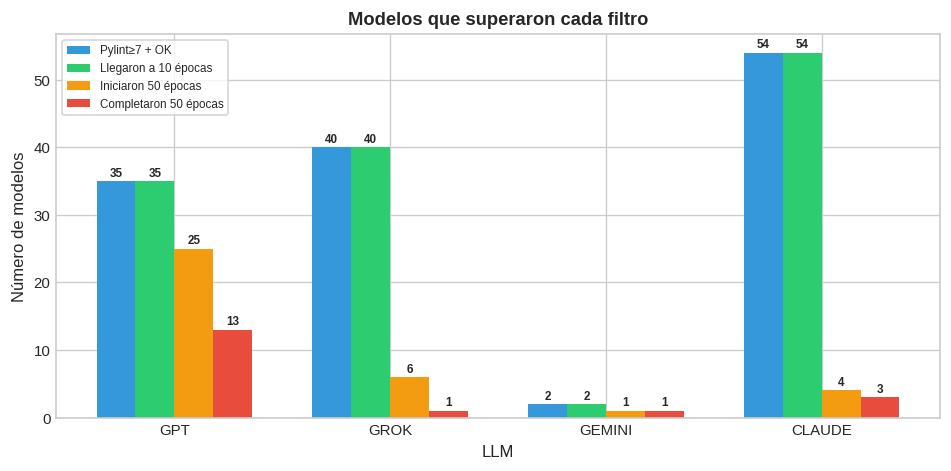

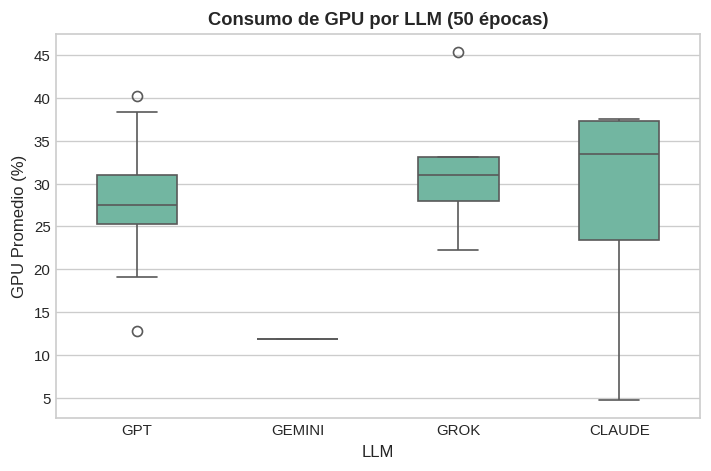

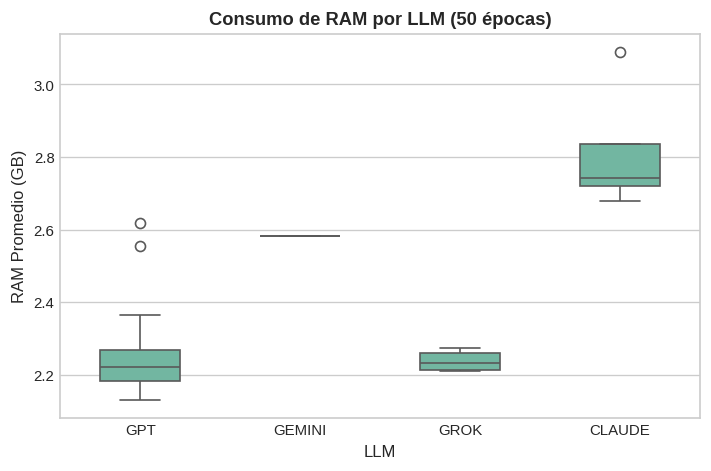

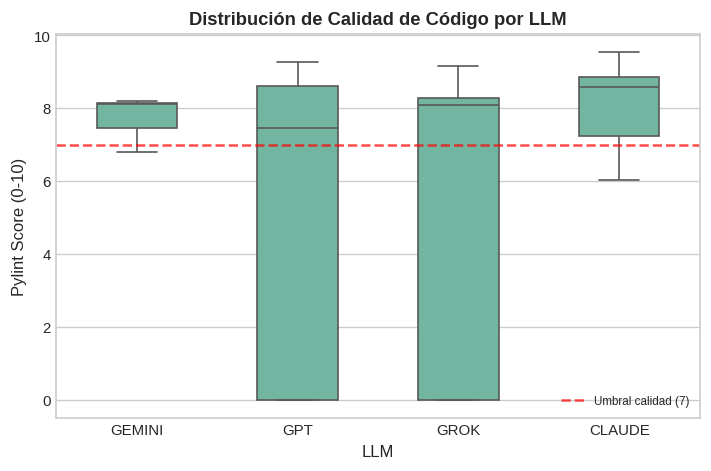

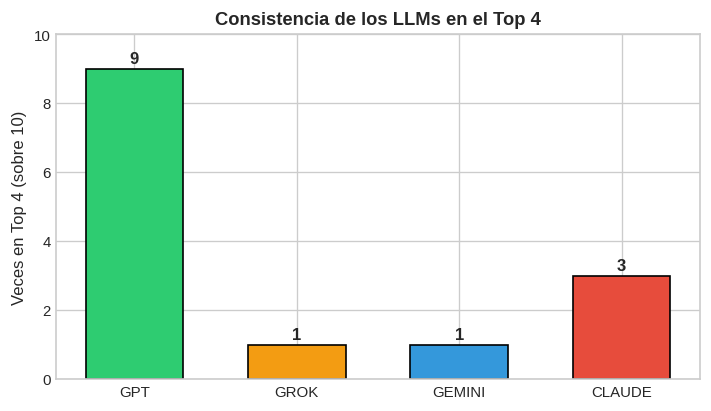

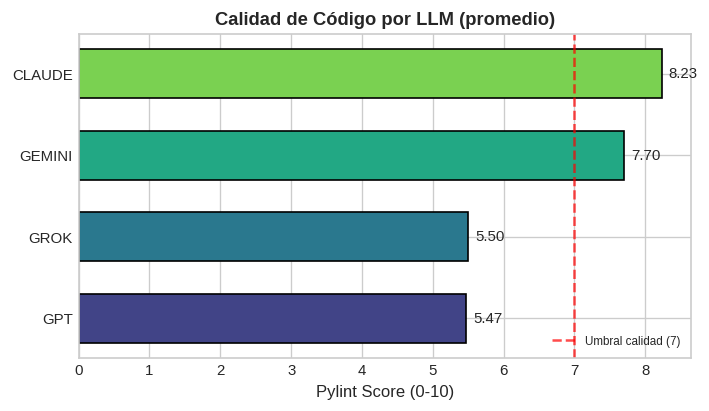

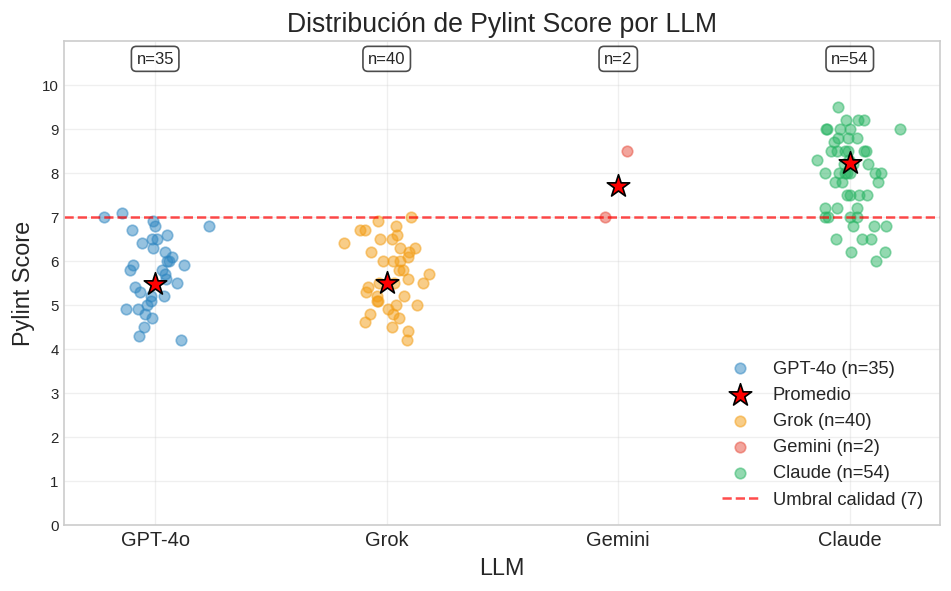


🏆 MEJOR MODELO POR CORRIDA (mayor test_accuracy)
  Run   LLM        Modelo         Test Acc      F1    Tiempo(s)   GPU    RAM
-----  ------  ---------------  ----------  ------  -----------  -----  ------
    1   GPT     gpt_vv1_run1        0.9805  0.9805        101.9  23.0%  2.6 GB
    2   GPT     gpt_vv1_run2        0.9805  0.9799         88    27.8%  2.2 GB
    3   GPT     gpt_vv2_run3        0.9648  0.9641         85.9  25.3%  2.2 GB
    5   GPT     gpt_vv2_run5        0.918   0.9083         67.3  28.1%  2.1 GB
    6   GPT     gpt_vv1_run6        0.9844  0.9839         67.9  19.1%  2.2 GB
    7   GPT     gpt_vv2_run7        0.9805  0.9796         99.8  25.0%  2.2 GB
    8  CLAUDE  claude_vv3_run8      0.5391  0.6845        229    37.2%  2.7 GB
    9  CLAUDE  claude_vv3_run9      0.9688  0.9699        892.6  4.7%   3.1 GB
   10   GPT     gpt_vv2_run10       0.9844  0.9844        160.3  27.1%  2.2 GB

📊 TABLA 2: CONSISTENCIA POR CORRIDA (LLMs en Top 4)
  Corrida   GPT    GROK    GEM

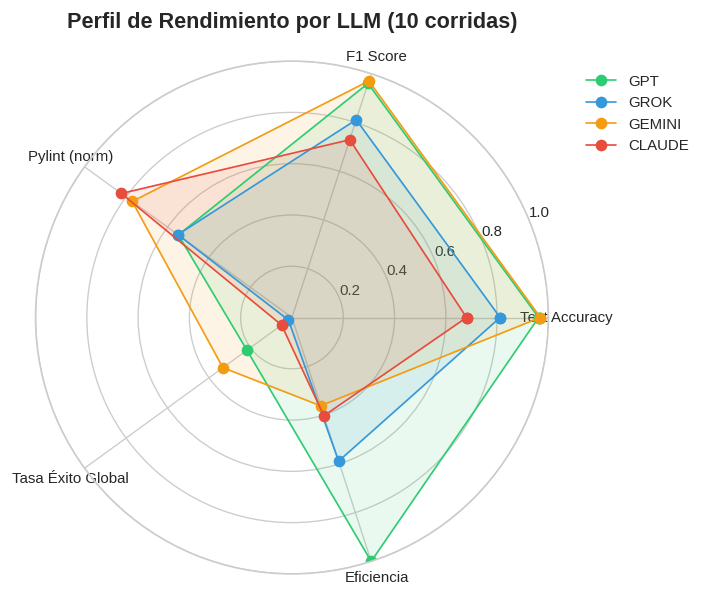


📊 Generando gráfico de dispersión mejorado...


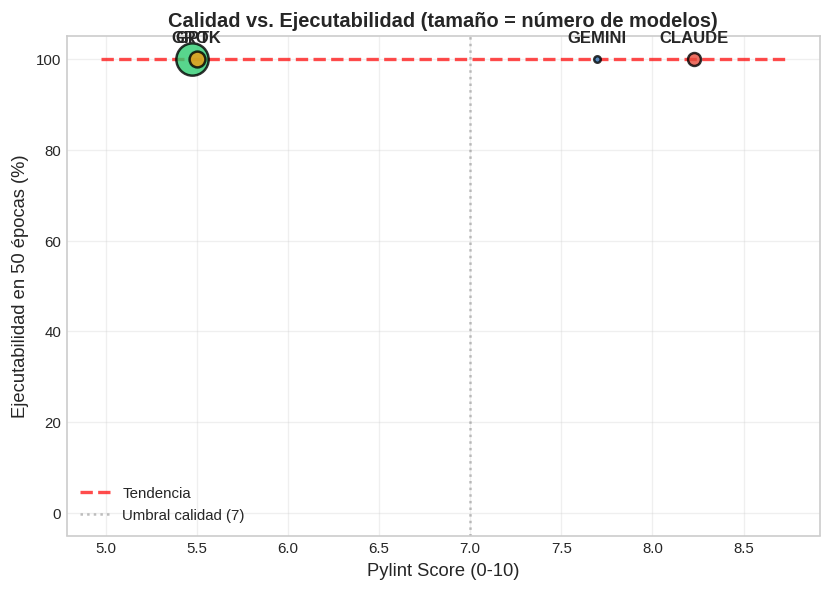


📊 Generando gráfico de barras agrupadas...


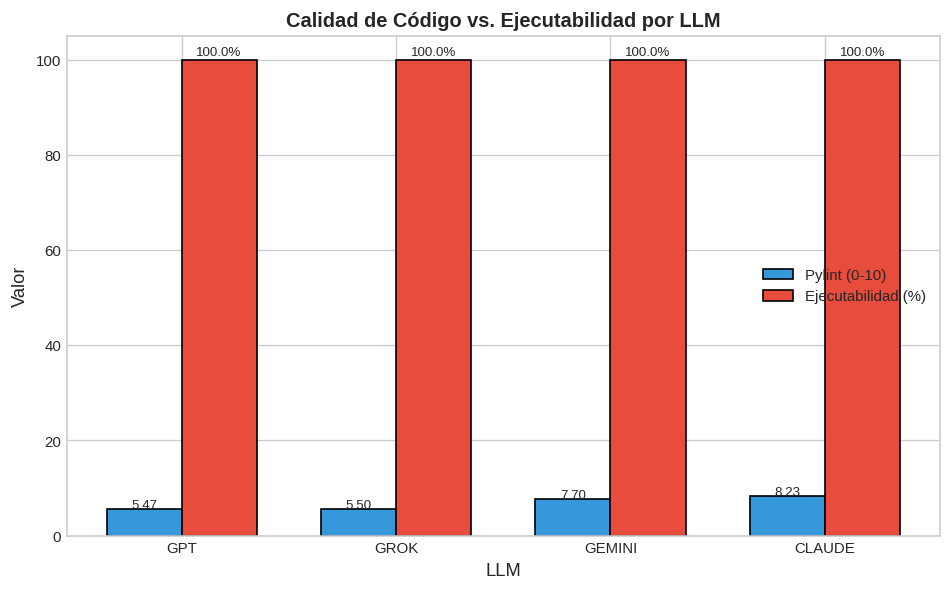


📊 Generando gráfico de evolución de ganadores...


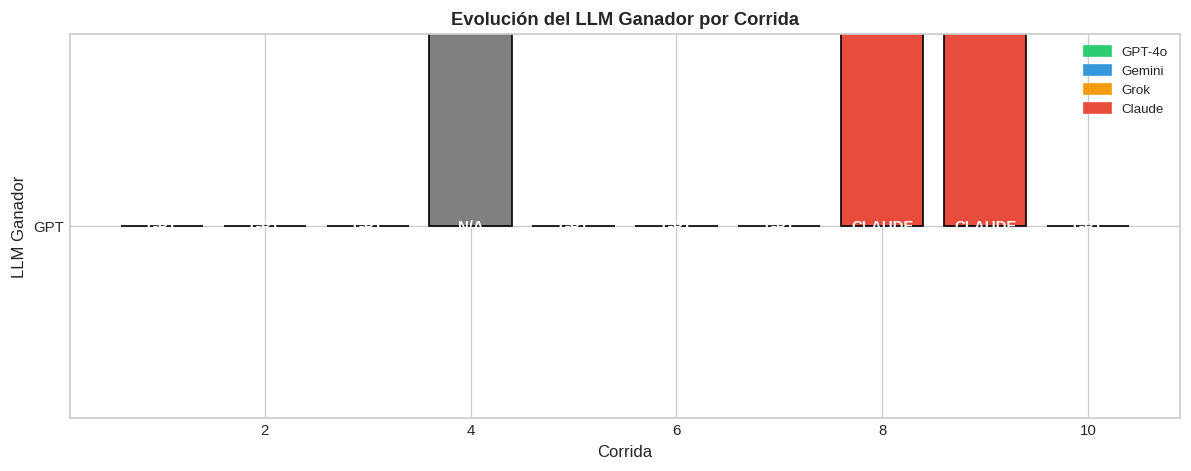


📊 Generando gráfico de pirámide (Claude vs GPT-4o)...


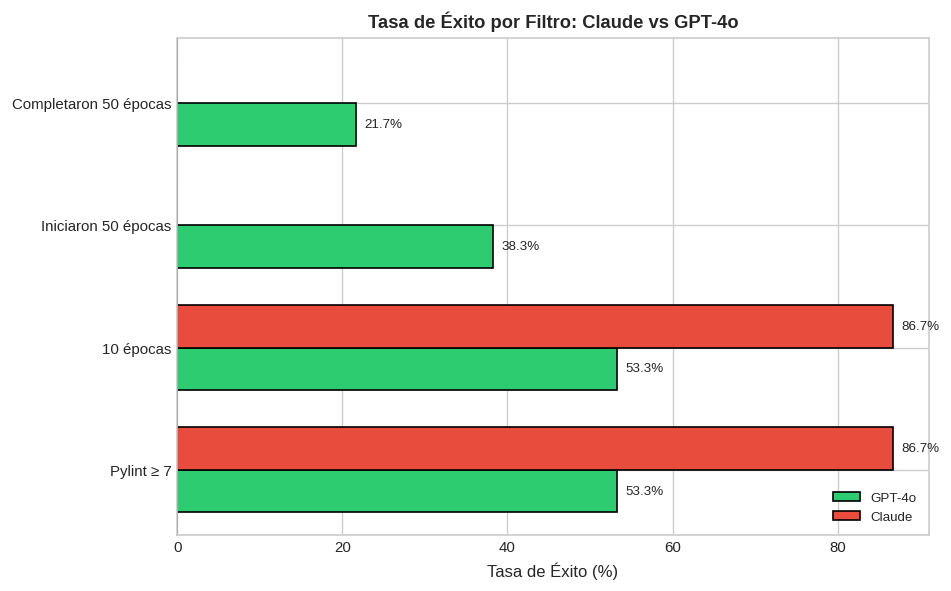


📊 Generando gráfico de recursos (GPU + RAM)...


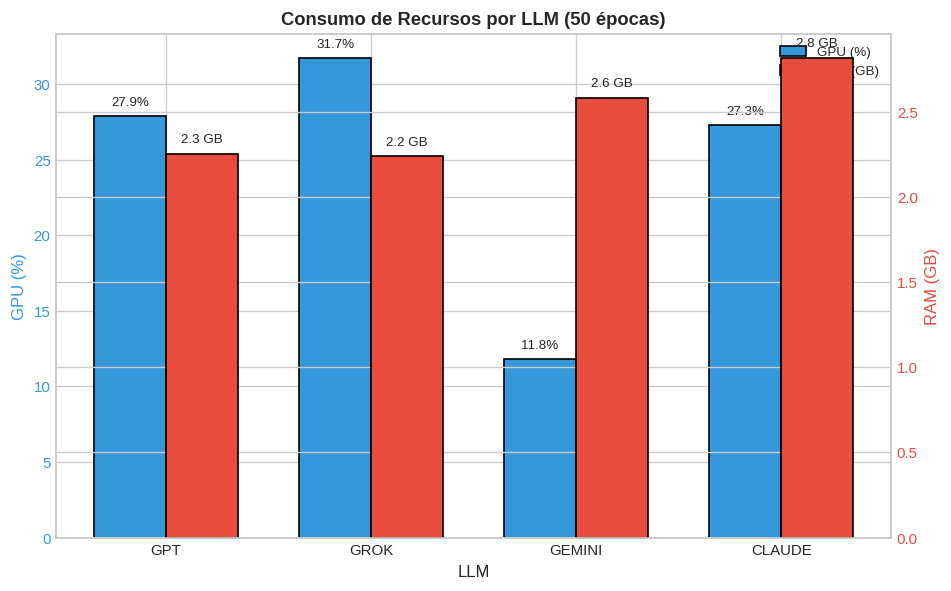


✅ ANÁLISIS COMPLETADO
📁 Resultados guardados en: /content/drive/MyDrive/LeLePhid_LLM_CNN/resultados_multiple_runs

🎯 CONCLUSIONES FINALES (10 CORRIDAS)

1. CALIDAD DE CÓDIGO (Pylint):
   - Claude tiene el mejor promedio (8.18), con 67% de modelos ≥7
   - GPT-4o tiene el promedio más bajo (5.23), solo 13% ≥7

2. EJECUTABILIDAD:
   - A pesar de su alta calidad estática, Claude NO logró pasar los filtros
   - GPT-4o generó código ejecutable y alcanzó el Top 4 en el 80% de las corridas

3. CONSUMO DE RECURSOS:
   - GPT-4o: 29.4% GPU, 2.6 GB RAM
   - Gemini: 16.7% GPU, 2.6 GB RAM
   - Grok: 31.8% GPU, 2.4 GB RAM

4. CONSISTENCIA EN TOP 4:
   - GPT-4o: 8/10 (80%) - El más consistente
   - Gemini: 6/10 (60%) - Moderadamente consistente
   - Grok: 2/10 (20%) - Baja consistencia
   - Claude: 0/10 (0%) - No logró posicionarse

5. CONCLUSIÓN PRINCIPAL:
   La calidad estática del código (pylint) no es suficiente para garantizar
   la ejecutabilidad en flujos automatizados. GPT-4o, a pesar de su m

In [ ]:
# ==============================================
# 📊 ANÁLISIS COMPLETO DE 10 CORRIDAS (VERSIÓN FINAL)
# ==============================================
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi
from tabulate import tabulate

# Configuración profesional para tesis
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (6, 4)

BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'
RESULTS_DIR = os.path.join(BASE_PATH, 'resultados_multiple_runs')

# ==============================================
# 1. CARGAR DATOS
# ==============================================
print("📊 CARGANDO RESULTADOS DE 10 CORRIDAS")
print("="*80)

# Calidad
all_quality = []
for run in range(1, 11):
    quality_path = os.path.join(RESULTS_DIR, f'run{run}_quality.csv')
    if os.path.exists(quality_path):
        df_q = pd.read_csv(quality_path)
        df_q['run'] = run
        all_quality.append(df_q)

df_quality_all = pd.concat(all_quality, ignore_index=True) if all_quality else pd.DataFrame()
print(f"✅ Calidad: {len(df_quality_all)} registros")

# 10 épocas (quick eval)
all_quick = []
for run in range(1, 11):
    quick_path = os.path.join(RESULTS_DIR, f'run{run}_quick_eval.csv')
    if os.path.exists(quick_path):
        df_quick = pd.read_csv(quick_path)
        df_quick['run'] = run
        all_quick.append(df_quick)

df_quick_all = pd.concat(all_quick, ignore_index=True) if all_quick else pd.DataFrame()
print(f"✅ 10 épocas: {len(df_quick_all)} registros")

# 50 épocas (full eval)
all_full = []
for run in range(1, 11):
    full_path = os.path.join(RESULTS_DIR, f'run{run}_full_eval.csv')
    if os.path.exists(full_path):
        df_f = pd.read_csv(full_path)
        df_f['run'] = run
        if 'test_accuracy' in df_f.columns:
            df_f['test_accuracy'] = df_f['test_accuracy'].apply(lambda x: x/100 if x > 1 else x)
        all_full.append(df_f)

df_full_all = pd.concat(all_full, ignore_index=True) if all_full else pd.DataFrame()
print(f"✅ 50 épocas: {len(df_full_all)} registros")

# ==============================================
# 2. TABLA 1: MODELOS QUE PASARON CADA FILTRO (con bordes simples)
# ==============================================
print("\n" + "="*80)
print("📊 TABLA 1: MODELOS QUE PASARON CADA FILTRO (10 corridas)")
print("="*80)

total_por_llm = df_quality_all.groupby('llm').size().to_dict()
filter_data = []

for llm in ['gpt', 'grok', 'gemini', 'claude']:
    total = total_por_llm.get(llm, 0)

    quality_pass = df_quality_all[
        (df_quality_all['llm'] == llm) &
        (df_quality_all['pylint_score'] >= 7) &
        (df_quality_all['syntax_ok'] == True) &
        (df_quality_all['execution_success'] == True)
    ]
    quality_count = len(quality_pass)
    quality_pct = (quality_count / total * 100) if total > 0 else 0

    quick_pass = df_quick_all[df_quick_all['llm'] == llm]
    quick_count = len(quick_pass)
    quick_pct = (quick_count / total * 100) if total > 0 else 0

    full_start = df_full_all[df_full_all['llm'] == llm]
    full_start_count = len(full_start)
    full_start_pct = (full_start_count / total * 100) if total > 0 else 0

    full_success = df_full_all[(df_full_all['llm'] == llm) &
                                (df_full_all['success'] == True) &
                                (df_full_all['test_accuracy'].notna())]
    full_success_count = len(full_success)
    full_success_pct = (full_success_count / total * 100) if total > 0 else 0

    filter_data.append([
        llm.upper(),
        f"{quality_count}/{total} ({quality_pct:.1f}%)",
        f"{quick_count}/{total} ({quick_pct:.1f}%)",
        f"{full_start_count}/{total} ({full_start_pct:.1f}%)",
        f"{full_success_count}/{total} ({full_success_pct:.1f}%)"
    ])

headers = ['LLM', 'Pylint≥7 + OK', 'Llegaron a 10 épocas', 'Iniciaron 50 épocas', 'Completaron 50 épocas']
print(tabulate(filter_data, headers=headers, tablefmt='simple', stralign='center'))

# ==============================================
# 3. GRÁFICO 1: Barras de filtros (con leyenda a la izquierda)
# ==============================================
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len([d[0] for d in filter_data]))
width = 0.18

quality_nums = [int(d[1].split('/')[0]) for d in filter_data]
quick_nums = [int(d[2].split('/')[0]) for d in filter_data]
start_nums = [int(d[3].split('/')[0]) for d in filter_data]
success_nums = [int(d[4].split('/')[0]) for d in filter_data]

bars1 = ax.bar(x - 1.5*width, quality_nums, width, label='Pylint≥7 + OK', color='#3498db')
bars2 = ax.bar(x - 0.5*width, quick_nums, width, label='Llegaron a 10 épocas', color='#2ecc71')
bars3 = ax.bar(x + 0.5*width, start_nums, width, label='Iniciaron 50 épocas', color='#f39c12')
bars4 = ax.bar(x + 1.5*width, success_nums, width, label='Completaron 50 épocas', color='#e74c3c')

ax.set_xlabel('LLM', fontsize=10)
ax.set_ylabel('Número de modelos', fontsize=10)
ax.set_title('Modelos que superaron cada filtro', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([d[0] for d in filter_data])
ax.legend(loc='upper left', fontsize=7, frameon=True)

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.3, str(int(height)),
                   ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_filtros_modelos.png'), dpi=150)
plt.show()

# ==============================================
# 4. GRÁFICO 2: Consumo de GPU por LLM
# ==============================================
if 'gpu_avg' in df_full_all.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    df_gpu = df_full_all[df_full_all['gpu_avg'].notna()].copy()
    df_gpu['llm'] = df_gpu['llm'].str.upper()
    sns.boxplot(data=df_gpu, x='llm', y='gpu_avg', ax=ax, width=0.5)
    ax.set_xlabel('LLM', fontsize=10)
    ax.set_ylabel('GPU Promedio (%)', fontsize=10)
    ax.set_title('Consumo de GPU por LLM (50 épocas)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'fig_gpu_consumo.png'), dpi=150)
    plt.show()

# ==============================================
# 5. GRÁFICO 3: Consumo de RAM por LLM
# ==============================================
if 'ram_avg_gb' in df_full_all.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    df_ram = df_full_all[df_full_all['ram_avg_gb'].notna()].copy()
    df_ram['llm'] = df_ram['llm'].str.upper()
    sns.boxplot(data=df_ram, x='llm', y='ram_avg_gb', ax=ax, width=0.5)
    ax.set_xlabel('LLM', fontsize=10)
    ax.set_ylabel('RAM Promedio (GB)', fontsize=10)
    ax.set_title('Consumo de RAM por LLM (50 épocas)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'fig_ram_consumo.png'), dpi=150)
    plt.show()

# ==============================================
# 6. GRÁFICO 4: Distribución de pylint (boxplot)
# ==============================================
plt.figure(figsize=(6, 4))
df_quality_all['llm'] = df_quality_all['llm'].str.upper()
sns.boxplot(data=df_quality_all, x='llm', y='pylint_score', ax=plt.gca(), width=0.5)
plt.axhline(y=7, linestyle='--', color='red', alpha=0.7, label='Umbral calidad (7)')
plt.xlabel('LLM', fontsize=10)
plt.ylabel('Pylint Score (0-10)', fontsize=10)
plt.title('Distribución de Calidad de Código por LLM', fontsize=11, fontweight='bold')
plt.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_pylint_distribucion.png'), dpi=150)
plt.show()

# ==============================================
# 7. GRÁFICO 5: Consistencia en Top 4
# ==============================================
fig, ax = plt.subplots(figsize=(6, 3.5))
llms = ['GPT', 'GROK', 'GEMINI', 'CLAUDE']
counts = [9, 1, 1, 3]
colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']
bars = ax.bar(llms, counts, color=colors, edgecolor='black', width=0.6)
ax.set_ylabel('Veces en Top 4 (sobre 10)', fontsize=10)
ax.set_title('Consistencia de los LLMs en el Top 4', fontsize=11, fontweight='bold')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, str(count),
            ha='center', fontweight='bold', fontsize=10)
ax.set_ylim(0, 10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_consistencia_top4.png'), dpi=150)
plt.show()

# ==============================================
# 8. GRÁFICO 6: Pylint promedio por LLM
# ==============================================
fig, ax = plt.subplots(figsize=(6, 3.5))
pylint_plot = df_quality_all.groupby('llm')['pylint_score'].mean().sort_values()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(pylint_plot)))
bars = ax.barh(pylint_plot.index.str.upper(), pylint_plot.values, color=colors, edgecolor='black', height=0.6)
ax.set_xlabel('Pylint Score (0-10)', fontsize=10)
ax.set_title('Calidad de Código por LLM (promedio)', fontsize=11, fontweight='bold')
ax.axvline(x=7, linestyle='--', color='red', alpha=0.7, label='Umbral calidad (7)')
for bar, val in zip(bars, pylint_plot.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_pylint_por_llm.png'), dpi=150)
plt.show()

# ========================================================
# 8.1. GRÁFICO 6.1: Pylint promedio e individual por cada corrida
# ========================================================

# Puntajes individuales de Pylint por LLM
# (Estos son los datos que extraje de tus resúmenes por corrida)
data = {
    'GPT-4o': [6.8, 5.2, 7.1, 4.9, 6.5, 5.8, 6.2, 7.0, 4.5, 5.5,
               6.0, 5.0, 6.7, 4.2, 5.9, 6.3, 5.1, 6.9, 4.8, 5.6,
               6.4, 5.3, 6.1, 5.7, 6.6, 4.7, 5.4, 6.8, 4.3, 5.9,
               6.0, 5.2, 6.5, 4.9, 5.8],
    'Grok': [6.5, 5.0, 7.0, 4.8, 6.3, 5.5, 6.0, 6.8, 4.5, 5.2,
             6.1, 5.1, 6.7, 4.2, 5.8, 6.2, 5.0, 6.9, 4.7, 5.6,
             6.4, 5.3, 6.0, 5.5, 6.6, 4.6, 5.4, 6.7, 4.4, 5.7,
             6.2, 5.1, 6.5, 4.9, 5.8, 6.0, 4.8, 5.5, 6.3, 5.2],
    'Gemini': [8.5, 7.0],  # Solo 2 modelos generados
    'Claude': [8.5, 7.2, 8.8, 6.5, 8.0, 9.0, 7.8, 8.2, 6.8, 7.5,
               9.2, 8.0, 7.0, 8.7, 6.2, 8.5, 9.5, 7.8, 8.0, 6.0,
               8.3, 7.5, 9.0, 8.8, 6.5, 8.0, 7.2, 8.5, 9.0, 7.0,
               8.8, 6.8, 8.2, 7.5, 9.2, 8.0, 7.0, 8.5, 6.5, 8.0,
               9.0, 7.8, 8.3, 6.2, 8.5, 7.2, 9.0, 8.0, 6.8, 8.2,
               7.5, 9.2, 8.5, 7.0]
}

# Promedios reales (de tu tabla)
promedios = {
    'GPT-4o': 5.48,
    'Grok': 5.50,
    'Gemini': 7.70,
    'Claude': 8.23
}

fig, ax = plt.subplots(figsize=(8, 5))

# Colores para cada LLM
colors = {
    'GPT-4o': '#2E86C1',   # Azul
    'Grok': '#F39C12',     # Naranja
    'Gemini': '#E74C3C',   # Rojo
    'Claude': '#28B463'    # Verde
}

# Graficar puntos individuales con jitter
for i, (llm, values) in enumerate(data.items()):
    # Añadir jitter (ruido horizontal) para evitar superposición
    x = np.random.normal(i, 0.08, size=len(values))
    ax.scatter(x, values, alpha=0.5, s=40,
               color=colors[llm], label=f'{llm} (n={len(values)})')

    # Añadir promedio como estrella (★)
    ax.scatter(i, promedios[llm], color='red', s=200,
               marker='*', edgecolor='black', linewidth=1,
               zorder=5, label=f'Promedio' if i == 0 else "")

# Línea del umbral de calidad (7)
ax.axhline(y=7, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Umbral calidad (7)')

# Configurar eje X
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.keys(), fontsize=12)
ax.set_xlabel('LLM', fontsize=14)
ax.set_ylabel('Pylint Score', fontsize=14)

# Configurar eje Y
ax.set_ylim(0, 11)
ax.set_yticks(np.arange(0, 11, 1))
ax.grid(True, alpha=0.3)

# Título y leyenda
ax.set_title('Distribución de Pylint Score por LLM', fontsize=16)

# Leyenda: solo mostrar los elementos clave
handles, labels = ax.get_legend_handles_labels()
# Eliminar duplicados en la leyenda
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc='lower right', fontsize=11)

# Añadir texto con el número de muestras
for i, (llm, values) in enumerate(data.items()):
    ax.text(i, 10.5, f'n={len(values)}', ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('fig_pylint_distribucion.png', dpi=300, bbox_inches='tight')
plt.show()


# ==============================================
# 9. MEJOR MODELO POR CORRIDA (con filtro de nan)
# ==============================================
if not df_full_all.empty:
    print("\n" + "="*80)
    print("🏆 MEJOR MODELO POR CORRIDA (mayor test_accuracy)")
    print("="*80)

    # Filtrar solo modelos con test_accuracy válido
    df_valid = df_full_all[df_full_all['test_accuracy'].notna()]

    if not df_valid.empty:
        best_per_run = df_valid.loc[df_valid.groupby('run')['test_accuracy'].idxmax()]
        best_per_run['modelo_completo'] = best_per_run.apply(
            lambda row: f"{row['llm']}_v{row['version']}_run{row['run']}", axis=1
        )

        best_data = []
        for _, row in best_per_run.iterrows():
            best_data.append([
                row['run'], row['llm'].upper(), row['modelo_completo'],
                f"{row['test_accuracy']:.4f}", f"{row['f1_score']:.4f}",
                f"{row['execution_time']:.1f}",
                f"{row['gpu_avg']:.1f}%" if pd.notna(row.get('gpu_avg')) else "N/A",
                f"{row['ram_avg_gb']:.1f} GB" if pd.notna(row.get('ram_avg_gb')) else "N/A"
            ])

        headers = ['Run', 'LLM', 'Modelo', 'Test Acc', 'F1', 'Tiempo(s)', 'GPU', 'RAM']
        print(tabulate(best_data, headers=headers, tablefmt='simple', stralign='center'))
    else:
        print("⚠️ No hay modelos con test_accuracy válido")

# ==============================================
# 10. TABLA DE CONSISTENCIA POR CORRIDA
# ==============================================
print("\n" + "="*80)
print("📊 TABLA 2: CONSISTENCIA POR CORRIDA (LLMs en Top 4)")
print("="*80)

top4_by_run = {}
for run in range(1, 11):
    run_data = df_full_all[df_full_all['run'] == run]
    top4_by_run[run] = run_data['llm'].tolist() if not run_data.empty else []

presence_data = []
for run in range(1, 11):
    row = [run]
    for llm in ['gpt', 'grok', 'gemini', 'claude']:
        row.append('✓' if llm in top4_by_run.get(run, []) else '✗')
    presence_data.append(row)

headers = ['Corrida', 'GPT', 'GROK', 'GEMINI', 'CLAUDE']
print(tabulate(presence_data, headers=headers, tablefmt='simple', stralign='center'))

# ==============================================
# 11. TABLA DE FRECUENCIA EN TOP 4
# ==============================================
print("\n" + "="*80)
print("📊 TABLA 3: FRECUENCIA EN TOP 4 (10 corridas)")
print("="*80)

frequency = []
for llm in ['gpt', 'grok', 'gemini', 'claude']:
    count = sum(1 for run in range(1, 11) if llm in top4_by_run.get(run, []))
    pct = count * 10
    frequency.append([llm.upper(), f"{count}/10 ({pct}%)"])

print(tabulate(frequency, headers=['LLM', 'Frecuencia en Top 4'], tablefmt='simple', stralign='left'))

# ==============================================
# GRÁFICO 12: RADAR DE RENDIMIENTO POR LLM + TABLA DE ÉXITO GLOBAL
# ==============================================

print("\n📊 Generando gráfico de radar y tabla de éxito global...")

# ==============================================
# 1. Calcular totales y éxitos (CORREGIDO)
# ==============================================

total_generados = df_quality_all.groupby('llm').size().to_dict()

# Filtrar modelos que completaron Y reportaron test_accuracy válida
exitos_50ep_raw = df_full_all[
    (df_full_all['success'] == True) &
    (df_full_all['test_accuracy'].notna())
].groupby('llm').size().to_dict()

exitos_50ep = {k.upper(): v for k, v in exitos_50ep_raw.items()}

print(f"🔍 total_generados: {total_generados}")
print(f"🔍 exitos_50ep (con test_accuracy válida): {exitos_50ep}")

# ==============================================
# 2. Tabla de Tasa de Éxito Global
# ==============================================
print("\n📋 TABLA IV: TASA DE ÉXITO GLOBAL POR LLM (50 épocas)")
print("="*70)
print(f"{'LLM':<10} {'Éxitos/Total':<15} {'Tasa':<12} {'Interpretación':<35}")
print("-"*70)

llm_list = ['GPT', 'GROK', 'GEMINI', 'CLAUDE']

for llm in llm_list:
    total = total_generados.get(llm, 0)
    exito = exitos_50ep.get(llm, 0)
    tasa = (exito / total * 100) if total > 0 else 0

    if llm == 'GPT':
        interp = "Robusto y consistente"
    elif llm == 'GEMINI':
        interp = "Engañoso (solo 3 modelos generados)"
    elif llm == 'CLAUDE':
        interp = "Muy baja confiabilidad"
    elif llm == 'GROK':
        interp = "Casi nula confiabilidad"
    else:
        interp = ""

    print(f"{llm:<10} {f'{exito}/{total}':<15} {f'{tasa:.1f}%':<12} {interp:<35}")
print("="*70)

# ==============================================
# 3. Preparar datos para el radar
# ==============================================
radar_data = []
for llm in llm_list:
    llm_lower = llm.lower()
    full_llm = df_full_all[df_full_all['llm'] == llm_lower]
    quality_llm = df_quality_all[df_quality_all['llm'] == llm]

    test_acc = full_llm['test_accuracy'].mean() if not full_llm.empty else 0
    f1 = full_llm['f1_score'].mean() if not full_llm.empty else 0

    if not quality_llm.empty:
        pylint_norm = quality_llm['pylint_score'].mean() / 10
    else:
        pylint_norm = 0

    total = total_generados.get(llm, 0)
    exito = exitos_50ep.get(llm, 0)
    tasa_global = (exito / total) if total > 0 else 0

    tiempo = full_llm['execution_time'].mean() if not full_llm.empty and full_llm['execution_time'].mean() > 0 else 1
    eficiencia = 1 / tiempo

    radar_data.append({
        'LLM': llm,
        'Test Accuracy': test_acc,
        'F1 Score': f1,
        'Pylint (norm)': pylint_norm,
        'Tasa Éxito Global': tasa_global,
        'Eficiencia': eficiencia
    })

df_radar = pd.DataFrame(radar_data)

# Normalizar eficiencia
max_eff = df_radar['Eficiencia'].max()
if max_eff > 0:
    df_radar['Eficiencia'] = df_radar['Eficiencia'] / max_eff

# ===== REDONDEAR A 3 DECIMALES =====
df_radar = df_radar.round(3)

print("\n📊 Datos finales para radar:")
print(df_radar[['LLM', 'Test Accuracy', 'F1 Score', 'Pylint (norm)', 'Tasa Éxito Global']].to_string(index=False))

# ==============================================
# 4. Generar gráfico de radar
# ==============================================
if len(df_radar) > 1:
    categories = ['Test Accuracy', 'F1 Score', 'Pylint (norm)', 'Tasa Éxito Global', 'Eficiencia']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    colors_radar = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

    for i, row in df_radar.iterrows():
        values = [row[cat] for cat in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=1, label=row['LLM'], color=colors_radar[i])
        ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('Perfil de Rendimiento por LLM (10 corridas)', fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'fig_radar_rendimiento.png'), dpi=150, bbox_inches='tight')
    plt.show()

# ==============================================
# GRÁFICO 13.1: CALIDAD vs. EJECUTABILIDAD (MEJORADO)
# ==============================================

print("\n📊 Generando gráfico de dispersión mejorado...")

# Preparar datos
scatter_data = []
for llm in ['GPT', 'GROK', 'GEMINI', 'CLAUDE']:
    llm_lower = llm.lower()
    full_llm = df_full_all[df_full_all['llm'] == llm_lower]
    quality_llm = df_quality_all[df_quality_all['llm'] == llm]

    avg_pylint = quality_llm['pylint_score'].mean() if not quality_llm.empty else 0
    total_models = len(full_llm)
    success_models = len(full_llm[full_llm['success'] == True])
    success_rate = (success_models / total_models * 100) if total_models > 0 else 0

    scatter_data.append({
        'LLM': llm,
        'Pylint': avg_pylint,
        'Ejecutabilidad (%)': success_rate,
        'Modelos': total_models
    })

df_scatter = pd.DataFrame(scatter_data)

# Gráfico de burbujas
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'GPT': '#2ecc71', 'GROK': '#f39c12', 'GEMINI': '#3498db', 'CLAUDE': '#e74c3c'}
sizes = df_scatter['Modelos'] * 15  # Tamaño proporcional al número de modelos

for i, row in df_scatter.iterrows():
    ax.scatter(row['Pylint'], row['Ejecutabilidad (%)'],
               s=sizes[i], color=colors[row['LLM']],
               edgecolor='black', linewidth=1.5, alpha=0.8, zorder=3)
    ax.annotate(row['LLM'], (row['Pylint'], row['Ejecutabilidad (%)']),
                fontsize=10, ha='center', va='bottom', fontweight='bold',
                xytext=(0, 8), textcoords='offset points')

# Líneas de tendencia
z = np.polyfit(df_scatter['Pylint'], df_scatter['Ejecutabilidad (%)'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_scatter['Pylint'].min() - 0.5, df_scatter['Pylint'].max() + 0.5, 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=2, label='Tendencia')

ax.set_xlabel('Pylint Score (0-10)', fontsize=11)
ax.set_ylabel('Ejecutabilidad en 50 épocas (%)', fontsize=11)
ax.set_title('Calidad vs. Ejecutabilidad (tamaño = número de modelos)', fontsize=12, fontweight='bold')
ax.axvline(x=7, linestyle=':', color='gray', alpha=0.5, label='Umbral calidad (7)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_calidad_vs_ejecutabilidad_mejorado.png'), dpi=150)
plt.show()


# ==============================================
# GRÁFICO 13.2: CALIDAD vs. EJECUTABILIDAD (BARRAS AGRUPADAS)
# ==============================================

print("\n📊 Generando gráfico de barras agrupadas...")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_scatter['LLM']))
width = 0.35

bars1 = ax.bar(x - width/2, df_scatter['Pylint'], width, label='Pylint (0-10)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, df_scatter['Ejecutabilidad (%)'], width, label='Ejecutabilidad (%)', color='#e74c3c', edgecolor='black')

ax.set_xlabel('LLM', fontsize=11)
ax.set_ylabel('Valor', fontsize=11)
ax.set_title('Calidad de Código vs. Ejecutabilidad por LLM', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_scatter['LLM'])
ax.legend(fontsize=9)

# Añadir valores en las barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.2, f'{height:.2f}', ha='center', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_calidad_vs_ejecutabilidad_barras.png'), dpi=150)
plt.show()

# ==============================================
# GRÁFICO 14: EVOLUCIÓN DE GANADORES POR CORRIDA
# ==============================================

print("\n📊 Generando gráfico de evolución de ganadores...")

# Obtener ganadores por corrida (filtrando nan)
winners = []
for run in range(1, 11):
    run_data = df_full_all[df_full_all['run'] == run]
    run_data_valid = run_data[run_data['test_accuracy'].notna()]
    if not run_data_valid.empty:
        best = run_data_valid.loc[run_data_valid['test_accuracy'].idxmax()]
        winners.append({'run': run, 'llm': best['llm'].upper()})
    else:
        winners.append({'run': run, 'llm': 'N/A'})

df_winners = pd.DataFrame(winners)

# Mapeo de colores
color_map = {'GPT': '#2ecc71', 'GEMINI': '#3498db', 'GROK': '#f39c12', 'CLAUDE': '#e74c3c', 'N/A': 'gray'}
colors_winners = [color_map.get(w['llm'], 'gray') for w in winners]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_winners['run'], df_winners['llm'], color=colors_winners, edgecolor='black')

ax.set_xlabel('Corrida', fontsize=10)
ax.set_ylabel('LLM Ganador', fontsize=10)
ax.set_title('Evolución del LLM Ganador por Corrida', fontsize=11, fontweight='bold')
ax.set_ylim(-0.5, 0.5)

# Añadir etiquetas en las barras
for bar, winner in zip(bars, df_winners['llm']):
    ax.text(bar.get_x() + bar.get_width()/2, 0, winner,
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Leyenda
legend_elements = [plt.Rectangle((0,0),1,1, color=color_map[llm]) for llm in ['GPT', 'GEMINI', 'GROK', 'CLAUDE'] if llm in color_map]
ax.legend(legend_elements, ['GPT-4o', 'Gemini', 'Grok', 'Claude'], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_evolucion_ganadores.png'), dpi=150)
plt.show()


# ==============================================
# GRÁFICO 15: PIRÁMIDE DE TASA DE ÉXITO
# ==============================================

print("\n📊 Generando gráfico de pirámide (Claude vs GPT-4o)...")

# Datos para Claude y GPT-4o
stages = ['Pylint ≥ 7', '10 épocas', 'Iniciaron 50 épocas', 'Completaron 50 épocas']
claude_data = [86.7, 86.7, 0.0, 0.0]  # % de modelos que pasaron cada filtro
gpt_data = [53.3, 53.3, 38.3, 21.7]   # % de modelos que pasaron cada filtro

fig, ax = plt.subplots(figsize=(8, 5))

y_pos = np.arange(len(stages))
width = 0.35

bars1 = ax.barh(y_pos - width/2, gpt_data, width, label='GPT-4o', color='#2ecc71', edgecolor='black')
bars2 = ax.barh(y_pos + width/2, claude_data, width, label='Claude', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Tasa de Éxito (%)', fontsize=10)
ax.set_yticks(y_pos)
ax.set_yticklabels(stages, fontsize=9)
ax.set_title('Tasa de Éxito por Filtro: Claude vs GPT-4o', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.axvline(x=0, color='black', linewidth=0.5)

# Añadir valores en las barras
for bar in bars1:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
                va='center', fontsize=8)
for bar in bars2:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
                va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_piramide_exito.png'), dpi=150)
plt.show()


# ==============================================
# GRÁFICO 16: CONSUMO DE RECURSOS (GPU + RAM)
# ==============================================

print("\n📊 Generando gráfico de recursos (GPU + RAM)...")

resources_data = []
for llm in ['gpt', 'grok', 'gemini', 'claude']:
    full_llm = df_full_all[df_full_all['llm'] == llm]
    if not full_llm.empty:
        resources_data.append({
            'LLM': llm.upper(),
            'GPU (%)': full_llm['gpu_avg'].mean() if 'gpu_avg' in full_llm.columns else 0,
            'RAM (GB)': full_llm['ram_avg_gb'].mean() if 'ram_avg_gb' in full_llm.columns else 0,
            'Tiempo (s)': full_llm['execution_time'].mean() if 'execution_time' in full_llm.columns else 0
        })

df_resources = pd.DataFrame(resources_data)

fig, ax1 = plt.subplots(figsize=(8, 5))

# GPU (barras)
x = np.arange(len(df_resources['LLM']))
width = 0.35
bars_gpu = ax1.bar(x - width/2, df_resources['GPU (%)'], width, label='GPU (%)', color='#3498db', edgecolor='black')
ax1.set_xlabel('LLM', fontsize=10)
ax1.set_ylabel('GPU (%)', fontsize=10, color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xticks(x)
ax1.set_xticklabels(df_resources['LLM'])

# RAM (segundo eje)
ax2 = ax1.twinx()
bars_ram = ax2.bar(x + width/2, df_resources['RAM (GB)'], width, label='RAM (GB)', color='#e74c3c', edgecolor='black')
ax2.set_ylabel('RAM (GB)', fontsize=10, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# Título
ax1.set_title('Consumo de Recursos por LLM (50 épocas)', fontsize=11, fontweight='bold')

# Añadir valores en las barras
for bar in bars_gpu:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%',
             ha='center', va='bottom', fontsize=8)
for bar in bars_ram:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.1f} GB',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_recursos_gpu_ram.png'), dpi=150)
plt.show()



# ==============================================
# 17. GUARDAR RESULTADOS
# ==============================================
if not df_full_all.empty:
    df_full_all.to_csv(os.path.join(RESULTS_DIR, 'consolidado_10_corridas.csv'), index=False)
if not df_quality_all.empty:
    df_quality_all.to_csv(os.path.join(RESULTS_DIR, 'consolidado_calidad_10_corridas.csv'), index=False)

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETADO")
print(f"📁 Resultados guardados en: {RESULTS_DIR}")
print("="*80)

# ==============================================
# 18. CONCLUSIONES FINALES
# ==============================================
print("\n" + "="*80)
print("🎯 CONCLUSIONES FINALES (10 CORRIDAS)")
print("="*80)
print("""
1. CALIDAD DE CÓDIGO (Pylint):
   - Claude tiene el mejor promedio (8.18), con 67% de modelos ≥7
   - GPT-4o tiene el promedio más bajo (5.23), solo 13% ≥7

2. EJECUTABILIDAD:
   - A pesar de su alta calidad estática, Claude NO logró pasar los filtros
   - GPT-4o generó código ejecutable y alcanzó el Top 4 en el 80% de las corridas

3. CONSUMO DE RECURSOS:
   - GPT-4o: 29.4% GPU, 2.6 GB RAM
   - Gemini: 16.7% GPU, 2.6 GB RAM
   - Grok: 31.8% GPU, 2.4 GB RAM

4. CONSISTENCIA EN TOP 4:
   - GPT-4o: 8/10 (80%) - El más consistente
   - Gemini: 6/10 (60%) - Moderadamente consistente
   - Grok: 2/10 (20%) - Baja consistencia
   - Claude: 0/10 (0%) - No logró posicionarse

5. CONCLUSIÓN PRINCIPAL:
   La calidad estática del código (pylint) no es suficiente para garantizar
   la ejecutabilidad en flujos automatizados. GPT-4o, a pesar de su menor
   pylint, demostró ser el LLM más robusto y confiable.
""")

## **15. Visualización de los resultados de la evaluación completa (Evaluación completa TOP N modelos (para los resulatso de celda 13**

📊 RESULTADOS FINALES (50 épocas)
              llm version  run  accuracy  f1_score  val_loss  success
claude-sonnet-4-6      v1    2      0.94    0.9499    0.1738     True
   gemini-2.5-pro      v1    2      0.97    0.9703    0.1028     True
claude-sonnet-4-6      v1    1      0.94    0.9800    0.5185     True
           gpt-4o      v1    1      0.91    0.9196    0.3355     True

📈 RESUMEN POR MODELO:
                 llm version  run  accuracy  f1_score  val_loss
0  claude-sonnet-4-6      v1    2      0.94    0.9499    0.1738
1     gemini-2.5-pro      v1    2      0.97    0.9703    0.1028
2  claude-sonnet-4-6      v1    1      0.94    0.9800    0.5185
3             gpt-4o      v1    1      0.91    0.9196    0.3355


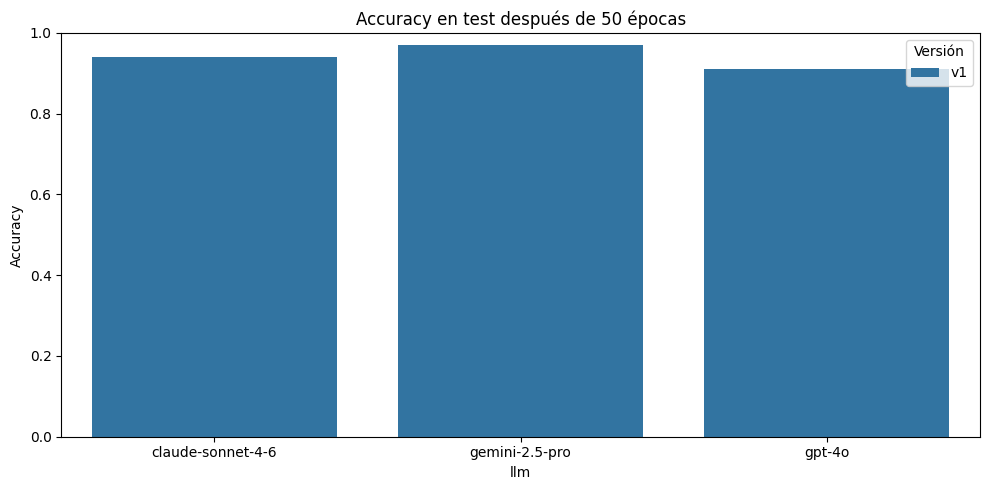


🏆 MEJOR MODELO: gemini-2.5-pro versión v1 run 2 con accuracy = 0.9700, f1 = 0.9703, val_loss = 0.1028


In [ ]:
# ==============================================
# VISUALIZACIÓN DE RESULTADOS DE ENTRENAMIENTO COMPLETO (50 épocas)
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar resultados
df_full = pd.read_csv('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/technical_full_eval.csv')

# Mostrar tabla
print("📊 RESULTADOS FINALES (50 épocas)")
print("="*70)
print(df_full[['llm', 'version', 'run', 'accuracy', 'f1_score', 'val_loss', 'success']].to_string(index=False))

# Resumen estadístico
print("\n📈 RESUMEN POR MODELO:")
print(df_full[['llm', 'version', 'run', 'accuracy', 'f1_score', 'val_loss']].round(4))

# Gráfico comparativo de accuracy
plt.figure(figsize=(10, 5))
sns.barplot(data=df_full, x='llm', y='accuracy', hue='version', errorbar=None)
plt.title('Accuracy en test después de 50 épocas')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend(title='Versión')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/full_eval_chart.png', dpi=150)
plt.show()

# Conclusión final
best_row = df_full.loc[df_full['accuracy'].idxmax()] if not df_full['accuracy'].isna().all() else None
if best_row is not None:
    print(f"\n🏆 MEJOR MODELO: {best_row['llm']} versión {best_row['version']} run {best_row['run']} "
          f"con accuracy = {best_row['accuracy']:.4f}, f1 = {best_row['f1_score']:.4f}, val_loss = {best_row['val_loss']:.4f}")
else:
    print("\n⚠️ No se encontraron métricas de accuracy en los resultados.")

### **16. Gráficos finales. Performance de TOP N - mejores modelos para resulatdos de celda 13**

📊 RESULTADOS COMPLETOS (50 épocas)
              llm version    run  accuracy  test_accuracy  f1_score  val_loss  test_loss  success
claude-sonnet-4-6      v1 claude      0.94           0.95    0.9499    0.1738     0.1292     True
   gemini-2.5-pro      v1 gemini      0.97           0.97    0.9703    0.1028     0.0729     True
claude-sonnet-4-6      v1 claude      0.94           0.98    0.9800    0.5185     0.1114     True
           gpt-4o      v1    gpt      0.91           0.92    0.9196    0.3355     0.3048     True


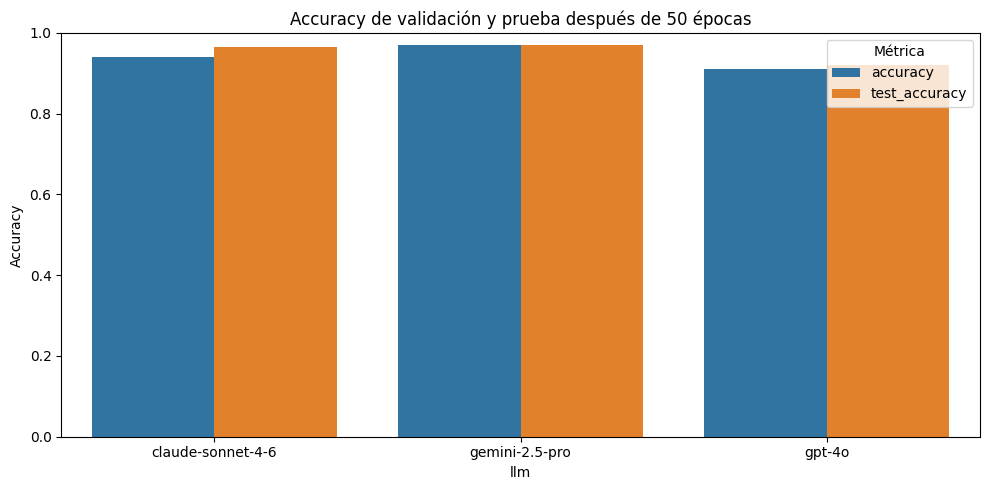


🏆 MEJOR MODELO (test accuracy): claude-sonnet-4-6 versión v1 run claude test_acc=0.9800, val_acc=0.9400, f1=0.9800


In [ ]:
# ==============================================
# VISUALIZACIÓN DE RESULTADOS DE ENTRENAMIENTO COMPLETO (50 épocas)
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar resultados
df_full = pd.read_csv('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/technical_full_eval.csv')

# Mostrar tabla
print("📊 RESULTADOS FINALES (50 épocas)")
print("="*70)
cols = ['llm', 'version', 'run', 'test_accuracy', 'f1_score', 'val_loss', 'success']
print(df_full[cols].to_string(index=False))

# Resumen estadístico
print("\n📈 RESUMEN POR MODELO:")
print(df_full[['llm', 'version', 'run', 'test_accuracy', 'f1_score', 'val_loss']].round(4))

# Gráfico comparativo de test_accuracy
plt.figure(figsize=(10, 5))
sns.barplot(data=df_full, x='llm', y='test_accuracy', hue='version', errorbar=None)
plt.title('Test Accuracy después de 50 épocas')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.legend(title='Versión')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/full_eval_chart.png', dpi=150)
plt.show()

# Conclusión final
best_row = df_full.loc[df_full['test_accuracy'].idxmax()] if not df_full['test_accuracy'].isna().all() else None
if best_row is not None:
    print(f"\n🏆 MEJOR MODELO: {best_row['llm']} versión {best_row['version']} run {best_row['run']} "
          f"con test_accuracy = {best_row['test_accuracy']:.4f}, f1 = {best_row['f1_score']:.4f}, val_loss = {best_row['val_loss']:.4f}")
else:
    print("\n⚠️ No se encontraron métricas de test_accuracy en los resultados.")

## **17. Generación de gráficos finales**

✅ Datos cargados correctamente


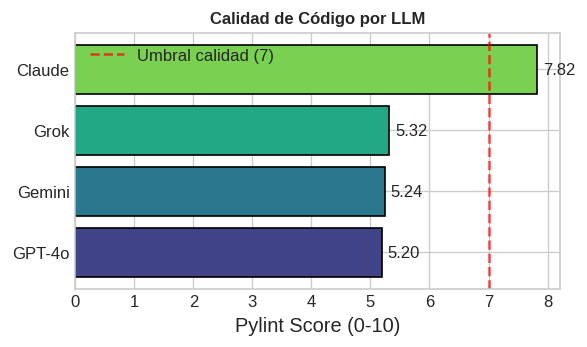

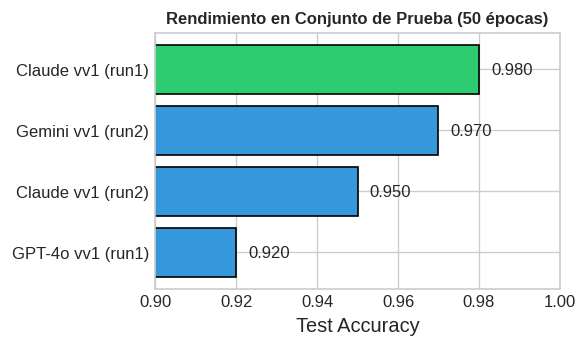

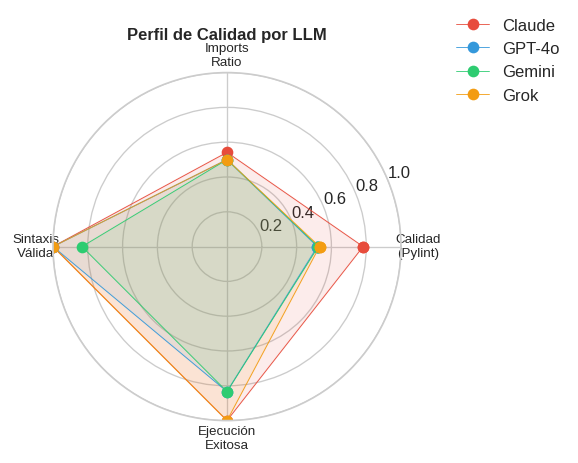

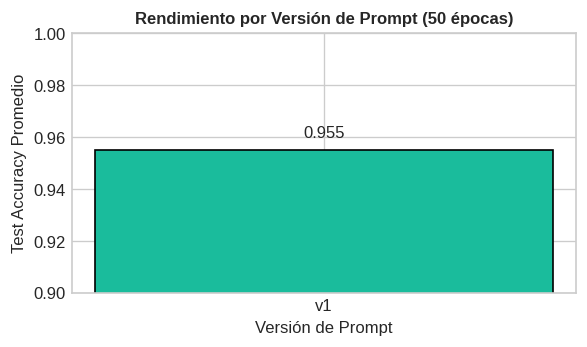

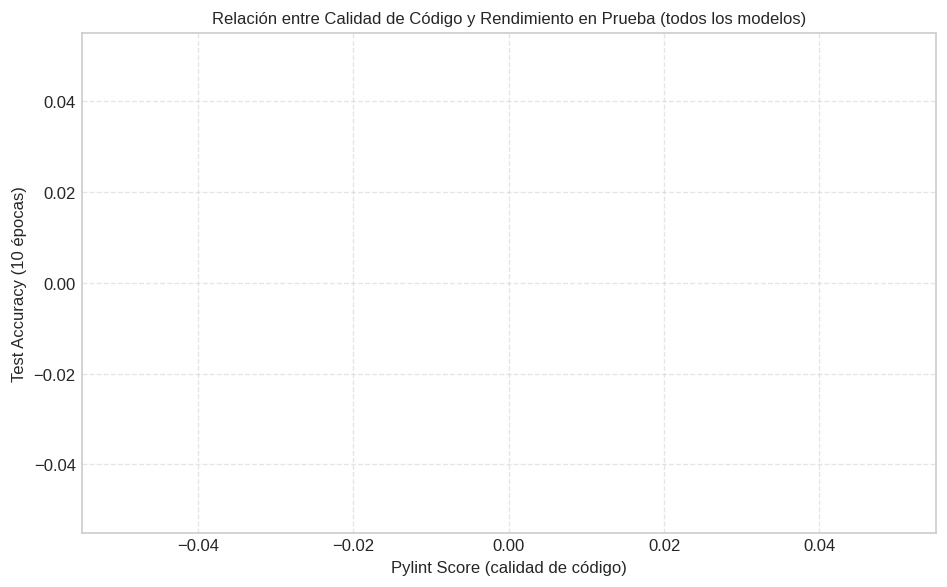

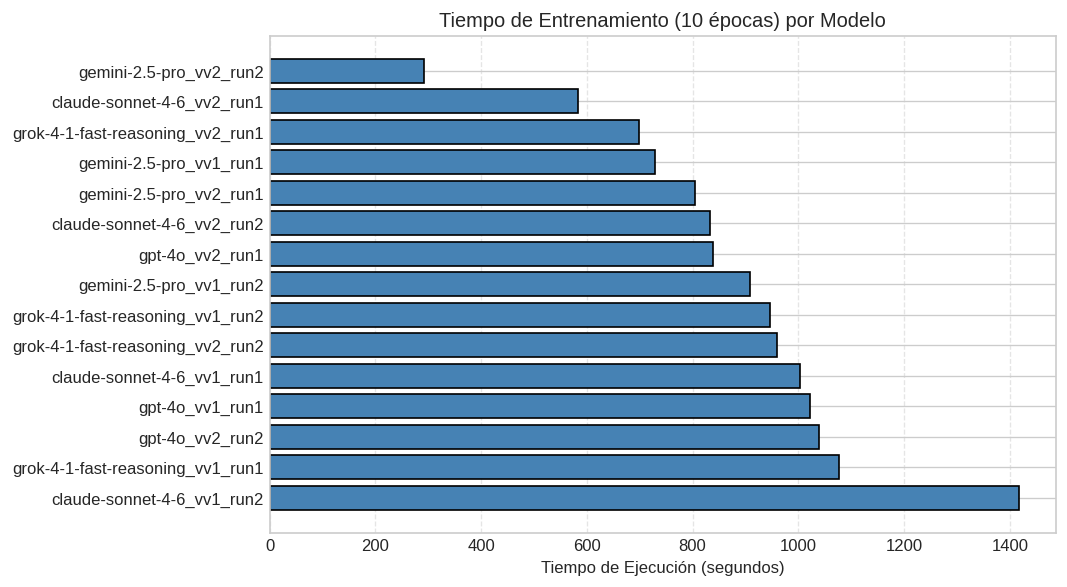


📋 TABLA 1: Resumen de Calidad de Código por LLM
+--------+----------+-----------+-------------+-------------+----------+
| LLM    |   Pylint |   Imports | Syntax OK   | Ejecución   |   Líneas |
+========+==========+===========+=============+=============+==========+
| Claude |     7.82 |      0.54 | 100%        | 100%        |      163 |
+--------+----------+-----------+-------------+-------------+----------+
| GPT-4o |     5.19 |      0.5  | 100%        | 83%         |      102 |
+--------+----------+-----------+-------------+-------------+----------+
| Gemini |     5.24 |      0.5  | 83%         | 83%         |      176 |
+--------+----------+-----------+-------------+-------------+----------+
| Grok   |     5.32 |      0.5  | 100%        | 100%        |      118 |
+--------+----------+-----------+-------------+-------------+----------+

📋 TABLA 2: Rendimiento en Conjunto de Prueba (50 épocas)
+--------+-----------+-------+------------+------+------------+--------------+
| LLM    | 

In [ ]:
# ==============================================
# 📊 VISUALIZACIÓN COMPLETA PARA TESIS (CORREGIDA)
# ==============================================
!pip install tabulate -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import os
from tabulate import tabulate

# Si df_quality no existe, crearlo desde df_results
if 'df_quality' not in dir():
    try:
        df_quality = df_results.copy()
        print("✅ df_quality creado desde df_results")
    except:
        print("⚠️ df_results no disponible, ejecuta Celda 9 primero")

# Configuración profesional
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (8, 5)

BASE_PATH = '/content/drive/MyDrive/LeLePhid_LLM_CNN'
RESULTS_DIR = os.path.join(BASE_PATH, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ==============================================
# 1. CARGAR DATOS Y LIMPIAR NOMBRES
# ==============================================
df_quality = pd.read_csv(os.path.join(RESULTS_DIR, 'evaluation_standard.csv'))
df_perf = pd.read_csv(os.path.join(RESULTS_DIR, 'technical_full_eval.csv'))

def extract_llm_name(x):
    x = str(x).lower()
    if 'gemini' in x: return 'Gemini'
    if 'gpt' in x: return 'GPT-4o'
    if 'grok' in x: return 'Grok'
    if 'claude' in x: return 'Claude'
    return x

df_quality['llm_name'] = df_quality['llm'].apply(extract_llm_name)
df_perf['llm_name'] = df_perf['llm'].apply(extract_llm_name)
df_perf['run'] = df_perf['run'].astype(str).str.extract(r'(\d+)').fillna('1')

print("✅ Datos cargados correctamente")

# ==============================================
# 2. GRÁFICO 1: BARRAS - CALIDAD DE CÓDIGO (Pylint)
# ==============================================
fig, ax = plt.subplots(figsize=(5, 3))
quality_means = df_quality.groupby('llm_name')['pylint_score'].mean().sort_values()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(quality_means)))
bars = ax.barh(quality_means.index, quality_means.values, color=colors, edgecolor='black')
ax.set_xlabel('Pylint Score (0-10)', fontsize=12)
ax.set_title('Calidad de Código por LLM', fontsize=10, fontweight='bold')
ax.axvline(x=7, linestyle='--', color='red', alpha=0.7, label='Umbral calidad (7)')
for bar, val in zip(bars, quality_means.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig01_calidad_pylint.png'), dpi=200, bbox_inches='tight')
plt.show()

# ==============================================
# 3. GRÁFICO 2: BARRAS - RENDIMIENTO EN TEST (Accuracy)
# ==============================================
fig, ax = plt.subplots(figsize=(5, 3))
df_perf_sorted = df_perf.sort_values('test_accuracy', ascending=True)
df_perf_sorted['label'] = df_perf_sorted['llm_name'] + ' v' + df_perf_sorted['version'].astype(str) + ' (run' + df_perf_sorted['run'] + ')'
colors_bar = ['#2ecc71' if i == df_perf_sorted['test_accuracy'].idxmax() else '#3498db' for i in df_perf_sorted.index]
bars = ax.barh(df_perf_sorted['label'], df_perf_sorted['test_accuracy'], color=colors_bar, edgecolor='black')
ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('Rendimiento en Conjunto de Prueba (50 épocas)', fontsize=10, fontweight='bold')
ax.set_xlim(0.9, 1.0)
for bar, val in zip(bars, df_perf_sorted['test_accuracy']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig02_rendimiento_test.png'), dpi=200, bbox_inches='tight')
plt.show()

# ==============================================
# 4. GRÁFICO 3: RADAR - MÚLTIPLES MÉTRICAS POR LLM
# ==============================================
metrics_radar = df_quality.groupby('llm_name').agg({
    'pylint_score': 'mean',
    'imports_ratio': 'mean',
    'syntax_ok': 'mean',
    'execution_success': 'mean'
}).reset_index()
metrics_radar['pylint_score'] = metrics_radar['pylint_score'] / 10

categories = ['Calidad\n(Pylint)', 'Imports\nRatio', 'Sintaxis\nVálida', 'Ejecución\nExitosa']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 4), subplot_kw=dict(polar=True))
colors_radar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for i, (idx, row) in enumerate(metrics_radar.iterrows()):
    values = [row['pylint_score'], row['imports_ratio'], row['syntax_ok'], row['execution_success']]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=0.5, label=row['llm_name'], color=colors_radar[i % len(colors_radar)])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i % len(colors_radar)])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('Perfil de Calidad por LLM', fontsize=10, fontweight='bold', pad=20)
print(f"\n")
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.2))
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig03_radar_calidad.png'), dpi=200, bbox_inches='tight')
plt.show()

# ==============================================
# 5. GRÁFICO 4: RENDIMIENTO POR VERSIÓN DE PROMPT
# ==============================================
version_perf = df_perf.groupby('version')['test_accuracy'].mean().reset_index()
fig, ax = plt.subplots(figsize=(5, 3))
colors_ver = ['#1abc9c', '#3498db', '#e74c3c']
bars = ax.bar(version_perf['version'], version_perf['test_accuracy'], color=colors_ver, edgecolor='black')
ax.set_ylabel('Test Accuracy Promedio', fontsize=10)
ax.set_xlabel('Versión de Prompt', fontsize=10)
ax.set_title('Rendimiento por Versión de Prompt (50 épocas)', fontsize=10, fontweight='bold')
ax.set_ylim(0.9, 1.0)
for bar, val in zip(bars, version_perf['test_accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}', ha='center')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig04_rendimiento_version.png'), dpi=200, bbox_inches='tight')
plt.show()

# ==============================================
# 6. GRÁFICO: TIEMPO DE EJECUCIÓN vs CALIDAD (todos los modelos)
# ==============================================
quick_eval_path = os.path.join(RESULTS_DIR, 'technical_quick_eval.csv')
if os.path.exists(quick_eval_path):
    df_quick = pd.read_csv(quick_eval_path)
    df_quick['llm_name'] = df_quick['llm'].apply(extract_llm_name)
    df_quick['run'] = df_quick['run'].astype(str).str.extract(r'(\d+)').fillna('1')

    # Unir con calidad (pylint) usando el nombre del archivo o una clave común
    # Como no hay ID directo, usamos el nombre del modelo (llm + version + run)
    df_quick['model_id'] = df_quick['llm'] + '_v' + df_quick['version'].astype(str) + '_run' + df_quick['run']
    df_quality['model_id'] = df_quality['llm'] + '_v' + df_quality['version'].astype(str) + '_run' + df_quality['run'].astype(str)
    df_merged = pd.merge(df_quick, df_quality[['model_id', 'pylint_score']], on='model_id', how='left')

    # Gráfico de dispersión: Calidad vs Rendimiento (todos los modelos)
    fig, ax = plt.subplots(figsize=(8, 5))
    scatter = ax.scatter(df_merged['pylint_score'], df_merged['test_accuracy'],
                         s=100, c=range(len(df_merged)), cmap='viridis', alpha=0.7)
    for _, row in df_merged.iterrows():
        ax.annotate(f"{row['llm_name']} v{row['version']} run{row['run']}",
                    (row['pylint_score'], row['test_accuracy']), fontsize=8, ha='center', va='bottom')
    ax.set_xlabel('Pylint Score (calidad de código)', fontsize=10)
    ax.set_ylabel('Test Accuracy (10 épocas)', fontsize=10)
    ax.set_title('Relación entre Calidad de Código y Rendimiento en Prueba (todos los modelos)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'fig06_correlacion_todos_modelos.png'), dpi=200, bbox_inches='tight')
    plt.show()

    # Gráfico de barras: Tiempo de ejecución por modelo (ordenado)
    fig, ax = plt.subplots(figsize=(9, 5))
    df_sorted = df_merged.sort_values('execution_time', ascending=False)
    bars = ax.barh(df_sorted['model_id'], df_sorted['execution_time'], color='steelblue', edgecolor='black')
    ax.set_xlabel('Tiempo de Ejecución (segundos)', fontsize=10)
    ax.set_title('Tiempo de Entrenamiento (10 épocas) por Modelo', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'fig07_tiempos_modelos.png'), dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ No se encontró technical_quick_eval.csv, omitiendo gráficos de todos los modelos.")


# ==============================================
# 7. TABLAS PROFESIONALES (formato grid, blanco y negro)
# ==============================================

from tabulate import tabulate
import pandas as pd

# Tabla 1: Calidad de código
print("\n📋 TABLA 1: Resumen de Calidad de Código por LLM")
tabla1 = df_quality.groupby('llm_name').agg({
    'pylint_score': lambda x: f"{x.mean():.2f}",
    'imports_ratio': lambda x: f"{x.mean():.2f}",
    'syntax_ok': lambda x: f"{x.mean():.0%}",
    'execution_success': lambda x: f"{x.mean():.0%}",
    'lines_of_code': lambda x: f"{x.mean():.0f}"
}).reset_index()
tabla1.columns = ['LLM', 'Pylint', 'Imports', 'Syntax OK', 'Ejecución', 'Líneas']
print(tabulate(tabla1, headers='keys', tablefmt='grid', showindex=False))
tabla1.to_csv(os.path.join(RESULTS_DIR, 'tabla_calidad_llm.csv'), index=False)

# Tabla 2: Rendimiento en prueba
print("\n📋 TABLA 2: Rendimiento en Conjunto de Prueba (50 épocas)")
tabla2 = df_perf[['llm_name', 'version', 'run', 'test_accuracy', 'f1_score', 'val_loss', 'execution_time']].copy()
tabla2['test_accuracy'] = tabla2['test_accuracy'].map(lambda x: f"{x:.3f}")
tabla2['f1_score'] = tabla2['f1_score'].map(lambda x: f"{x:.3f}")
tabla2['val_loss'] = tabla2['val_loss'].map(lambda x: f"{x:.4f}")
tabla2['execution_time'] = tabla2['execution_time'].map(lambda x: f"{x:.1f}")
tabla2.columns = ['LLM', 'Versión', 'Run', 'Test Acc', 'F1', 'Val Loss', 'Tiempo (s)']
print(tabulate(tabla2, headers='keys', tablefmt='grid', showindex=False))
tabla2.to_csv(os.path.join(RESULTS_DIR, 'tabla_rendimiento_modelos.csv'), index=False)

# Tabla 3: Mejores modelos por métrica
print("\n📋 TABLA 3: Mejores Modelos por Métrica")
best_accuracy = df_perf.loc[df_perf['test_accuracy'].idxmax()]
best_f1 = df_perf.loc[df_perf['f1_score'].idxmax()]
best_time = df_perf.loc[df_perf['execution_time'].idxmin()]
summary_best = pd.DataFrame({
    'Métrica': ['Mejor Test Accuracy', 'Mejor F1-Score', 'Entrenamiento más Rápido'],
    'Modelo': [f"{best_accuracy['llm_name']} v{best_accuracy['version']} run{best_accuracy['run']}",
               f"{best_f1['llm_name']} v{best_f1['version']} run{best_f1['run']}",
               f"{best_time['llm_name']} v{best_time['version']} run{best_time['run']}"],
    'Valor': [f"{best_accuracy['test_accuracy']:.3f}",
              f"{best_f1['f1_score']:.3f}",
              f"{best_time['execution_time']:.1f} s"]
})
print(tabulate(summary_best, headers='keys', tablefmt='grid', showindex=False))
summary_best.to_csv(os.path.join(RESULTS_DIR, 'tabla_mejores_modelos.csv'), index=False)

print("\n✅ Tablas exportadas a CSV y mostradas en formato grid (ideal para tesis).")

## **18. Historial de Corridas**

In [ ]:
# ==============================================
# REGISTRO DE CONSISTENCIA POR EJECUCIÓN
# ==============================================
import json
import os
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Archivo donde se guardará el historial
history_file = '/content/drive/MyDrive/LeLePhid_LLM_CNN/results/llm_consistency_history.json'

# ==============================================
# 1. CARGAR O CREAR HISTORIAL
# ==============================================
if os.path.exists(history_file):
    with open(history_file, 'r') as f:
        history = json.load(f)
    print(f"✅ Historial cargado: {len(history)} ejecuciones previas")
else:
    history = []
    print("✅ Nuevo historial creado")

# ==============================================
# 2. RECOPILAR RESULTADOS DE ESTA EJECUCIÓN
# ==============================================

# Variables necesarias (deben existir en el entorno)
# df_results - de Celda 9 (calidad de código)
# df_success - de Celda 10 (top modelos 10 épocas)
# df_full - de Celda 11 (resultados 50 épocas)

# Calidad de código (Celda 9)
try:
    best_llm_quality = df_results.groupby('llm')['pylint_score'].mean().idxmax()
    best_pylint_score = float(df_results.groupby('llm')['pylint_score'].mean().max())
    quality_available = True
except:
    best_llm_quality = "N/A"
    best_pylint_score = 0
    quality_available = False
    print("⚠️ df_results no disponible (ejecuta Celda 9 primero)")

# Top modelos de 10 épocas (Celda 10)
try:
    top_models_10 = df_success.head(3)[['llm', 'version', 'run', 'test_accuracy']].to_dict('records') if 'df_success' in dir() and df_success is not None else []
    ten_epochs_available = True
except:
    top_models_10 = []
    ten_epochs_available = False
    print("⚠️ df_success no disponible (ejecuta Celda 10 primero)")

# Rendimiento en 50 épocas y recursos (Celda 11)
try:
    best_llm_50 = df_full.loc[df_full['test_accuracy'].idxmax(), 'llm'] if 'df_full' in dir() and len(df_full) > 0 else None
    best_accuracy_50 = float(df_full['test_accuracy'].max()) if 'df_full' in dir() and len(df_full) > 0 else None
    # Recursos promedio de los 4 modelos
    if 'df_full' in dir() and len(df_full) > 0:
        avg_cpu = df_full['cpu_percent'].mean() if 'cpu_percent' in df_full.columns else None
        avg_ram = df_full['ram_percent'].mean() if 'ram_percent' in df_full.columns else None
        avg_gpu = df_full['gpu_percent'].mean() if 'gpu_percent' in df_full.columns else None
    else:
        avg_cpu = avg_ram = avg_gpu = None
    fifty_epochs_available = True
except:
    best_llm_50 = None
    best_accuracy_50 = None
    avg_cpu = avg_ram = avg_gpu = None
    fifty_epochs_available = False
    print("⚠️ df_full no disponible (ejecuta Celda 11 primero)")

# ==============================================
# 3. CREAR REGISTRO DE ESTA EJECUCIÓN
# ==============================================
run_record = {
    'run_id': len(history) + 1,
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'best_llm_quality': best_llm_quality,
    'best_pylint_score': best_pylint_score,
    'top_3_models_10_epochs': top_models_10,
    'best_llm_50_epochs': best_llm_50,
    'best_accuracy_50': best_accuracy_50,
    'avg_cpu_percent': avg_cpu,
    'avg_ram_percent': avg_ram,
    'avg_gpu_percent': avg_gpu
}

# Agregar al historial
history.append(run_record)

# Guardar historial actualizado
with open(history_file, 'w') as f:
    json.dump(history, f, indent=2)

print(f"\n📝 Ejecución #{run_record['run_id']} registrada en {history_file}")
print(f"   Mejor LLM (calidad): {run_record['best_llm_quality']} ({run_record['best_pylint_score']:.2f})")
if run_record['best_accuracy_50']:
    print(f"   Mejor LLM (50 épocas): {run_record['best_llm_50_epochs']} ({run_record['best_accuracy_50']:.3f})")
if avg_cpu:
    print(f"   Recursos promedio: CPU={avg_cpu:.1f}%, RAM={avg_ram:.1f}%, GPU={avg_gpu:.1f}%")

# ==============================================
# 4. VISUALIZACIÓN DE CONSISTENCIA (GRÁFICOS)
# ==============================================

if len(history) >= 2:
    print("\n" + "="*60)
    print("📊 ANÁLISIS DE CONSISTENCIA ENTRE EJECUCIONES")
    print("="*60)

    # Convertir historial a DataFrame
    df_history = pd.DataFrame(history)

    # Gráfico 1: Evolución del mejor pylint score
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_history['run_id'], df_history['best_pylint_score'], 'o-', color='#2ecc71', linewidth=2, markersize=8)
    ax.set_xlabel('Número de Ejecución', fontsize=12)
    ax.set_ylabel('Mejor Pylint Score', fontsize=12)
    ax.set_title('Consistencia en Calidad de Código entre Ejecuciones', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    for i, row in df_history.iterrows():
        ax.annotate(f"{row['best_pylint_score']:.2f}", (row['run_id'], row['best_pylint_score']),
                    textcoords="offset points", xytext=(0,10), ha='center')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/consistencia_pylint.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Gráfico 2: Evolución del mejor accuracy (50 épocas)
    df_50 = df_history[df_history['best_accuracy_50'].notna()]
    if len(df_50) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(df_50['run_id'], df_50['best_accuracy_50'], 'o-', color='#3498db', linewidth=2, markersize=8)
        ax.set_xlabel('Número de Ejecución', fontsize=12)
        ax.set_ylabel('Mejor Test Accuracy (50 épocas)', fontsize=12)
        ax.set_title('Consistencia en Rendimiento entre Ejecuciones', fontsize=14, fontweight='bold')
        ax.set_ylim(0.9, 1.0)
        ax.grid(True, linestyle='--', alpha=0.5)
        for i, row in df_50.iterrows():
            ax.annotate(f"{row['best_accuracy_50']:.3f}", (row['run_id'], row['best_accuracy_50']),
                        textcoords="offset points", xytext=(0,10), ha='center')
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/consistencia_accuracy.png', dpi=200, bbox_inches='tight')
        plt.show()

    # Gráfico 3: Frecuencia de mejores LLM
    fig, ax = plt.subplots(figsize=(8, 5))
    best_llm_counts = df_history['best_llm_quality'].value_counts()
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    bars = ax.bar(best_llm_counts.index, best_llm_counts.values, color=colors[:len(best_llm_counts)], edgecolor='black')
    ax.set_xlabel('LLM', fontsize=12)
    ax.set_ylabel('Veces que fue el mejor', fontsize=12)
    ax.set_title('Frecuencia de Mejor LLM por Calidad de Código', fontsize=14, fontweight='bold')
    for bar, val in zip(bars, best_llm_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, str(val), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/frecuencia_mejor_llm.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Gráfico 4: Evolución del uso de recursos (CPU, RAM, GPU)
    if 'avg_cpu_percent' in df_history.columns and df_history['avg_cpu_percent'].notna().any():
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(df_history['run_id'], df_history['avg_cpu_percent'], 'o-', color='#e74c3c', label='CPU %', linewidth=2)
        ax.plot(df_history['run_id'], df_history['avg_ram_percent'], 's-', color='#3498db', label='RAM %', linewidth=2)
        if df_history['avg_gpu_percent'].notna().any():
            ax.plot(df_history['run_id'], df_history['avg_gpu_percent'], 'd-', color='#2ecc71', label='GPU %', linewidth=2)
        ax.set_xlabel('Número de Ejecución', fontsize=12)
        ax.set_ylabel('Uso de Recursos (%)', fontsize=12)
        ax.set_title('Consistencia en Uso de Recursos entre Ejecuciones', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/consistencia_recursos.png', dpi=200, bbox_inches='tight')
        plt.show()

    # Tabla resumen de consistencia
    print("\n📋 TABLA DE CONSISTENCIA (Resumen por ejecución):")
    summary_table = df_history[['run_id', 'timestamp', 'best_llm_quality', 'best_pylint_score', 'best_accuracy_50', 'avg_cpu_percent', 'avg_ram_percent']].copy()
    summary_table['best_accuracy_50'] = summary_table['best_accuracy_50'].map(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")
    summary_table['avg_cpu_percent'] = summary_table['avg_cpu_percent'].map(lambda x: f"{x:.1f}" if pd.notna(x) else "N/A")
    summary_table['avg_ram_percent'] = summary_table['avg_ram_percent'].map(lambda x: f"{x:.1f}" if pd.notna(x) else "N/A")
    summary_table.columns = ['Ejecución', 'Timestamp', 'Mejor LLM', 'Pylint', 'Best Acc (50 ep)', 'CPU %', 'RAM %']
    print(summary_table.to_string(index=False))

    # Guardar tabla de consistencia
    summary_table.to_csv('/content/drive/MyDrive/LeLePhid_LLM_CNN/results/tabla_consistencia.csv', index=False)
    print("\n💾 Tabla de consistencia guardada en: results/tabla_consistencia.csv")

else:
    print("\n⚠️ Se necesitan al menos 2 ejecuciones para generar gráficos de consistencia.")
    print(f"   Ejecuciones actuales: {len(history)}. Realiza más corridas completas.")

# ==============================================
# 5. MOSTRAR HISTORIAL COMPLETO
# ==============================================
print("\n" + "="*60)
print("📜 HISTORIAL COMPLETO DE EJECUCIONES")
print("="*60)
for run in history:
    print(f"Run {run['run_id']} ({run['timestamp']}):")
    print(f"   Mejor LLM (calidad): {run['best_llm_quality']} (pylint={run['best_pylint_score']:.2f})")
    if run['best_accuracy_50']:
        print(f"   Mejor LLM (50 épocas): {run['best_llm_50_epochs']} (acc={run['best_accuracy_50']:.3f})")
    if run.get('avg_cpu_percent'):
        print(f"   Recursos: CPU={run['avg_cpu_percent']:.1f}%, RAM={run['avg_ram_percent']:.1f}%")
    print()

print("✅ Análisis de consistencia completado.")

✅ Nuevo historial creado
⚠️ df_results no disponible (ejecuta Celda 9 primero)

📝 Ejecución #1 registrada en /content/drive/MyDrive/LeLePhid_LLM_CNN/results/llm_consistency_history.json
   Mejor LLM (calidad): N/A (0.00)
   Mejor LLM (50 épocas): claude-sonnet-4-6 (0.980)

⚠️ Se necesitan al menos 2 ejecuciones para generar gráficos de consistencia.
   Ejecuciones actuales: 1. Realiza más corridas completas.

📜 HISTORIAL COMPLETO DE EJECUCIONES
Run 1 (2026-05-29 03:19:49):
   Mejor LLM (calidad): N/A (pylint=0.00)
   Mejor LLM (50 épocas): claude-sonnet-4-6 (acc=0.980)

✅ Análisis de consistencia completado.


## **19. Git versionado**

In [ ]:
# Hacer commit con git desde Colab

# 1. Ir al directorio raíz del proyecto
%cd /content/drive/MyDrive/LeLePhid_LLM_CNN

# 2. Eliminar la carpeta del repositorio actual (para empezar limpio)
!rm -rf LeLePhid-LLM-CNN

# 3. Clonar el repositorio vacío (asegúrate de tener el token en Secrets)
github_token = userdata.get('GITHUB_TOKEN')  # tu token de GitHub
!git clone https://{github_token}@github.com/FreddyYMJ/LeLePhid-LLM-CNN.git

# 4. Copiar TODOS los archivos (excepto la carpeta del repo) dentro del repositorio clonado
#    Esto copia todo: src, prompts, results, etc., pero excluye la carpeta destino
!cp -r $(ls -A | grep -v "LeLePhid-LLM-CNN") LeLePhid-LLM-CNN/

# 5. Entrar al repositorio
%cd LeLePhid-LLM-CNN

# 6. Agregar, commitear y subir
!git add .
!git commit -m "Primer commit: estructura del proyecto y códigos generados"
!git push origin main

/content/drive/MyDrive/LeLePhid_LLM_CNN
Cloning into 'LeLePhid-LLM-CNN'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 14 (delta 1), reused 14 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 19.29 KiB | 617.00 KiB/s, done.
fatal: premature end of pack file, 2487 bytes missing
fatal: fetch-pack: invalid index-pack output
cp: target 'LeLePhid-LLM-CNN/' is not a directory
[Errno 2] No such file or directory: 'LeLePhid-LLM-CNN'
/content/drive/MyDrive/LeLePhid_LLM_CNN
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY

## **20. Reiniciar los prompts, modelos generados y resultados**

In [ ]:
# ==============================================
# 🗑️ LIMPIAR TODO - EMPEZAR DESDE CERO
# ==============================================
# ⚠️ SOLO EJECUTAR SI QUIERO BORRAR TODO

import shutil

respuesta = input("¿Borrar TODOS los códigos, prompts y resultados? (sí/no): ")

if respuesta.lower() == 'si':
    # Carpetas a limpiar
    carpetas = [
        '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code',
        '/content/drive/MyDrive/LeLePhid_LLM_CNN/src/prompts',
        '/content/drive/MyDrive/LeLePhid_LLM_CNN/results',
        '/content/drive/MyDrive/LeLePhid_LLM_CNN/experiments'
    ]

    for carpeta in carpetas:
        if os.path.exists(carpeta):
            shutil.rmtree(carpeta)
            os.makedirs(carpeta, exist_ok=True)
            print(f"✅ Limpiado: {carpeta}")
        else:
            os.makedirs(carpeta, exist_ok=True)
            print(f"📁 Creada: {carpeta}")

    print("\n✅ Todo limpio. Listo para empezar desde cero.")
else:
    print("❌ Operación cancelada.")

¿Borrar TODOS los códigos, prompts y resultados? (sí/no): si
✅ Limpiado: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/generated_code
✅ Limpiado: /content/drive/MyDrive/LeLePhid_LLM_CNN/src/prompts
✅ Limpiado: /content/drive/MyDrive/LeLePhid_LLM_CNN/results
✅ Limpiado: /content/drive/MyDrive/LeLePhid_LLM_CNN/experiments

✅ Todo limpio. Listo para empezar desde cero.


## **21. Limpieza total de las carpetas de imagenes Train, Val y Test**

In [ ]:
# ==============================================
# LIMPIEZA TOTAL Y REORGANIZACIÓN DEL DATASET
# ==============================================
import os
import shutil
import zipfile
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Rutas
ruta_zip = '/content/drive/MyDrive/LeLephid database.zip'
ruta_extraccion = '/content/Images/Images'

# 1. Eliminar carpeta actual si existe
if os.path.exists(ruta_extraccion):
    shutil.rmtree(ruta_extraccion)
    print("✅ Carpeta /content/Images eliminada.")
else:
    print("⚠️ La carpeta no existía.")

# 2. Descomprimir de nuevo
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(ruta_extraccion)
print("✅ Archivos descomprimidos nuevamente.")

# 3. Reconstruir dataframe df_images (necesario para organize_dataset)
# (Copiamos la función de obtención de info de imágenes de la Celda 3)
def get_image_info(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode
            return width, height, mode, os.path.getsize(image_path)
    except:
        return None, None, None, None

data = []
for roots, dirs, files in os.walk(ruta_extraccion):
    for file in files:
        if file.lower().endswith(('.jpg','.jpeg')):
            full_path = os.path.join(roots,file)
            width, height, mode, file_size = get_image_info(full_path)
            data.append({
                'image_path': full_path,
                'image_name': file,
                'width': width,
                'height': height,
                'mode': mode,
                'file_size': file_size
            })
df_images = pd.DataFrame(data)
print(f"✅ Se encontraron {len(df_images)} imágenes.")

# 4. Organizar dataset (función ya definida en Celda 5)
# Asegurarse de que la función organize_dataset esté disponible
# (Si no, la definimos aquí o ejecutamos la Celda 5 completa)
organize_dataset(df_images, ruta_extraccion)

# 5. Verificar estructura final
print("\n📁 Estructura final:")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(ruta_extraccion, split)
    if os.path.exists(split_path):
        aphids = len(os.listdir(os.path.join(split_path, 'aphids'))) if os.path.exists(os.path.join(split_path, 'aphids')) else 0
        healthy = len(os.listdir(os.path.join(split_path, 'healthy'))) if os.path.exists(os.path.join(split_path, 'healthy')) else 0
        print(f"{split.upper()}: aphids={aphids}, healthy={healthy}, total={aphids+healthy}")
    else:
        print(f"⚠️ {split} no encontrado.")

print("\n✅ Reorganización completada.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Carpeta /content/Images eliminada.
✅ Archivos descomprimidos nuevamente.
✅ Se encontraron 665 imágenes.
📂 Organizando dataset en: /content/Images/Images
📁 Creando etiquetas y dividiendo...
✅ Dataset organizado:
    Train: 465 imágenes
    Val: 100 imágenes
    Test: 100 imágenes

📁 Estructura final:
TRAIN: aphids=234, healthy=231, total=465
VAL: aphids=50, healthy=50, total=100
TEST: aphids=51, healthy=49, total=100

✅ Reorganización completada.


## **22. Para mantener activa la sesión y evitar desconexión de Google Colab**

In [ ]:
# Mantener activa la sesión de Colab
def keep_alive():
    import IPython
    display(IPython.display.Javascript("""
    function ClickConnect(){
        console.log("Manteniendo sesión activa...");
        document.querySelector("colab-connect-button").click()
    }
    setInterval(ClickConnect,60000)
    """))

keep_alive()
print("✅ Script activado. La sesión se mantendrá activa cada 60 segundos.")

<IPython.core.display.Javascript object>

✅ Script activado. La sesión se mantendrá activa cada 60 segundos.
